## Postdoc market simulation

First, some notes:

To be clear, the point of this is to measure the level of stochasticity in the postdoctoral market, in order to get a sense of the answer to the question: "***Given that I believe that I am ranked at some percentile in the global market, how many things should I apply to to be N percent certain of getting a job***".

### Number of available jobs

From AAS job postings + my own estimate, the number of available positions

| Category | Count |
| --- | --- |
| Society of Fellows (which may go to astronomers) |	5 |
| Prize / Independent Fellowships	| 36 (30-60) (but each of these on average x2)|
| Standard (non-prize) Postdocs | 194 (190-220)|
| **Total positions** | 255 |

### Number of graduating PhDs

US astro/astrophysics, 200-300 per year (http://nature.com/articles/d41586-019-00655-3 ).
China is probably 300-700 (actually more, look at Tsinghua https://astro.tsinghua.edu.cn/en/Teaching/Students.htm ), with maybe one half - one third entering the competion for these jobs listed above.
Europe similar 300-500+

Not counting cosmologists in physics departments. (adds maybe 20% to the total numbers)

Should also consider current postdocs re-applying: guesstimate that about 100 postdocs every year reapplying (1/6th of a given postdoc cohort will find faculty positions, 1/3 reapplies, the rest drop out of the field)

Statistics from different positions

- 700 for something like the Hubble/Soc-Fellows
- 200-500 applicants for a prize fellowships
- 100 applications for project postdoc

Typical number of applications sent in by each applicant 10-100 (truncated log-normal)
Applicants apply to at least 50% prize or above
Students are ranked based on a noisy perception of their ranking (draw perception of ranking from Mallows Model) - invite top 5% for interviews, and then redraw, with a less noisy draw, and offer the position to the 1 ranked candidate.

Next step - many good applicants will have many offers, but they can only accept 1.
Assume that they all accept the higher ranked fellowship in the first round, with the position then being offered to the second ranked applicant, iterate until convergence.

So the question is:

How many positions should I apply to, given that I am ranked somewhere in the:

Upper half, lower half, quartiles, if I don’t know anything, to have a (10, 50, 90)% chance of getting a position. Of getting a prize position?

The best possible model:

Draw an N-dimensional vector of relevant skills (code skill, pen-to-paper skill, project selection/intuition, prior experience, ability to work with others/personality, writing skills, outreach, etc.). This N-dimensional vector then gets projected (with some noise) onto the weight/preference vector of the hiring committee 

(Visualize this as a 3-dimensional vector)

Some inspiration from https://github.com/ekhiru/top-k-mallows/tree/master

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os, copy
sys.path.append('top-k-mallows')
import mallows_kendall as mk
import permutil as pu
import scipy as sp
import pandas as pd

In [2]:
N_students = 1000
N_postdocs = 300
        # SocFellow, Prize, Project
splits = np.array([5, 50, 200])
splits = splits/np.sum(splits)

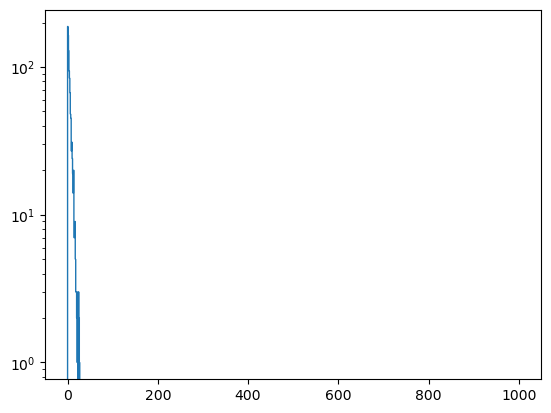

In [15]:
samps = mk.sample(m=1000,n=1000,phi=0.8)
plt.hist(samps[:,0], bins = np.arange(1000), histtype = 'step', log = 1);

In [25]:
sum( samps[:,0]==0 ), sum( samps[:,500]==500 ), sum( samps[:,500]==501 ), sum( samps[:,500]==502 ), sum( samps[:,500]==521 )

(188, 52, 46, 60, 3)

In [27]:
np.std(samps[:,500])/10

0.7893764374492059

In [28]:
samps_small = mk.sample(m=100,n=1000,phi=0.8)
np.std(samps_small[:,1]), sum( samps[:,0]==0 ), sum( samps[:,1]==1 ), sum( samps[:,50] == 50 )

(5.075145318116517, 188, 123, 53)

In [31]:
np.std(samps_small[:,50])

8.05317328759291

In [36]:
class ApplicantCohort:

    def __init__(
        self,
        n_students=1000,
        n_postdocs=300,
        splits=np.array([6, 50, 200]),
        frac_student_applying=3/4,
        frac_postdoc_applying=1/3,
        mean_applications=np.log(30),
        sigma_applications=0.4,
        tier_max_prestige=[10, 15, 3],
        prestige_decays=[1, 2, 1.2],
        minimum_prestiges=[5, 3, 1],
        loc_postdoc_reapplying=1.3,
        scale_postdoc_reapplying=0.8,
        loc_student=0,
        scale_student=1,
        self_awareness=0.5,
        stochasticity=0.7,
        verbose=1
    ):

        self.verbose = verbose

        self.n_students = n_students
        self.n_postdocs = n_postdocs

        self.frac_student_applying = frac_student_applying
        self.frac_postdoc_applying = frac_postdoc_applying

        self.n_student_applying = int(n_students * frac_student_applying)
        self.n_postdoc_reapplying = int(n_postdocs * frac_postdoc_applying)

        self.splits = np.array([int(s) for s in splits])
        self.n_positions = sum(self.splits)

        self.tier_max = np.array(tier_max_prestige)
        self.prestige_decay = prestige_decays
        self.minimum_prestiges = minimum_prestiges

        self.mean_applications = mean_applications
        self.sigma_applications = sigma_applications

        self.self_awareness = np.clip(self_awareness, 0, 0.5)
        self.stochasticity = stochasticity

        self.loc_postdoc_reapplying = loc_postdoc_reapplying
        self.scale_postdoc_reapplying = scale_postdoc_reapplying
        self.loc_student = loc_student
        self.scale_student = scale_student

    ############################################################
    # 1️⃣ RANK APPLICANTS
    ############################################################

    def rank_applicants(self):

        skills_students = np.random.normal(
            self.loc_student,
            self.scale_student,
            self.n_student_applying
        )

        skills_postdocs = np.random.normal(
            self.loc_postdoc_reapplying,
            self.scale_postdoc_reapplying,
            self.n_postdoc_reapplying
        )

        labels = (
            ['student'] * self.n_student_applying +
            ['postdoc'] * self.n_postdoc_reapplying
        )

        all_skills = np.concatenate([skills_students, skills_postdocs])

        order = np.argsort(-all_skills)

        self.applicants = []

        for rank, idx in enumerate(order):

            applicant = {
                "rank": rank,
                "skill": all_skills[idx],
                "currently": labels[idx],
                "n_applications": 0,
                "offers": [],
                "offers_prestige": [],
                "offers_this_round": [],
                "offers_prestige_this_round": [],
                "total_offers_received": 0,
                "accepted": False,
                "accepted_job": None,
                "accepted_round": None
            }

            self.applicants.append(applicant)

        self.applicants_on_the_market = list(range(len(self.applicants)))

    ############################################################
    # 2️⃣ APPLICATION COUNTS
    ############################################################

    def get_n_applications_per_applicant(self):

        mean_postdoc = np.log(np.exp(self.mean_applications) / 2)

        for applicant in self.applicants:

            if applicant["currently"] == "postdoc":
                n = np.random.lognormal(mean_postdoc, self.sigma_applications)
            else:
                n = np.random.lognormal(self.mean_applications, self.sigma_applications)

            applicant["n_applications"] = int(max(1, n))

        if self.verbose >= 1:

            students = [a for a in self.applicants if a["currently"] == "student"]
            postdocs = [a for a in self.applicants if a["currently"] == "postdoc"]

            print("\n--- APPLICATION STATISTICS ---")
            print(f"Students applying: {len(students)}")
            print(f"Postdocs applying: {len(postdocs)}")
            print(f"Mean applications (students): {np.mean([a['n_applications'] for a in students]):.2f}")
            print(f"Mean applications (postdocs): {np.mean([a['n_applications'] for a in postdocs]):.2f}")
            print(f"Total positions: {self.n_positions}")
            print("--------------------------------")

    ############################################################
    # 3️⃣ BUILD PRESTIGE
    ############################################################

    def build_prestige(self):

        prestige = []

        for i in range(len(self.splits)):

            n = self.splits[i]
            ranks = np.arange(n)

            values = (
                self.tier_max[i] *
                np.exp(-self.prestige_decay[i] / n * ranks)
                + self.minimum_prestiges[i]
            )

            prestige.extend(values)

        self.prestige = np.array(prestige) / 4

    ############################################################
    # 4️⃣ APPLICATION POOLS
    ############################################################

    def make_application_pools(self):

        N_positions = len(self.prestige)
        self.pools = [[] for _ in range(N_positions)]

        max_skill = max(abs(a["skill"]) for a in self.applicants)

        for i, applicant in enumerate(self.applicants):

            beta = 0.5 - self.self_awareness * applicant["skill"] / max_skill

            logits = beta * self.prestige
            probs = np.exp(logits - np.max(logits))
            probs /= probs.sum()

            k = min(applicant["n_applications"], N_positions)

            chosen = np.random.choice(
                N_positions,
                size=k,
                replace=False,
                p=probs
            )

            for pos in chosen:
                self.pools[pos].append(i)

        self.jobs_still_open = list(range(N_positions))
        self.job_offer_pointer = [0] * N_positions

    ############################################################
    # 5️⃣ EVALUATE APPLICATIONS
    ############################################################

    def evaluate_applications(self):

        sys.path.append('top-k-mallows')
        import mallows_kendall as mk

        self.pool_rankings = []

        for pool in self.pools:

            if len(pool) == 0:
                self.pool_rankings.append([[]])
                continue

            ranking = mk.sample(m=1, n=len(pool), phi=self.stochasticity)
            ordered = [pool[i] for i in ranking[0]]
            self.pool_rankings.append([ordered])

    ############################################################
    # 6️⃣ MAKE OFFERS
    ############################################################

    def make_applicant_offers(self):

        for job in self.jobs_still_open.copy():

            pointer = self.job_offer_pointer[job]
            ranked_list = self.pool_rankings[job][0]

            # SECOND CALL
            if pointer >= len(ranked_list):

                remaining = self.applicants_on_the_market

                if len(remaining) == 0:
                    continue

                ranked_list = sorted(
                    remaining,
                    key=lambda x: self.applicants[x]["skill"],
                    reverse=True
                )

                self.pool_rankings[job] = [ranked_list]
                self.job_offer_pointer[job] = 0
                pointer = 0

                if self.verbose >= 2:
                    print(f"Job {job} triggers SECOND CALL")

            while pointer < len(ranked_list):

                applicant_id = ranked_list[pointer]
                pointer += 1
                self.job_offer_pointer[job] = pointer

                if applicant_id not in self.applicants_on_the_market:
                    continue

                applicant = self.applicants[applicant_id]

                if applicant["total_offers_received"] >= applicant["n_applications"]:
                    continue

                applicant["offers_this_round"].append(job)
                applicant["offers_prestige_this_round"].append(self.prestige[job])

                applicant["offers"].append(job)
                applicant["offers_prestige"].append(self.prestige[job])

                applicant["total_offers_received"] += 1

                if self.verbose >= 2:
                    print(f"Job {job} offers to Applicant {applicant_id} "
                          f"({applicant['currently']})")

                break

    ############################################################
    # 7️⃣ ACCEPT OFFERS
    ############################################################

    def accept_offer_round(self):

        accepted_this_round = []

        for applicant_id in self.applicants_on_the_market.copy():

            applicant = self.applicants[applicant_id]

            if len(applicant["offers_this_round"]) == 0:
                continue

            perturb = np.abs(np.random.normal(1, 0.2))
            weighted = np.array(applicant["offers_prestige_this_round"]) * perturb

            chosen_index = np.argmax(weighted)
            chosen_job = applicant["offers_this_round"][chosen_index]

            applicant["accepted"] = True
            applicant["accepted_job"] = chosen_job
            applicant["accepted_round"] = self.round

            accepted_this_round.append(applicant_id)

            self.jobs_still_open.remove(chosen_job)

            if self.verbose >= 2:
                print(f"Applicant {applicant_id} ACCEPTS job {chosen_job} "
                      f"(sent {applicant['n_applications']} applications)")

        for a in accepted_this_round:
            self.applicants_on_the_market.remove(a)

        ########################################################
        # VERBOSE LEVEL 1 SUMMARY
        ########################################################

        if self.verbose >= 1 and len(accepted_this_round) > 0:

            accepted = [self.applicants[a] for a in accepted_this_round]

            students = [a for a in accepted if a["currently"] == "student"]
            postdocs = [a for a in accepted if a["currently"] == "postdoc"]

            print(f"\nROUND {self.round} SUMMARY")
            print(f"Accepted this round: {len(accepted)}")
            print(f"Students: {len(students)}, Postdocs: {len(postdocs)}")
            print(f"Mean applications sent (accepted): "
                  f"{np.mean([a['n_applications'] for a in accepted]):.2f}")
            print(f"Mean offers received (accepted): "
                  f"{np.mean([a['total_offers_received'] for a in accepted]):.2f}")
            print(f"Jobs remaining open: {len(self.jobs_still_open)}")
            print("--------------------------------")

        # Clear round offers only
        for applicant in self.applicants:
            applicant["offers_this_round"] = []
            applicant["offers_prestige_this_round"] = []

    ############################################################
    # 8️⃣ RUN MARKET
    ############################################################

    def run_market(self, offer_rounds=10):

        if self.verbose >= 1:
            print("\n=========== STARTING MARKET ===========")

        self.rank_applicants()
        self.get_n_applications_per_applicant()
        self.build_prestige()
        self.make_application_pools()
        self.evaluate_applications()

        self.round = 1

        for _ in range(offer_rounds):

            if len(self.jobs_still_open) == 0:
                break

            if len(self.applicants_on_the_market) == 0:
                break

            if self.verbose >= 1:
                print(f"\n--- ROUND {self.round} ---")
                print(f"Open jobs: {len(self.jobs_still_open)}")
                print(f"Applicants on market: {len(self.applicants_on_the_market)}")

            self.make_applicant_offers()
            self.accept_offer_round()

            self.round += 1

        if self.verbose >= 1:
        
            filled = [a for a in self.applicants if a["accepted"]]
            n_filled = len(filled)
        
            students_filled = sum(a["currently"] == "student" for a in filled)
            postdocs_filled = sum(a["currently"] == "postdoc" for a in filled)
        
            max_positions_anyone_got = max(
                [a["total_offers_received"] for a in self.applicants]
            )
        
            print("\n=========== MARKET CLOSED ===========")
            print(f"Total filled: {n_filled}/{self.n_positions}")
            print(f"Students placed: {students_filled} ({students_filled/self.n_student_applying*100:.1f}%)")
            print(f"Postdocs placed: {postdocs_filled}  ({postdocs_filled/self.n_postdoc_reapplying*100:.1f}%)")
            print(f"Unfilled jobs: {len(self.jobs_still_open)}")
            print(f"Maximum offers received by any applicant: {max_positions_anyone_got}")
            print("======================================")

        

In [37]:
Cohort = ApplicantCohort(stochasticity = 0.7)
# This works well for round 1, but not for round 2 and so on. Many applications get more offers than they've applied for
Cohort.run_market(offer_rounds = 20)


=========== STARTING MARKET ===========

--- APPLICATION STATISTICS ---
Students applying: 750
Postdocs applying: 100
Mean applications (students): 32.41
Mean applications (postdocs): 16.41
Total positions: 256
--------------------------------

--- ROUND 1 ---
Open jobs: 256
Applicants on market: 850

ROUND 1 SUMMARY
Accepted this round: 85
Students: 50, Postdocs: 35
Mean applications sent (accepted): 27.38
Mean offers received (accepted): 3.01
Jobs remaining open: 171
--------------------------------

--- ROUND 2 ---
Open jobs: 171
Applicants on market: 765

ROUND 2 SUMMARY
Accepted this round: 67
Students: 45, Postdocs: 22
Mean applications sent (accepted): 26.70
Mean offers received (accepted): 2.55
Jobs remaining open: 104
--------------------------------

--- ROUND 3 ---
Open jobs: 104
Applicants on market: 698

ROUND 3 SUMMARY
Accepted this round: 55
Students: 41, Postdocs: 14
Mean applications sent (accepted): 27.25
Mean offers received (accepted): 1.89
Jobs remaining open: 49


In [38]:
finalized_applicants = Cohort.applicants
offers_rank = np.array([applicant['accepted_job'] for applicant in finalized_applicants])
student_or_postdoc = np.array([True if applicant['currently']=='student' else False for applicant in finalized_applicants])
offer_numbers = np.array([applicant['total_offers_received'] for applicant in finalized_applicants])
applications_sent = np.array([applicant['n_applications'] for applicant in finalized_applicants])

Text(0, 0.5, 'Position rank of final accepted position')

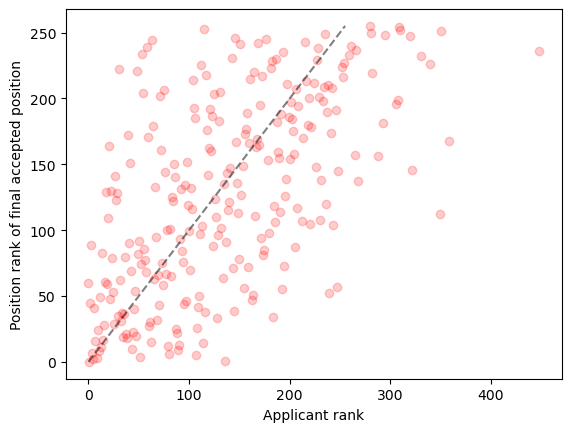

In [39]:
plt.plot(offers_rank, 'ro', alpha = 0.2)
maxapp = np.nanmax(offers_rank.astype(float))
# maxapp = np.max(np.arange(len(offers_rank))[offers_rank!=None])
plt.plot([0, maxapp], [0, maxapp], 'k--', alpha = 0.5)

plt.xlabel('Applicant rank')
plt.ylabel('Position rank of final accepted position')

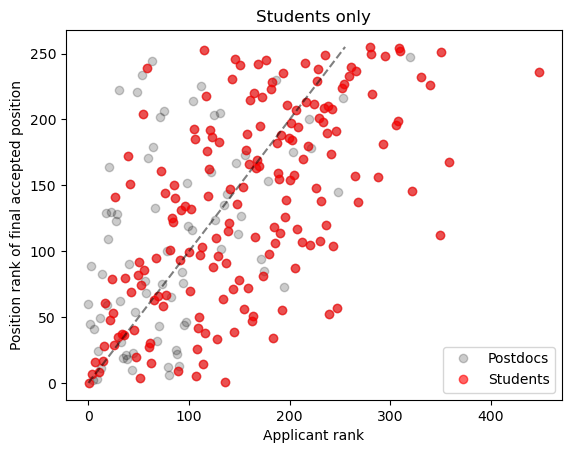

In [40]:
plt.plot(offers_rank, 'ko', alpha = 0.2, label = 'Postdocs')

offers_rank_student = offers_rank[student_or_postdoc]
student_global_ranks = np.arange(len(student_or_postdoc))[student_or_postdoc]
plt.plot(student_global_ranks, offers_rank_student, 'ro', alpha = 0.6, label = 'Students')
plt.plot([0, np.nanmax(offers_rank_student.astype(float))], [0, np.nanmax(offers_rank_student.astype(float))], 'k--', alpha = 0.5)


plt.xlabel('Applicant rank')
plt.ylabel('Position rank of final accepted position')
plt.title('Students only')

plt.legend()

448

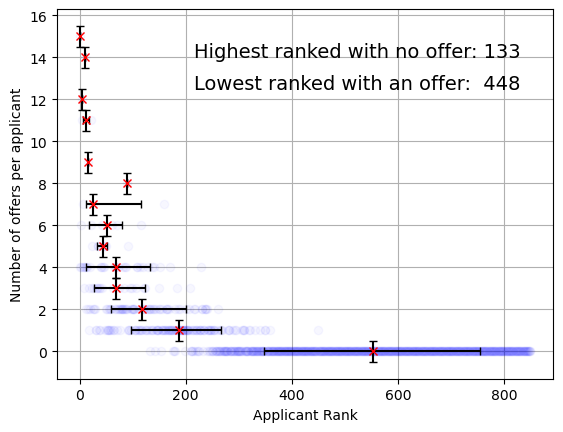

In [41]:
medians = []
iqr_up =[]
iqr_down = []
global_ranks = np.arange(len(offer_numbers))
for noffer in np.unique(offer_numbers):
    mask = offer_numbers == noffer
    all_ranks = global_ranks[mask]
    medians.append( np.median(all_ranks) )
    iqr_up.append( np.percentile(all_ranks, 84) - np.median(all_ranks))
    iqr_down.append( np.median(all_ranks)-np.percentile(all_ranks, 16) )

plt.plot(offer_numbers, 'bo', alpha = 0.03)
plt.errorbar(medians, np.unique(offer_numbers), xerr = [iqr_down, iqr_up], yerr = 0.5, fmt = 'rx', ecolor = 'k', capsize = 3)
plt.grid(True)

plt.locator_params(axis='both', integer=True)
plt.xlabel('Applicant Rank')
plt.ylabel('Number of offers per applicant')

highest_ranked_no_offer = global_ranks[student_or_postdoc][offer_numbers[student_or_postdoc] == 0][0]
lowest_ranked_offer = global_ranks[student_or_postdoc][offer_numbers[student_or_postdoc] > 0][-1]

plt.text(215, 14, f'Highest ranked with no offer: {highest_ranked_no_offer}', fontsize = 14)
plt.text(215, 12.5, f'Lowest ranked with an offer:  {lowest_ranked_offer}', fontsize = 14)
lowest_ranked_offer

Text(0, 0.5, 'Number of applicants')

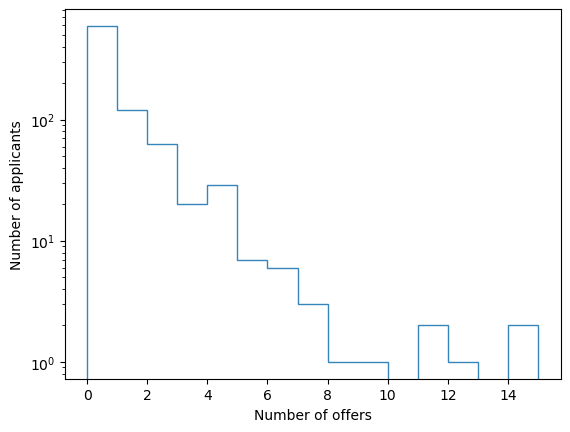

In [42]:
plt.hist(offer_numbers, histtype = 'step', alpha = 0.9, bins = np.max(offer_numbers), log = 1)
plt.xlabel('Number of offers')
plt.ylabel('Number of applicants')

Text(0, 0.5, 'Number of offers per applicant')

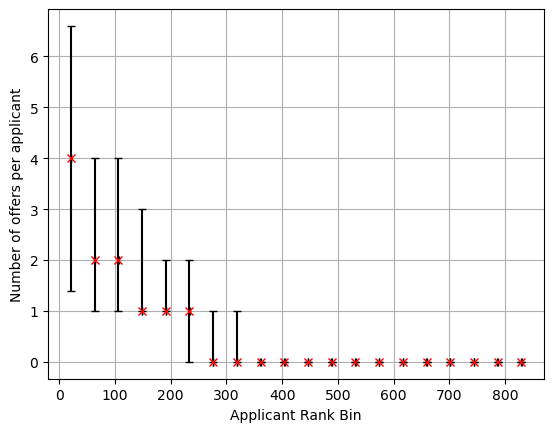

In [23]:
medians = []
iqr_up =[]
iqr_down = []
global_ranks = np.arange(len(offer_numbers))

nbins = 20
delta = len(offer_numbers)//nbins
for i in range(nbins):
    mask = np.logical_and(global_ranks>delta*i, global_ranks<delta*(i+1))
    n_offers_bin = offer_numbers[mask]
    n_offers_bin = n_offers_bin.astype(float)
    medians.append( np.median(n_offers_bin) )
    n_offers_bin += np.random.normal(0, 0.0, size = len(n_offers_bin) )
    iqr_up.append( np.percentile(n_offers_bin, 84) - np.median(n_offers_bin))
    iqr_down.append( np.median(n_offers_bin)-np.percentile(n_offers_bin, 16) )

bin_centers = np.linspace(0, len(offer_numbers)-delta, nbins)+delta/2
plt.errorbar(bin_centers, medians, xerr = 0.5, yerr = [iqr_down, iqr_up], fmt = 'rx', ecolor = 'k', capsize = 3)
plt.grid(True)

plt.locator_params(axis='both', integer=True)
plt.xlabel('Applicant Rank Bin')
plt.ylabel('Number of offers per applicant')

Text(0, 0.5, 'Number of offers per applicant')

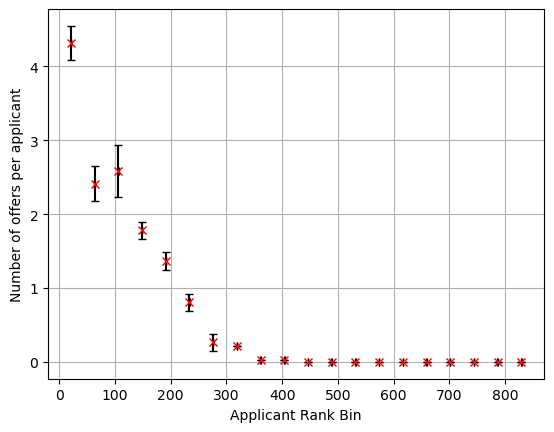

In [24]:
means = []
stds =[]
global_ranks = np.arange(len(offer_numbers))

nbins = 20
delta = len(offer_numbers)//nbins
for i in range(nbins):
    mask = np.logical_and(global_ranks>delta*i, global_ranks<delta*(i+1))
    n_offers_bin = offer_numbers[mask]
    means.append( np.mean(n_offers_bin) )
    # stds.append( np.std(n_offers_bin))
    stds.append( (np.percentile(n_offers_bin, 75)-np.percentile(n_offers_bin, 25))/1.349/np.sqrt(len(n_offers_bin)))


bin_centers = np.linspace(0, len(offer_numbers)-delta, nbins)+delta/2
plt.errorbar(bin_centers, means, xerr = 0.5, yerr = stds, fmt = 'rx', ecolor = 'k', capsize = 3)
plt.grid(True)

plt.locator_params(axis='both', integer=True)
plt.xlabel('Applicant Rank Bin')
plt.ylabel('Number of offers per applicant')

array([[1.        , 0.01513285],
       [0.01513285, 1.        ]])

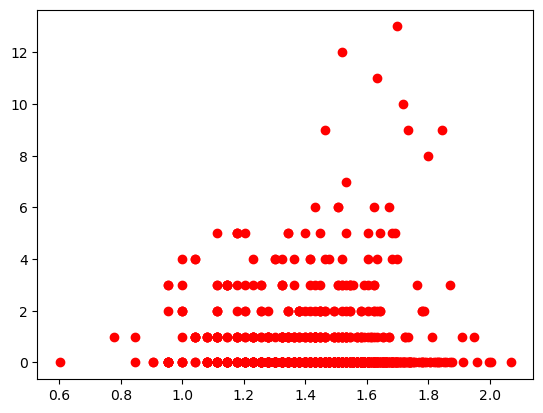

In [25]:
plt.plot(np.log10(applications_sent), offer_numbers, 'ro')
np.corrcoef([applications_sent, offer_numbers])

array([[1.        , 0.10006589],
       [0.10006589, 1.        ]])

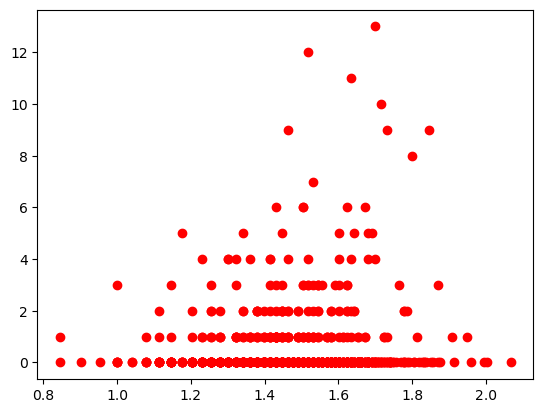

In [26]:
plt.plot(np.log10(applications_sent[student_or_postdoc]), offer_numbers[student_or_postdoc], 'ro')
np.corrcoef([applications_sent[student_or_postdoc], offer_numbers[student_or_postdoc]])

array([[1.        , 0.15463358],
       [0.15463358, 1.        ]])

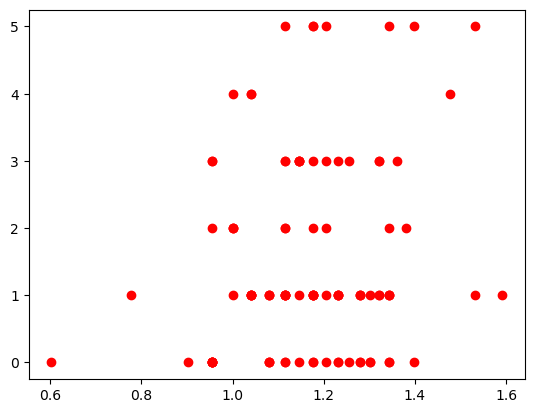

In [27]:
plt.plot(np.log10(applications_sent[~student_or_postdoc]), offer_numbers[~student_or_postdoc], 'ro')
np.corrcoef([applications_sent[~student_or_postdoc], offer_numbers[~student_or_postdoc]])

array([[1.        , 0.14176599],
       [0.14176599, 1.        ]])

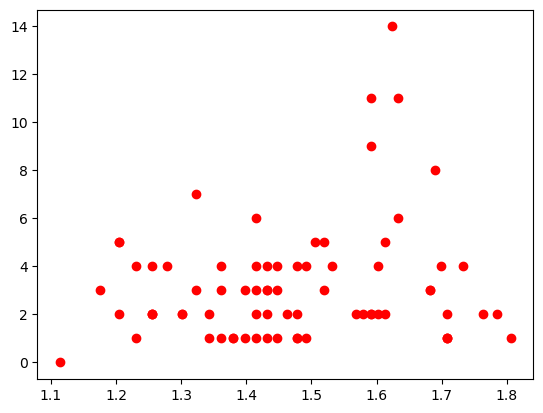

In [47]:
percentiles = [0, 10] 
student_ranks = np.arange(sum(student_or_postdoc))
rank_mask = np.logical_and(student_ranks>percentiles[0]/100*sum(student_or_postdoc),\
                           student_ranks<percentiles[1]/100*sum(student_or_postdoc))

plt.plot(np.log10(applications_sent[student_or_postdoc][rank_mask]), offer_numbers[student_or_postdoc][rank_mask], 'ro')
np.corrcoef([ applications_sent[student_or_postdoc][rank_mask], offer_numbers[student_or_postdoc][rank_mask] ])

array([[1.        , 0.14176599],
       [0.14176599, 1.        ]])

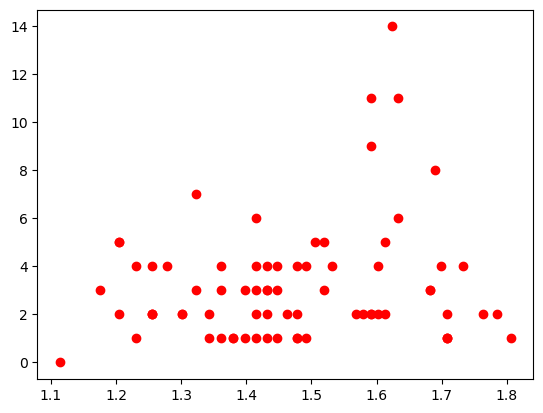

In [46]:
percentiles = [0, 10] 
student_ranks = np.arange(sum(student_or_postdoc))
rank_mask = np.logical_and(student_ranks>percentiles[0]/100*sum(student_or_postdoc),\
                           student_ranks<percentiles[1]/100*sum(student_or_postdoc))

plt.plot(np.log10(applications_sent[student_or_postdoc][rank_mask]), offer_numbers[student_or_postdoc][rank_mask], 'ro')
np.corrcoef([ applications_sent[student_or_postdoc][rank_mask], offer_numbers[student_or_postdoc][rank_mask] ])

In [56]:
"""
Postdoctoral Job Market Heatmap  (multi-run edition)
=====================================================
Plots a 2D heatmap where:
  - X-axis: applicant percentile rank (0–100, lower = better)
  - Y-axis: number of applications sent
  - Color:  mean number of offers received in each bin

Running N independent markets pools all applicants before binning,
giving much smoother statistics especially in sparse regions.

Usage
-----
    # from your_module import ApplicantCohort

    plot_heatmap_multi_run(
        cohort_kwargs=dict(n_students=1000, n_postdocs=300),
        n_runs=10,
        applicant_type="student",
    )

Dependencies: numpy, matplotlib, tqdm (optional progress bar)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
from typing import Optional, Tuple

try:
    from tqdm import trange
except ImportError:
    trange = None


# ─────────────────────────────────────────────────────────────────────────────
# Multi-run data collector
# ─────────────────────────────────────────────────────────────────────────────

def collect_multi_run(
    cohort_kwargs:   dict,
    n_runs:          int  = 10,
    offer_rounds:    int  = 10,
    applicant_type:  str  = "both",   # "student", "postdoc", or "both"
    verbose_cohort:  int  = 0,        # passed to ApplicantCohort(verbose=...)
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run N independent markets and pool all applicants into flat arrays.

    Returns
    -------
    percentiles    : rank of each applicant expressed as a percentile (0–100)
    n_applications : applications sent by each applicant
    n_offers       : total offers received by each applicant
    """
    all_pct  = []
    all_apps = []
    all_off  = []

    iterator = trange(n_runs, desc="Running markets") if trange else range(n_runs)

    for run_i in iterator:
        if trange is None:
            print(f"  Market {run_i + 1}/{n_runs} ...", flush=True)

        kw = dict(cohort_kwargs)          # shallow copy so defaults stay clean
        kw["verbose"] = verbose_cohort
        cohort = ApplicantCohort(**kw)
        cohort.run_market(offer_rounds=offer_rounds)

        applicants = cohort.applicants
        n_total    = len(applicants)

        if applicant_type == "student":
            applicants = [a for a in applicants if a["currently"] == "student"]
        elif applicant_type == "postdoc":
            applicants = [a for a in applicants if a["currently"] == "postdoc"]

        ranks    = np.array([a["rank"]                  for a in applicants])
        n_apps   = np.array([a["n_applications"]        for a in applicants], dtype=float)
        n_offers = np.array([a["total_offers_received"] for a in applicants], dtype=float)

        # Percentile relative to the *full* cohort of that run
        all_pct .append(ranks / n_total * 100)
        all_apps.append(n_apps)
        all_off .append(n_offers)

    return (
        np.concatenate(all_pct),
        np.concatenate(all_apps),
        np.concatenate(all_off),
    )


# ─────────────────────────────────────────────────────────────────────────────
# Top-level convenience function
# ─────────────────────────────────────────────────────────────────────────────

def plot_heatmap_multi_run(
    cohort_kwargs:  dict  = None,
    n_runs:         int   = 10,
    offer_rounds:   int   = 10,
    applicant_type: str   = "both",
    n_rank_bins:    int   = 20,
    n_app_bins:     int   = 20,
    log_y:          bool  = True,
    cmap:           str   = "plasma",
    min_count:      int   = 3,
    figsize:        tuple = (9, 6),
    title:          Optional[str] = None,
    save_path:      Optional[str] = None,
):
    """
    Run N markets, pool results, and plot a heatmap.

    Parameters
    ----------
    cohort_kwargs  : dict of keyword arguments forwarded to ApplicantCohort()
                     (omit 'verbose'; controlled separately)
    n_runs         : number of independent markets to simulate
    offer_rounds   : rounds per market (passed to run_market)
    applicant_type : 'student', 'postdoc', or 'both'
    (remaining parameters same as plot_heatmap_from_arrays)
    """
    if cohort_kwargs is None:
        cohort_kwargs = {}

    print(f"Simulating {n_runs} markets  (applicant_type='{applicant_type}') …")
    percentiles, n_apps, n_offers = collect_multi_run(
        cohort_kwargs=cohort_kwargs,
        n_runs=n_runs,
        offer_rounds=offer_rounds,
        applicant_type=applicant_type,
    )
    print(f"Pooled {len(percentiles):,} applicants across {n_runs} runs.")

    auto_title = (
        f"Mean offers by rank & applications sent"
        f"  ({applicant_type}, N={n_runs} markets)"
    )

    plot_heatmap_from_arrays(
        percentiles=percentiles,
        n_applications=n_apps,
        n_offers=n_offers,
        n_rank_bins=n_rank_bins,
        n_app_bins=n_app_bins,
        log_y=log_y,
        cmap=cmap,
        min_count=min_count,
        figsize=figsize,
        title=title or auto_title,
        save_path=save_path,
    )


# ─────────────────────────────────────────────────────────────────────────────
# Single-cohort plotting function (convenience wrapper)
# ─────────────────────────────────────────────────────────────────────────────

def plot_heatmap(
    cohort,
    applicant_type: str = "both",   # "student", "postdoc", or "both"
    n_rank_bins: int = 20,
    n_app_bins: int = 20,
    log_y: bool = True,
    cmap: str = "plasma",
    min_count: int = 3,             # bins with fewer observations are masked
    figsize: Tuple = (9, 6),
    title: Optional[str] = None,
    save_path: Optional[str] = None,
):
    """
    Build a heatmap from a finished ApplicantCohort object.

    Parameters
    ----------
    cohort        : ApplicantCohort   – must have run_market() called already
    applicant_type: filter to 'student', 'postdoc', or 'both'
    n_rank_bins   : number of x-axis (percentile) bins
    n_app_bins    : number of y-axis (applications sent) bins
    log_y         : use log10 scale on y-axis
    cmap          : matplotlib colormap name
    min_count     : mask bins with fewer than this many observations
    figsize       : figure size in inches
    title         : optional plot title (auto-generated if None)
    save_path     : if given, save figure to this path instead of showing
    """
    applicants = cohort.applicants
    n_total    = len(applicants)

    if applicant_type == "student":
        applicants = [a for a in applicants if a["currently"] == "student"]
    elif applicant_type == "postdoc":
        applicants = [a for a in applicants if a["currently"] == "postdoc"]

    ranks         = np.array([a["rank"]                    for a in applicants])
    n_apps        = np.array([a["n_applications"]          for a in applicants], dtype=float)
    n_offers      = np.array([a["total_offers_received"]   for a in applicants], dtype=float)

    # Convert ranks → percentile (0 = best, 100 = worst)
    percentiles = ranks / n_total * 100

    plot_heatmap_from_arrays(
        percentiles=percentiles,
        n_applications=n_apps,
        n_offers=n_offers,
        n_rank_bins=n_rank_bins,
        n_app_bins=n_app_bins,
        log_y=log_y,
        cmap=cmap,
        min_count=min_count,
        figsize=figsize,
        title=title or f"Offer rate by rank & applications sent  ({applicant_type})",
        save_path=save_path,
    )


def plot_heatmap_from_arrays(
    percentiles:    np.ndarray,
    n_applications: np.ndarray,
    n_offers:       np.ndarray,
    n_rank_bins:    int   = 20,
    n_app_bins:     int   = 20,
    log_y:          bool  = True,
    cmap:           str   = "plasma",
    min_count:      int   = 3,
    figsize:        tuple = (9, 6),
    title:          str   = "Mean offers by applicant rank & applications sent",
    save_path:      Optional[str] = None,
):
    """
    Low-level heatmap function that works directly on numpy arrays.

    Parameters
    ----------
    percentiles    : 1-D array, applicant rank expressed as percentile (0–100)
    n_applications : 1-D array, number of applications each applicant sent
    n_offers       : 1-D array, total offers each applicant received
    (remaining parameters same as plot_heatmap)
    """
    # ── bin edges ────────────────────────────────────────────────────────────
    x_edges = np.linspace(0, 100, n_rank_bins + 1)

    if log_y:
        y_min = np.log10(max(n_applications.min(), 1))
        y_max = np.log10(n_applications.max()) + 1e-9
        y_edges = np.linspace(y_min, y_max, n_app_bins + 1)
        y_vals  = np.log10(np.clip(n_applications, 1, None))
    else:
        y_edges = np.linspace(n_applications.min(), n_applications.max(), n_app_bins + 1)
        y_vals  = n_applications.astype(float)

    # ── accumulate sums & counts ──────────────────────────────────────────────
    x_idx = np.clip(np.digitize(percentiles, x_edges) - 1, 0, n_rank_bins - 1)
    y_idx = np.clip(np.digitize(y_vals,      y_edges) - 1, 0, n_app_bins  - 1)

    offer_sum = np.zeros((n_app_bins, n_rank_bins))
    counts    = np.zeros((n_app_bins, n_rank_bins))

    for xi, yi, o in zip(x_idx, y_idx, n_offers):
        offer_sum[yi, xi] += o
        counts[yi, xi]    += 1

    # ── mean offers per bin, mask sparse bins ─────────────────────────────────
    with np.errstate(invalid="ignore", divide="ignore"):
        mean_offers = np.where(counts >= min_count, offer_sum / counts, np.nan)

    masked = np.ma.masked_invalid(mean_offers)

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    cm = plt.get_cmap(cmap).copy()
    cm.set_bad(color="#1a1a2e")          # dark background for masked cells

    im = ax.pcolormesh(
        x_edges, y_edges, masked,
        cmap=cm,
        shading="flat",
        norm=mcolors.PowerNorm(gamma=0.6, vmin=np.nanmin(mean_offers), vmax=np.nanmax(mean_offers)),
    )

    # ── colorbar ──────────────────────────────────────────────────────────────
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Mean offers received", fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    # ── axes labels & ticks ───────────────────────────────────────────────────
    ax.set_xlabel("Applicant percentile rank  (0 = best)", fontsize=12)

    if log_y:
        ax.set_ylabel("Applications sent  (log₁₀ scale)", fontsize=12)
        # Replace raw log-tick labels with plain numbers
        tick_vals = np.arange(np.floor(y_edges[0]), np.ceil(y_edges[-1]) + 1)
        ax.set_yticks(tick_vals)
        ax.set_yticklabels([f"{10**v:.0f}" for v in tick_vals], fontsize=9)
    else:
        ax.set_ylabel("Applications sent", fontsize=12)

    ax.set_xlim(0, 100)
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.tick_params(axis="x", labelsize=9)

    # ── overlay sample-count contour (optional) ───────────────────────────────
    x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])
    Xc, Yc = np.meshgrid(x_centres, y_centres)
    cs = ax.contour(Xc, Yc, counts, levels=[10, 30, 100],
                    colors="white", linewidths=0.6, alpha=0.45, linestyles="--")
    ax.clabel(cs, fmt="%d obs", fontsize=7, inline=True)

    ax.set_title(title, fontsize=13, pad=10)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Figure saved to {save_path}")
    else:
        plt.show()

    return fig, ax

In [60]:

N_RUNS = 20

# for atype in ("student", "postdoc", "both"):
for atype in ["student"]:
    plot_heatmap_multi_run(
        cohort_kwargs=dict(
            n_students=1000,
            n_postdocs=300,
        ),
        n_runs=N_RUNS,
        offer_rounds=10,
        applicant_type=atype,
        n_rank_bins=25,
        n_app_bins=20,
        log_y=True,
        cmap="plasma",
        min_count=3,
        # save_path=f"heatmap_{atype}_N{N_RUNS}.png",  # uncomment to save
    )

In [81]:
"""
Postdoctoral Job Market Heatmap  (multi-run edition)
=====================================================
Plots a 2D heatmap where:
  - X-axis: applicant percentile rank (0–100, lower = better)
  - Y-axis: number of applications sent
  - Color:  mean number of offers received in each bin

Running N independent markets pools all applicants before binning,
giving much smoother statistics especially in sparse regions.

Usage
-----
    # from your_module import ApplicantCohort

    plot_heatmap_multi_run(
        cohort_kwargs=dict(n_students=1000, n_postdocs=300),
        n_runs=10,
        applicant_type="student",
    )

Dependencies: numpy, matplotlib, tqdm (optional progress bar)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
from typing import Optional, Tuple

try:
    from tqdm import trange
except ImportError:
    trange = None


# ─────────────────────────────────────────────────────────────────────────────
# Multi-run data collector
# ─────────────────────────────────────────────────────────────────────────────

def collect_multi_run(
    cohort_kwargs:   dict,
    n_runs:          int  = 10,
    offer_rounds:    int  = 10,
    applicant_type:  str  = "both",   # "student", "postdoc", or "both"
    verbose_cohort:  int  = 0,        # passed to ApplicantCohort(verbose=...)
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run N independent markets and pool all applicants into flat arrays.

    Returns
    -------
    percentiles    : rank of each applicant expressed as a percentile (0–100)
    n_applications : applications sent by each applicant
    n_offers       : total offers received by each applicant
    """
    all_pct  = []
    all_apps = []
    all_off  = []

    iterator = trange(n_runs, desc="Running markets") if trange else range(n_runs)

    for run_i in iterator:
        if trange is None:
            print(f"  Market {run_i + 1}/{n_runs} ...", flush=True)

        kw = dict(cohort_kwargs)          # shallow copy so defaults stay clean
        kw["verbose"] = verbose_cohort
        cohort = ApplicantCohort(**kw)
        cohort.run_market(offer_rounds=offer_rounds)

        applicants = cohort.applicants
        n_total    = len(applicants)

        if applicant_type == "student":
            applicants = [a for a in applicants if a["currently"] == "student"]
        elif applicant_type == "postdoc":
            applicants = [a for a in applicants if a["currently"] == "postdoc"]

        ranks    = np.array([a["rank"]                  for a in applicants])
        n_apps   = np.array([a["n_applications"]        for a in applicants], dtype=float)
        n_offers = np.array([a["total_offers_received"] for a in applicants], dtype=float)

        # Percentile relative to the *full* cohort of that run
        all_pct .append(ranks / n_total * 100)
        all_apps.append(n_apps)
        all_off .append(n_offers)

    return (
        np.concatenate(all_pct),
        np.concatenate(all_apps),
        np.concatenate(all_off),
    )


# ─────────────────────────────────────────────────────────────────────────────
# Top-level convenience function
# ─────────────────────────────────────────────────────────────────────────────

def plot_heatmap_multi_run(
    cohort_kwargs:  dict  = None,
    n_runs:         int   = 10,
    offer_rounds:   int   = 10,
    applicant_type: str   = "both",
    n_rank_bins:    int   = 20,
    n_app_bins:     int   = 20,
    log_y:          bool  = True,
    ylim:           Optional[Tuple] = None,
    cmap:           str   = "plasma",
    min_count:      int   = 3,
    figsize:        Tuple = (9, 6),
    title:          Optional[str] = None,
    save_path:      Optional[str] = None,
):
    """
    Run N markets, pool results, and plot a heatmap.

    Parameters
    ----------
    cohort_kwargs  : dict of keyword arguments forwarded to ApplicantCohort()
                     (omit 'verbose'; controlled separately)
    n_runs         : number of independent markets to simulate
    offer_rounds   : rounds per market (passed to run_market)
    applicant_type : 'student', 'postdoc', or 'both'
    ylim           : (min, max) y-axis limits in data units (raw app counts,
                     e.g. (1, 100)); None = use data range
    (remaining parameters same as plot_heatmap_from_arrays)
    """
    if cohort_kwargs is None:
        cohort_kwargs = {}

    print(f"Simulating {n_runs} markets  (applicant_type='{applicant_type}') …")
    percentiles, n_apps, n_offers = collect_multi_run(
        cohort_kwargs=cohort_kwargs,
        n_runs=n_runs,
        offer_rounds=offer_rounds,
        applicant_type=applicant_type,
    )
    print(f"Pooled {len(percentiles):,} applicants across {n_runs} runs.")

    auto_title = (
        f"Mean offers by rank & applications sent"
        f"  ({applicant_type}, N={n_runs} markets)"
    )

    plot_heatmap_from_arrays(
        percentiles=percentiles,
        n_applications=n_apps,
        n_offers=n_offers,
        n_rank_bins=n_rank_bins,
        n_app_bins=n_app_bins,
        log_y=log_y,
        ylim=ylim,
        cmap=cmap,
        min_count=min_count,
        figsize=figsize,
        title=title or auto_title,
        save_path=save_path,
    )


# ─────────────────────────────────────────────────────────────────────────────
# Single-cohort plotting function (convenience wrapper)
# ─────────────────────────────────────────────────────────────────────────────

def plot_heatmap(
    cohort,
    applicant_type: str = "both",   # "student", "postdoc", or "both"
    n_rank_bins: int = 20,
    n_app_bins: int = 20,
    log_y: bool = True,
    ylim: Optional[Tuple] = None,
    cmap: str = "plasma",
    min_count: int = 3,             # bins with fewer observations are masked
    figsize: Tuple = (9, 6),
    title: Optional[str] = None,
    save_path: Optional[str] = None,
):
    """
    Build a heatmap from a finished ApplicantCohort object.

    Parameters
    ----------
    cohort        : ApplicantCohort   – must have run_market() called already
    applicant_type: filter to 'student', 'postdoc', or 'both'
    n_rank_bins   : number of x-axis (percentile) bins
    n_app_bins    : number of y-axis (applications sent) bins
    log_y         : use log10 scale on y-axis
    ylim          : (min, max) y-axis limits in data units (raw app counts);
                    None = use data range
    cmap          : matplotlib colormap name
    min_count     : mask bins with fewer than this many observations
    figsize       : figure size in inches
    title         : optional plot title (auto-generated if None)
    save_path     : if given, save figure to this path instead of showing
    """
    applicants = cohort.applicants
    n_total    = len(applicants)

    if applicant_type == "student":
        applicants = [a for a in applicants if a["currently"] == "student"]
    elif applicant_type == "postdoc":
        applicants = [a for a in applicants if a["currently"] == "postdoc"]

    ranks         = np.array([a["rank"]                    for a in applicants])
    n_apps        = np.array([a["n_applications"]          for a in applicants], dtype=float)
    n_offers      = np.array([a["total_offers_received"]   for a in applicants], dtype=float)

    # Convert ranks → percentile (0 = best, 100 = worst)
    percentiles = ranks / n_total * 100

    plot_heatmap_from_arrays(
        percentiles=percentiles,
        n_applications=n_apps,
        n_offers=n_offers,
        n_rank_bins=n_rank_bins,
        n_app_bins=n_app_bins,
        log_y=log_y,
        ylim=ylim,
        cmap=cmap,
        min_count=min_count,
        figsize=figsize,
        title=title or f"Offer rate by rank & applications sent  ({applicant_type})",
        save_path=save_path,
    )


def plot_heatmap_from_arrays(
    percentiles:    np.ndarray,
    n_applications: np.ndarray,
    n_offers:       np.ndarray,
    n_rank_bins:    int            = 20,
    n_app_bins:     int            = 20,
    log_y:          bool           = True,
    ylim:           Optional[Tuple] = None,
    cmap:           str            = "plasma",
    min_count:      int            = 3,
    figsize:        Tuple          = (9, 6),
    title:          str            = "Mean offers by applicant rank & applications sent",
    save_path:      Optional[str]  = None,
):
    """
    Low-level heatmap function that works directly on numpy arrays.

    Parameters
    ----------
    percentiles    : 1-D array, applicant rank expressed as percentile (0–100)
    n_applications : 1-D array, number of applications each applicant sent
    n_offers       : 1-D array, total offers each applicant received
    ylim           : (min, max) y-axis limits in raw application counts
                     e.g. (1, 100).  None = use full data range.
    (remaining parameters same as plot_heatmap)
    """
    # ── bin edges  (respect ylim if given) ───────────────────────────────────
    x_edges = np.linspace(0, 100, n_rank_bins + 1)

    if log_y:
        if ylim is not None:
            y_min = np.log10(max(ylim[0], 1))
            y_max = np.log10(max(ylim[1], 1)) + 1e-9
        else:
            y_min = np.log10(max(n_applications.min(), 1))
            y_max = np.log10(n_applications.max()) + 1e-9
        y_edges = np.linspace(y_min, y_max, n_app_bins + 1)
        y_vals  = np.log10(np.clip(n_applications, 1, None))
    else:
        if ylim is not None:
            y_min, y_max = ylim
        else:
            y_min, y_max = n_applications.min(), n_applications.max()
        y_edges = np.linspace(y_min, y_max, n_app_bins + 1)
        y_vals  = n_applications.astype(float)

    # ── accumulate sums & counts ──────────────────────────────────────────────
    x_idx = np.clip(np.digitize(percentiles, x_edges) - 1, 0, n_rank_bins - 1)
    y_idx = np.clip(np.digitize(y_vals,      y_edges) - 1, 0, n_app_bins  - 1)

    offer_sum = np.zeros((n_app_bins, n_rank_bins))
    counts    = np.zeros((n_app_bins, n_rank_bins))

    for xi, yi, o in zip(x_idx, y_idx, n_offers):
        offer_sum[yi, xi] += o
        counts[yi, xi]    += 1

    # ── mean offers per bin, mask sparse bins ─────────────────────────────────
    with np.errstate(invalid="ignore", divide="ignore"):
        mean_offers = np.where(counts >= min_count, offer_sum / counts, np.nan)

    masked = np.ma.masked_invalid(mean_offers)

    # ── build colormap: white for exactly 0 offers, cmap for > 0 ─────────────
    #   Strategy: prepend a single white entry to the base colormap so that
    #   vmin=0 maps to white while all positive values use the full palette.
    base_cm   = plt.get_cmap(cmap)
    # Sample the base cmap from a small offset so its dark end isn't lost
    n_colors  = 256
    rgba      = base_cm(np.linspace(0.0, 1.0, n_colors - 1))
    white     = np.array([[1.0, 1.0, 1.0, 1.0]])
    all_rgba  = np.vstack([white, rgba])
    cm = mcolors.ListedColormap(all_rgba)
    cm.set_bad(color="#1a1a2e")           # dark background for masked/sparse cells

    vmax = np.nanmax(mean_offers) if not np.all(np.isnan(mean_offers)) else 1.0
    # Boundary between white (0) and the rest: place it just above 0
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1e-2, vmax=vmax)

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.pcolormesh(
        x_edges, y_edges, masked,
        cmap=cm,
        shading="flat",
        norm=norm,
    )

    # ── colorbar ──────────────────────────────────────────────────────────────
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Mean offers received", fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    # ── axes labels & ticks ───────────────────────────────────────────────────
    ax.set_xlabel("Applicant percentile rank  (0 = best)", fontsize=12)

    if log_y:
        ax.set_ylabel("Applications sent  (log₁₀ scale)", fontsize=12)
        tick_vals = np.arange(np.floor(y_edges[0]), np.ceil(y_edges[-1]) + 1)
        ax.set_yticks(tick_vals)
        ax.set_yticklabels([f"{10**v:.0f}" for v in tick_vals], fontsize=9)
    else:
        ax.set_ylabel("Applications sent", fontsize=12)

    ax.set_xlim(0, 100)
    ax.set_ylim(y_edges[0], y_edges[-1])
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.tick_params(axis="x", labelsize=9)

    # ── overlay sample-count contour (optional) ───────────────────────────────
    x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])
    Xc, Yc = np.meshgrid(x_centres, y_centres)
    cs = ax.contour(Xc, Yc, counts, levels=[10, 30, 100],
                    colors="white", linewidths=0.6, alpha=0.45, linestyles="--")
    ax.clabel(cs, fmt="%d obs", fontsize=7, inline=True)

    ax.set_title(title, fontsize=13, pad=10)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Figure saved to {save_path}")
    else:
        plt.show()

    return fig, ax

Simulating 10 markets  (applicant_type='student') …


Running markets: 100%|███████████████████████████████████████████████████████| 10/10 [00:45<00:00,  4.59s/it]


Pooled 7,500 applicants across 10 runs.


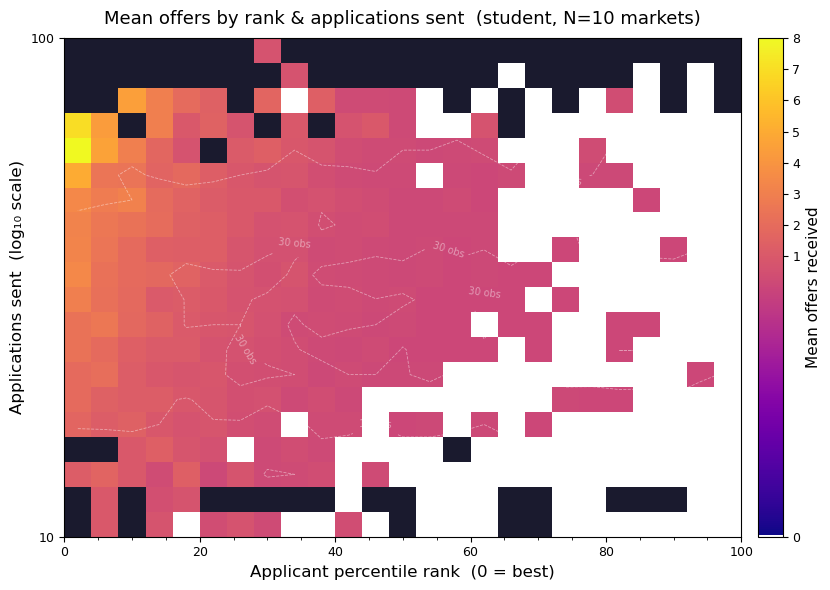

In [82]:
N_RUNS = 10   # ← tune this

# for atype in ["student", 'both']:
for atype in ["student"]:
    plot_heatmap_multi_run(
        cohort_kwargs=dict(
            n_students=1000,
            n_postdocs=300,
        ),
        ylim=(10, 100),
        n_runs=N_RUNS,
        offer_rounds=10,
        applicant_type=atype,
        n_rank_bins=25,
        n_app_bins=20,
        log_y=True,
        cmap="plasma",
        min_count=np.max([3, int(np.sqrt(N_RUNS))]),
        # save_path=f"heatmap_{atype}_N{N_RUNS}.png",  # uncomment to save
    )

In [79]:
"""
Postdoctoral Job Market Heatmap  (multi-run edition)
=====================================================
Plots a 2D heatmap where:
  - X-axis: applicant percentile rank (0–100, lower = better)
  - Y-axis: number of applications sent
  - Color:  mean number of offers received in each bin

Running N independent markets pools all applicants before binning,
giving much smoother statistics especially in sparse regions.

Usage
-----
    # from your_module import ApplicantCohort

    plot_heatmap_multi_run(
        cohort_kwargs=dict(n_students=1000, n_postdocs=300),
        n_runs=10,
        applicant_type="student",
    )

Dependencies: numpy, matplotlib, tqdm (optional progress bar)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
from typing import Optional, Tuple

try:
    from tqdm import trange
except ImportError:
    trange = None


# ─────────────────────────────────────────────────────────────────────────────
# Multi-run data collector
# ─────────────────────────────────────────────────────────────────────────────

def collect_multi_run(
    cohort_kwargs:   dict,
    n_runs:          int  = 10,
    offer_rounds:    int  = 10,
    applicant_type:  str  = "both",   # "student", "postdoc", or "both"
    verbose_cohort:  int  = 0,        # passed to ApplicantCohort(verbose=...)
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run N independent markets and pool all applicants into flat arrays.

    Returns
    -------
    percentiles    : rank of each applicant expressed as a percentile (0–100)
    n_applications : applications sent by each applicant
    n_offers       : total offers received by each applicant
    """
    all_pct  = []
    all_apps = []
    all_off  = []

    iterator = trange(n_runs, desc="Running markets") if trange else range(n_runs)

    for run_i in iterator:
        if trange is None:
            print(f"  Market {run_i + 1}/{n_runs} ...", flush=True)

        kw = dict(cohort_kwargs)          # shallow copy so defaults stay clean
        kw["verbose"] = verbose_cohort
        cohort = ApplicantCohort(**kw)
        cohort.run_market(offer_rounds=offer_rounds)

        applicants = cohort.applicants
        n_total    = len(applicants)

        if applicant_type == "student":
            applicants = [a for a in applicants if a["currently"] == "student"]
        elif applicant_type == "postdoc":
            applicants = [a for a in applicants if a["currently"] == "postdoc"]

        ranks    = np.array([a["rank"]                  for a in applicants])
        n_apps   = np.array([a["n_applications"]        for a in applicants], dtype=float)
        n_offers = np.array([a["total_offers_received"] for a in applicants], dtype=float)

        # Percentile relative to the *full* cohort of that run
        all_pct .append(ranks / n_total * 100)
        all_apps.append(n_apps)
        all_off .append(n_offers)

    return (
        np.concatenate(all_pct),
        np.concatenate(all_apps),
        np.concatenate(all_off),
    )


# ─────────────────────────────────────────────────────────────────────────────
# Top-level convenience function
# ─────────────────────────────────────────────────────────────────────────────

def plot_heatmap_multi_run(
    cohort_kwargs:  dict  = None,
    n_runs:         int   = 10,
    offer_rounds:   int   = 10,
    applicant_type: str   = "both",
    n_rank_bins:    int   = 20,
    n_app_bins:     int   = 20,
    log_y:          bool  = True,
    ylim:           Optional[Tuple] = None,
    cmap:           str   = "plasma",
    min_count:      int   = 3,
    figsize:        Tuple = (9, 6),
    title:          Optional[str] = None,
    save_path:      Optional[str] = None,
):
    """
    Run N markets, pool results, and plot a heatmap.

    Parameters
    ----------
    cohort_kwargs  : dict of keyword arguments forwarded to ApplicantCohort()
                     (omit 'verbose'; controlled separately)
    n_runs         : number of independent markets to simulate
    offer_rounds   : rounds per market (passed to run_market)
    applicant_type : 'student', 'postdoc', or 'both'
    ylim           : (min, max) y-axis limits in data units (raw app counts,
                     e.g. (1, 100)); None = use data range
    (remaining parameters same as plot_heatmap_from_arrays)
    """
    if cohort_kwargs is None:
        cohort_kwargs = {}

    print(f"Simulating {n_runs} markets  (applicant_type='{applicant_type}') …")
    percentiles, n_apps, n_offers = collect_multi_run(
        cohort_kwargs=cohort_kwargs,
        n_runs=n_runs,
        offer_rounds=offer_rounds,
        applicant_type=applicant_type,
    )
    print(f"Pooled {len(percentiles):,} applicants across {n_runs} runs.")

    auto_title = (
        f"Mean offers by rank & applications sent"
        f"  ({applicant_type}, N={n_runs} markets)"
    )

    plot_heatmap_from_arrays(
        percentiles=percentiles,
        n_applications=n_apps,
        n_offers=n_offers,
        n_rank_bins=n_rank_bins,
        n_app_bins=n_app_bins,
        log_y=log_y,
        ylim=ylim,
        cmap=cmap,
        min_count=min_count,
        figsize=figsize,
        title=title or auto_title,
        save_path=save_path,
    )


# ─────────────────────────────────────────────────────────────────────────────
# Single-cohort plotting function (convenience wrapper)
# ─────────────────────────────────────────────────────────────────────────────

def plot_heatmap(
    cohort,
    applicant_type: str = "both",   # "student", "postdoc", or "both"
    n_rank_bins: int = 20,
    n_app_bins: int = 20,
    log_y: bool = True,
    ylim: Optional[Tuple] = None,
    cmap: str = "plasma",
    min_count: int = 3,             # bins with fewer observations are masked
    figsize: Tuple = (9, 6),
    title: Optional[str] = None,
    save_path: Optional[str] = None,
):
    """
    Build a heatmap from a finished ApplicantCohort object.

    Parameters
    ----------
    cohort        : ApplicantCohort   – must have run_market() called already
    applicant_type: filter to 'student', 'postdoc', or 'both'
    n_rank_bins   : number of x-axis (percentile) bins
    n_app_bins    : number of y-axis (applications sent) bins
    log_y         : use log10 scale on y-axis
    ylim          : (min, max) y-axis limits in data units (raw app counts);
                    None = use data range
    cmap          : matplotlib colormap name
    min_count     : mask bins with fewer than this many observations
    figsize       : figure size in inches
    title         : optional plot title (auto-generated if None)
    save_path     : if given, save figure to this path instead of showing
    """
    applicants = cohort.applicants
    n_total    = len(applicants)

    if applicant_type == "student":
        applicants = [a for a in applicants if a["currently"] == "student"]
    elif applicant_type == "postdoc":
        applicants = [a for a in applicants if a["currently"] == "postdoc"]

    ranks         = np.array([a["rank"]                    for a in applicants])
    n_apps        = np.array([a["n_applications"]          for a in applicants], dtype=float)
    n_offers      = np.array([a["total_offers_received"]   for a in applicants], dtype=float)

    # Convert ranks → percentile (0 = best, 100 = worst)
    percentiles = ranks / n_total * 100

    plot_heatmap_from_arrays(
        percentiles=percentiles,
        n_applications=n_apps,
        n_offers=n_offers,
        n_rank_bins=n_rank_bins,
        n_app_bins=n_app_bins,
        log_y=log_y,
        ylim=ylim,
        cmap=cmap,
        min_count=min_count,
        figsize=figsize,
        title=title or f"Offer rate by rank & applications sent  ({applicant_type})",
        save_path=save_path,
    )


def plot_heatmap_from_arrays(
    percentiles:    np.ndarray,
    n_applications: np.ndarray,
    n_offers:       np.ndarray,
    n_rank_bins:    int            = 20,
    n_app_bins:     int            = 20,
    log_y:          bool           = True,
    ylim:           Optional[Tuple] = None,
    cmap:           str            = "plasma",
    min_count:      int            = 3,
    figsize:        Tuple          = (9, 6),
    title:          str            = "Mean offers by applicant rank & applications sent",
    save_path:      Optional[str]  = None,
):
    """
    Low-level heatmap function that works directly on numpy arrays.

    Parameters
    ----------
    percentiles    : 1-D array, applicant rank expressed as percentile (0–100)
    n_applications : 1-D array, number of applications each applicant sent
    n_offers       : 1-D array, total offers each applicant received
    ylim           : (min, max) y-axis limits in raw application counts
                     e.g. (1, 100).  None = use full data range.
    (remaining parameters same as plot_heatmap)
    """
    # ── bin edges  (respect ylim if given) ───────────────────────────────────
    x_edges = np.linspace(0, 100, n_rank_bins + 1)

    if log_y:
        if ylim is not None:
            y_min = np.log10(max(ylim[0], 1))
            y_max = np.log10(max(ylim[1], 1)) + 1e-9
        else:
            y_min = np.log10(max(n_applications.min(), 1))
            y_max = np.log10(n_applications.max()) + 1e-9
        y_edges = np.linspace(y_min, y_max, n_app_bins + 1)
        y_vals  = np.log10(np.clip(n_applications, 1, None))
    else:
        if ylim is not None:
            y_min, y_max = ylim
        else:
            y_min, y_max = n_applications.min(), n_applications.max()
        y_edges = np.linspace(y_min, y_max, n_app_bins + 1)
        y_vals  = n_applications.astype(float)

    # ── accumulate sums & counts ──────────────────────────────────────────────
    x_idx = np.clip(np.digitize(percentiles, x_edges) - 1, 0, n_rank_bins - 1)
    y_idx = np.clip(np.digitize(y_vals,      y_edges) - 1, 0, n_app_bins  - 1)

    offer_sum = np.zeros((n_app_bins, n_rank_bins))
    counts    = np.zeros((n_app_bins, n_rank_bins))

    for xi, yi, o in zip(x_idx, y_idx, n_offers):
        offer_sum[yi, xi] += o
        counts[yi, xi]    += 1

    # ── mean offers per bin, mask sparse bins ─────────────────────────────────
    with np.errstate(invalid="ignore", divide="ignore"):
        mean_offers = np.where(counts >= min_count, offer_sum / counts, np.nan)

    masked = np.ma.masked_invalid(mean_offers)

    # ── build colormap: white for exactly 0 offers, cmap for > 0 ─────────────
    #   We use a BoundaryNorm with an explicit 0-only bin so that mean==0
    #   maps cleanly to white, while all positive values get the full palette.
    vmax = np.nanmax(mean_offers) if not np.all(np.isnan(mean_offers)) else 1.0

    n_colors   = 256
    base_cm    = plt.get_cmap(cmap)
    # One white slot for 0, then n_colors slots for (0, vmax]
    rgba_pos   = base_cm(np.linspace(0.0, 1.0, n_colors))
    white      = np.array([[1.0, 1.0, 1.0, 1.0]])
    all_rgba   = np.vstack([white, rgba_pos])          # length n_colors + 1
    cm         = mcolors.ListedColormap(all_rgba)
    cm.set_bad(color="#1a1a2e")                        # masked/sparse cells

    # BoundaryNorm: first boundary is the zero-only bin [0, epsilon],
    # then n_colors equal-width bins covering (epsilon, vmax].
    epsilon    = vmax / n_colors / 100                 # tiny — well below 1 offer
    pos_bounds = np.linspace(epsilon, vmax, n_colors + 1)
    boundaries = np.concatenate([[0.0, epsilon], pos_bounds[1:]])
    norm       = mcolors.BoundaryNorm(boundaries, ncolors=n_colors + 1)

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.pcolormesh(
        x_edges, y_edges, masked,
        cmap=cm,
        shading="flat",
        norm=norm,
    )

    # ── colorbar ──────────────────────────────────────────────────────────────
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Mean offers received", fontsize=11)
    int_ticks = np.arange(0, int(np.floor(vmax)) + 1)
    cbar.set_ticks(int_ticks)
    cbar.set_ticklabels([str(int(t)) for t in int_ticks])
    cbar.ax.tick_params(labelsize=9)

    # ── axes labels & ticks ───────────────────────────────────────────────────
    ax.set_xlabel("Applicant percentile rank  (0 = best)", fontsize=12)

    if log_y:
        ax.set_ylabel("Applications sent  (log₁₀ scale)", fontsize=12)
        tick_vals = np.arange(np.floor(y_edges[0]), np.ceil(y_edges[-1]) + 1)
        ax.set_yticks(tick_vals)
        ax.set_yticklabels([f"{10**v:.0f}" for v in tick_vals], fontsize=9)
    else:
        ax.set_ylabel("Applications sent", fontsize=12)

    ax.set_xlim(0, 100)
    ax.set_ylim(y_edges[0], y_edges[-1])
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.tick_params(axis="x", labelsize=9)

    # ── overlay sample-count contour (optional) ───────────────────────────────
    x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])
    Xc, Yc = np.meshgrid(x_centres, y_centres)
    cs = ax.contour(Xc, Yc, counts, levels=[10, 30, 100],
                    colors="white", linewidths=0.6, alpha=0.45, linestyles="--")
    ax.clabel(cs, fmt="%d obs", fontsize=7, inline=True)

    ax.set_title(title, fontsize=13, pad=10)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Figure saved to {save_path}")
    else:
        plt.show()

    return fig, ax

Simulating 20 markets  (applicant_type='student') …


Running markets: 100%|███████████████████████████████████████████████████████| 20/20 [01:27<00:00,  4.39s/it]


Pooled 15,000 applicants across 20 runs.


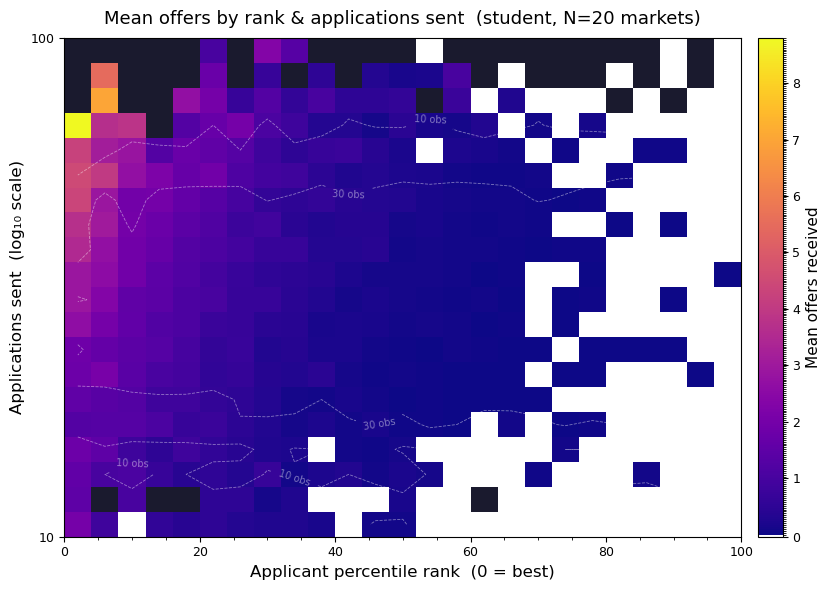

In [80]:
N_RUNS = 20   # ← tune this

for atype in ["student"]:
    plot_heatmap_multi_run(
        cohort_kwargs=dict(
            n_students=1000,
            n_postdocs=300,
        ),
        n_runs=N_RUNS,
        offer_rounds=10,
        applicant_type=atype,
        n_rank_bins=25,
        n_app_bins=20,
        ylim = (10, 100),
        log_y=True,
        cmap="plasma",
        min_count=3,
        # save_path=f"heatmap_{atype}_N{N_RUNS}.png",  # uncomment to save
    )

In [107]:
"""
Postdoctoral Job Market Heatmap  (multi-run edition)
=====================================================
Plots a 2D heatmap where:
  - X-axis: applicant percentile rank (0–100, lower = better)
  - Y-axis: number of applications sent
  - Color:  mean number of offers received in each bin

Running N independent markets pools all applicants before binning,
giving much smoother statistics especially in sparse regions.

Usage
-----
    # from your_module import ApplicantCohort

    plot_heatmap_multi_run(
        cohort_kwargs=dict(n_students=1000, n_postdocs=300),
        n_runs=10,
        applicant_type="student",
    )

Dependencies: numpy, matplotlib, tqdm (optional progress bar)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
from typing import Optional, Tuple

try:
    from tqdm import trange
except ImportError:
    trange = None


# ─────────────────────────────────────────────────────────────────────────────
# Multi-run data collector
# ─────────────────────────────────────────────────────────────────────────────

def collect_multi_run(
    cohort_kwargs:   dict,
    n_runs:          int  = 10,
    offer_rounds:    int  = 10,
    applicant_type:  str  = "both",   # "student", "postdoc", or "both"
    verbose_cohort:  int  = 0,        # passed to ApplicantCohort(verbose=...)
    stochasticity:  float = 0.7,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run N independent markets and pool all applicants into flat arrays.

    Returns
    -------
    percentiles    : rank of each applicant expressed as a percentile (0–100)
    n_applications : applications sent by each applicant
    n_offers       : total offers received by each applicant
    """
    all_pct  = []
    all_apps = []
    all_off  = []

    iterator = trange(n_runs, desc="Running markets") if trange else range(n_runs)

    for run_i in iterator:
        if trange is None:
            print(f"  Market {run_i + 1}/{n_runs} ...", flush=True)

        kw = dict(cohort_kwargs)          # shallow copy so defaults stay clean
        kw["verbose"] = verbose_cohort
        cohort = ApplicantCohort(**kw)
        cohort.run_market(offer_rounds=offer_rounds)

        applicants = cohort.applicants
        n_total    = len(applicants)

        if applicant_type == "student":
            applicants = [a for a in applicants if a["currently"] == "student"]
        elif applicant_type == "postdoc":
            applicants = [a for a in applicants if a["currently"] == "postdoc"]

        ranks    = np.array([a["rank"]                  for a in applicants])
        n_apps   = np.array([a["n_applications"]        for a in applicants], dtype=float)
        n_offers = np.array([a["total_offers_received"] for a in applicants], dtype=float)

        # Percentile relative to the *full* cohort of that run
        all_pct .append(ranks / n_total * 100)
        all_apps.append(n_apps)
        all_off .append(n_offers)

    return (
        np.concatenate(all_pct),
        np.concatenate(all_apps),
        np.concatenate(all_off),
    )


# ─────────────────────────────────────────────────────────────────────────────
# Top-level convenience function
# ─────────────────────────────────────────────────────────────────────────────

def plot_heatmap_multi_run(
    cohort_kwargs:  dict  = None,
    n_runs:         int   = 10,
    offer_rounds:   int   = 10,
    applicant_type: str   = "both",
    n_rank_bins:    int   = 20,
    n_app_bins:     int   = 20,
    log_y:          bool  = True,
    ylim:           Optional[Tuple] = None,
    cmap:           str   = "plasma",
    min_count:      int   = 3,
    figsize:        Tuple = (9, 6),
    title:          Optional[str] = None,
    save_path:      Optional[str] = None,
    stochasticity:  float = 0.7,
):
    """
    Run N markets, pool results, and plot a heatmap.

    Parameters
    ----------
    cohort_kwargs  : dict of keyword arguments forwarded to ApplicantCohort()
                     (omit 'verbose'; controlled separately)
    n_runs         : number of independent markets to simulate
    offer_rounds   : rounds per market (passed to run_market)
    applicant_type : 'student', 'postdoc', or 'both'
    ylim           : (min, max) y-axis limits in data units (raw app counts,
                     e.g. (1, 100)); None = use data range
    (remaining parameters same as plot_heatmap_from_arrays)
    """
    if cohort_kwargs is None:
        cohort_kwargs = {}

    print(f"Simulating {n_runs} markets  (applicant_type='{applicant_type}') …")
    percentiles, n_apps, n_offers = collect_multi_run(
        cohort_kwargs=cohort_kwargs,
        n_runs=n_runs,
        offer_rounds=offer_rounds,
        applicant_type=applicant_type,
        stochasticity = stochasticity,
    )
    print(f"Pooled {len(percentiles):,} applicants across {n_runs} runs.")

    auto_title = (
        f"Mean offers by rank & applications sent"
        f"  ({applicant_type}, N={n_runs} markets)"
    )

    plot_heatmap_from_arrays(
        percentiles=percentiles,
        n_applications=n_apps,
        n_offers=n_offers,
        n_rank_bins=n_rank_bins,
        n_app_bins=n_app_bins,
        log_y=log_y,
        ylim=ylim,
        cmap=cmap,
        min_count=min_count,
        figsize=figsize,
        title=title or auto_title,
        save_path=save_path,
    )


# ─────────────────────────────────────────────────────────────────────────────
# Single-cohort plotting function (convenience wrapper)
# ─────────────────────────────────────────────────────────────────────────────

def plot_heatmap(
    cohort,
    applicant_type: str = "both",   # "student", "postdoc", or "both"
    n_rank_bins: int = 20,
    n_app_bins: int = 20,
    log_y: bool = True,
    ylim: Optional[Tuple] = None,
    cmap: str = "plasma",
    min_count: int = 3,             # bins with fewer observations are masked
    figsize: Tuple = (9, 6),
    title: Optional[str] = None,
    save_path: Optional[str] = None,
):
    """
    Build a heatmap from a finished ApplicantCohort object.

    Parameters
    ----------
    cohort        : ApplicantCohort   – must have run_market() called already
    applicant_type: filter to 'student', 'postdoc', or 'both'
    n_rank_bins   : number of x-axis (percentile) bins
    n_app_bins    : number of y-axis (applications sent) bins
    log_y         : use log10 scale on y-axis
    ylim          : (min, max) y-axis limits in data units (raw app counts);
                    None = use data range
    cmap          : matplotlib colormap name
    min_count     : mask bins with fewer than this many observations
    figsize       : figure size in inches
    title         : optional plot title (auto-generated if None)
    save_path     : if given, save figure to this path instead of showing
    """
    applicants = cohort.applicants
    n_total    = len(applicants)

    if applicant_type == "student":
        applicants = [a for a in applicants if a["currently"] == "student"]
    elif applicant_type == "postdoc":
        applicants = [a for a in applicants if a["currently"] == "postdoc"]

    ranks         = np.array([a["rank"]                    for a in applicants])
    n_apps        = np.array([a["n_applications"]          for a in applicants], dtype=float)
    n_offers      = np.array([a["total_offers_received"]   for a in applicants], dtype=float)

    # Convert ranks → percentile (0 = best, 100 = worst)
    percentiles = ranks / n_total * 100

    plot_heatmap_from_arrays(
        percentiles=percentiles,
        n_applications=n_apps,
        n_offers=n_offers,
        n_rank_bins=n_rank_bins,
        n_app_bins=n_app_bins,
        log_y=log_y,
        ylim=ylim,
        cmap=cmap,
        min_count=min_count,
        figsize=figsize,
        title=title or f"Offer rate by rank & applications sent  ({applicant_type})",
        save_path=save_path,
    )


def plot_heatmap_from_arrays(
    percentiles:    np.ndarray,
    n_applications: np.ndarray,
    n_offers:       np.ndarray,
    n_rank_bins:    int            = 20,
    n_app_bins:     int            = 20,
    log_y:          bool           = True,
    ylim:           Optional[Tuple] = None,
    cmap:           str            = "plasma",
    min_count:      int            = 3,
    figsize:        Tuple          = (9, 6),
    title:          str            = "Mean offers by applicant rank & applications sent",
    save_path:      Optional[str]  = None,
    
):
    """
    Low-level heatmap function that works directly on numpy arrays.

    Parameters
    ----------
    percentiles    : 1-D array, applicant rank expressed as percentile (0–100)
    n_applications : 1-D array, number of applications each applicant sent
    n_offers       : 1-D array, total offers each applicant received
    ylim           : (min, max) y-axis limits in raw application counts
                     e.g. (1, 100).  None = use full data range.
    (remaining parameters same as plot_heatmap)
    """
    # ── bin edges  (respect ylim if given) ───────────────────────────────────
    x_edges = np.linspace(0, 100, n_rank_bins + 1)

    if log_y:
        if ylim is not None:
            y_min = np.log10(max(ylim[0], 1))
            y_max = np.log10(max(ylim[1], 1)) + 1e-9
        else:
            y_min = np.log10(max(n_applications.min(), 1))
            y_max = np.log10(n_applications.max()) + 1e-9
        y_edges = np.linspace(y_min, y_max, n_app_bins + 1)
        y_vals  = np.log10(np.clip(n_applications, 1, None))
    else:
        if ylim is not None:
            y_min, y_max = ylim
        else:
            y_min, y_max = n_applications.min(), n_applications.max()
        y_edges = np.linspace(y_min, y_max, n_app_bins + 1)
        y_vals  = n_applications.astype(float)

    # ── accumulate sums & counts ──────────────────────────────────────────────
    x_idx = np.clip(np.digitize(percentiles, x_edges) - 1, 0, n_rank_bins - 1)
    y_idx = np.clip(np.digitize(y_vals,      y_edges) - 1, 0, n_app_bins  - 1)

    offer_sum = np.zeros((n_app_bins, n_rank_bins))
    counts    = np.zeros((n_app_bins, n_rank_bins))

    for xi, yi, o in zip(x_idx, y_idx, n_offers):
        offer_sum[yi, xi] += o
        counts[yi, xi]    += 1

    # ── mean offers per bin, mask sparse bins ─────────────────────────────────
    with np.errstate(invalid="ignore", divide="ignore"):
        mean_offers = np.where(counts >= min_count, offer_sum / counts, np.nan)

    masked = np.ma.masked_invalid(mean_offers)

    # ── build colormap: white for exactly 0, log-scaled for > 0 ──────────────
    vmax = np.nanmax(mean_offers) if not np.all(np.isnan(mean_offers)) else 1.0
    vmin_pos = 1e-1   # smallest positive value that gets its own color

    n_colors  = 256
    base_cm   = plt.get_cmap(cmap)
    rgba_pos  = base_cm(np.linspace(0.0, 1.0, n_colors))
    white     = np.array([[1.0, 1.0, 1.0, 1.0]])
    all_rgba  = np.vstack([white, rgba_pos])        # n_colors + 1 entries
    cm        = mcolors.ListedColormap(all_rgba)
    cm.set_bad(color="#1a1a2e")                     # masked/sparse cells

    # Log-spaced boundaries for positive values, with a white bin at 0
    pos_bounds = np.logspace(np.log10(vmin_pos), np.log10(vmax), n_colors + 1, base = 10)
    boundaries = np.concatenate([[0.0], pos_bounds])
    norm       = mcolors.BoundaryNorm(boundaries, ncolors=n_colors + 1)

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.pcolormesh(
        x_edges, y_edges, masked,
        cmap=cm,
        shading="flat",
        norm=norm,
    )

    # ── colorbar: integer ticks only ──────────────────────────────────────────
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Mean offers received", fontsize=11)
    int_ticks = np.arange(0, int(np.floor(vmax)) + 1)
    cbar.set_ticks(int_ticks)
    cbar.set_ticklabels([str(int(t)) for t in int_ticks])
    cbar.ax.tick_params(labelsize=9)

    # ── axes labels & ticks ───────────────────────────────────────────────────
    ax.set_xlabel("Applicant percentile rank  (0 = best)", fontsize=12)

    if log_y:
        ax.set_ylabel("Applications sent  (log₁₀ scale)", fontsize=12)
        tick_vals = np.arange(np.floor(y_edges[0]), np.ceil(y_edges[-1]) + 1)
        ax.set_yticks(tick_vals)
        ax.set_yticklabels([f"{10**v:.0f}" for v in tick_vals], fontsize=9)
    else:
        ax.set_ylabel("Applications sent", fontsize=12)

    ax.set_xlim(0, 100)
    ax.set_ylim(y_edges[0], y_edges[-1])
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.tick_params(axis="x", labelsize=9)

    # ── overlay sample-count contour (optional) ───────────────────────────────
    x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])
    Xc, Yc = np.meshgrid(x_centres, y_centres)
    cs = ax.contour(Xc, Yc, counts, levels=[10, 30, 100],
                    colors="white", linewidths=0.6, alpha=0.45, linestyles="--")
    ax.clabel(cs, fmt="%d obs", fontsize=7, inline=True)

    ax.set_title(title, fontsize=13, pad=10)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Figure saved to {save_path}")
    else:
        plt.show()

    return fig, ax

Simulating 100 markets  (applicant_type='student') …


Running markets: 100%|█████████████████████████████████████████████████████| 100/100 [07:47<00:00,  4.67s/it]


Pooled 75,000 applicants across 100 runs.
Figure saved to heatmap_student_N100.png


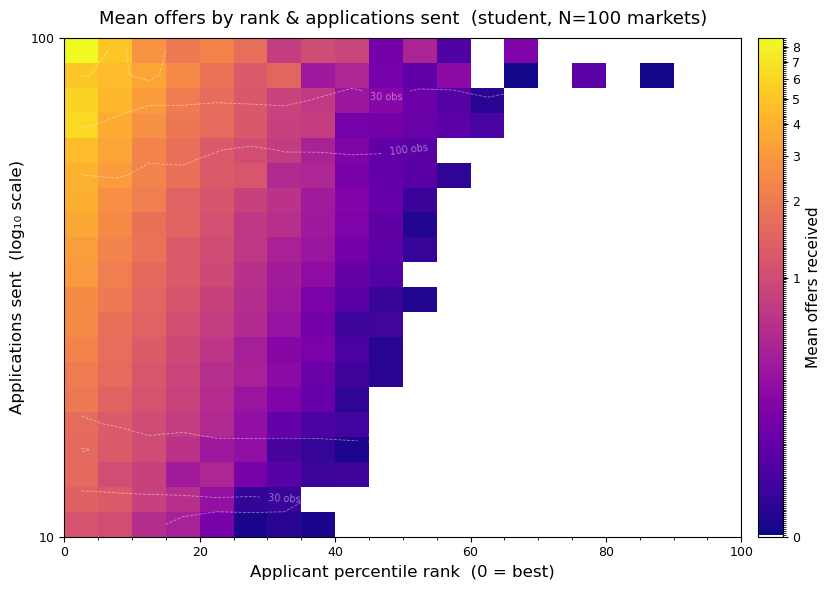

In [91]:
N_RUNS = 100   # ← tune this
stochasticity = 0.7
for atype in ["student"]:
    plot_heatmap_multi_run(
        cohort_kwargs=dict(
            n_students=1000,
            n_postdocs=300,
        ),
        n_runs=N_RUNS,
        offer_rounds=10,
        applicant_type=atype,
        ylim = (10,100),
        n_rank_bins=20,
        n_app_bins=20,
        log_y=True,
        cmap="plasma",
        min_count=3,
        stochasticity = stochasticity,
        save_path=f"heatmap_{atype}_N{N_RUNS}_stoch{stochasticity}.png",  # uncomment to save
    )

In [92]:
def applications_needed_table(
    percentiles:    np.ndarray,
    n_applications: np.ndarray,
    n_offers:       np.ndarray,
    delta_p:        float             = 10.0,
    target_probs:   Tuple             = (50, 75, 90, 95, 99),
    max_apps:       int               = 500,
    print_table:    bool              = True,
) -> dict:
    """
    For each percentile band, estimate the number of applications needed to
    achieve each target probability of receiving at least one offer.

    The empirical offer rate per application is estimated for each band, then
    inverted analytically:  P(≥1 offer) = 1 - (1 - p_offer)^n_apps  =>
        n_apps = log(1 - P_target) / log(1 - p_offer)

    Parameters
    ----------
    percentiles    : 1-D array, applicant percentile rank (0–100)
    n_applications : 1-D array, applications sent per applicant
    n_offers       : 1-D array, offers received per applicant
    delta_p        : width of each percentile band (default 10)
    target_probs   : target probabilities in percent, e.g. (50, 75, 90, 95, 99)
    max_apps       : cap on displayed values (shown as ">max_apps" if exceeded)
    print_table    : if True, print a markdown-formatted table to stdout

    Returns
    -------
    dict mapping band label -> {prob: n_apps_needed}
    """
    bands      = np.arange(0, 100, delta_p)
    results    = {}

    for band_start in bands:
        band_end = band_start + delta_p
        label    = f"{int(band_start)}–{int(band_end)}"

        mask = (percentiles >= band_start) & (percentiles < band_end)
        if mask.sum() == 0:
            results[label] = {p: None for p in target_probs}
            continue

        # Per-applicant offer rate: offers / applications sent
        rates      = n_offers[mask] / n_applications[mask]
        p_per_app  = float(np.mean(rates))   # mean offer-per-application rate

        row = {}
        for prob in target_probs:
            p_target = prob / 100.0
            if p_per_app <= 0:
                row[prob] = None
            elif p_per_app >= 1:
                row[prob] = 1
            else:
                n = np.log(1 - p_target) / np.log(1 - p_per_app)
                row[prob] = int(np.ceil(n))
        results[label] = row

    if print_table:
        _print_markdown_table(results, target_probs, delta_p, max_apps)

    return results


def _print_markdown_table(
    results:      dict,
    target_probs: Tuple,
    delta_p:      float,
    max_apps:     int,
):
    """Print results as a GitHub-flavoured markdown table."""
    prob_headers = [f"P={p}%" for p in target_probs]
    header       = "| Percentile band | " + " | ".join(prob_headers) + " |"
    separator    = "| --- | " + " | ".join(["---"] * len(target_probs)) + " |"

    print(f"\n### Applications needed for ≥1 offer  (band width = {int(delta_p)}%)\n")
    print(header)
    print(separator)

    for label, row in results.items():
        cells = []
        for p in target_probs:
            v = row[p]
            if v is None:
                cells.append("N/A")
            elif v > max_apps:
                cells.append(f">{max_apps}")
            else:
                cells.append(str(v))
        print(f"| {label} | " + " | ".join(cells) + " |")


def applications_needed_table_multi_run(
    cohort_kwargs:  dict              = None,
    n_runs:         int               = 10,
    offer_rounds:   int               = 10,
    applicant_type: str               = "both",
    delta_p:        float             = 10.0,
    target_probs:   Tuple             = (50, 75, 90, 95, 99),
    max_apps:       int               = 200,
    stochasticity:  float = 0.7,
) -> dict:
    """
    Run N markets, pool applicants, then print the applications-needed table.

    Parameters
    ----------
    cohort_kwargs  : forwarded to ApplicantCohort()
    n_runs         : number of independent markets
    offer_rounds   : rounds per market
    applicant_type : 'student', 'postdoc', or 'both'
    delta_p        : percentile band width (default 10)
    target_probs   : target success probabilities in percent
    max_apps       : cap shown in table for very large values
    """
    if cohort_kwargs is None:
        cohort_kwargs = {}

    print(f"Simulating {n_runs} markets  (applicant_type='{applicant_type}') …")
    pct, apps, offers = collect_multi_run(
        cohort_kwargs=cohort_kwargs,
        n_runs=n_runs,
        offer_rounds=offer_rounds,
        applicant_type=applicant_type,
        stochasticity = stochasticity
    )
    print(f"Pooled {len(pct):,} applicants across {n_runs} runs.")

    return applications_needed_table(
        percentiles=pct,
        n_applications=apps,
        n_offers=offers,
        delta_p=delta_p,
        target_probs=target_probs,
        max_apps=max_apps,
        print_table=True,
    )

In [94]:
N_RUNS = 10   # ← tune this

for atype in ["student"]:

    applications_needed_table_multi_run(
        cohort_kwargs=dict(
            n_students=1000,
            n_postdocs=300,
        ),
        n_runs=N_RUNS,
        offer_rounds=10,
        applicant_type=atype,
        delta_p=10,
        target_probs=(50, 75, 90, 95, 99),
    )

Simulating 10 markets  (applicant_type='student') …


Running markets: 100%|███████████████████████████████████████████████████████| 10/10 [00:50<00:00,  5.07s/it]

Pooled 7,500 applicants across 10 runs.

### Applications needed for ≥1 offer  (band width = 10%)

| Percentile band | P=50% | P=75% | P=90% | P=95% | P=99% |
| --- | --- | --- | --- | --- | --- |
| 0–10 | 9 | 18 | 29 | 38 | 58 |
| 10–20 | 16 | 32 | 52 | 68 | 104 |
| 20–30 | 28 | 55 | 90 | 117 | 180 |
| 30–40 | 51 | 102 | 170 | 221 | 339 |
| 40–50 | 127 | 254 | 421 | >500 | >500 |
| 50–60 | 244 | 487 | >500 | >500 | >500 |
| 60–70 | >500 | >500 | >500 | >500 | >500 |
| 70–80 | >500 | >500 | >500 | >500 | >500 |
| 80–90 | >500 | >500 | >500 | >500 | >500 |
| 90–100 | >500 | >500 | >500 | >500 | >500 |


In [98]:
"""
Postdoctoral Job Market — Applications-Needed Tables
=====================================================
Produces two markdown tables per run, both showing:
  rows    = target probability of getting ≥1 offer (e.g. 50%, 75%, …)
  columns = applicant percentile band (e.g. 0–10, 10–20, …)

Table 1 — EMPIRICAL (CDF-based)
  For each (band, target_prob) cell: the smallest number of applications
  such that the fraction of applicants in that band who sent ≥ that many
  applications AND received ≥1 offer reaches the target probability.
  Derived directly from the simulated CDF — no modelling assumptions.

Table 2 — ANALYTIC (kept for comparison)
  Uses the mean per-application offer rate in each band and inverts
  P(≥1) = 1 − (1 − p)^n analytically.

Usage
-----
    # from your_module import ApplicantCohort

    print_both_tables_multi_run(
        cohort_kwargs=dict(n_students=1000, n_postdocs=300),
        n_runs=10,
        applicant_type="student",
    )

Dependencies: numpy, tqdm (optional)
"""

import numpy as np
from typing import Optional, Tuple

try:
    from tqdm import trange
except ImportError:
    trange = None


# ─────────────────────────────────────────────────────────────────────────────
# Multi-run data collector  (shared with heatmap script if used together)
# ─────────────────────────────────────────────────────────────────────────────

def collect_multi_run(
    cohort_kwargs:  dict,
    n_runs:         int = 10,
    offer_rounds:   int = 10,
    applicant_type: str = "both",
    verbose_cohort: int = 0,
    stochasticity:  float = 0.7,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run N independent markets and return pooled flat arrays.

    Returns
    -------
    percentiles    : rank as percentile (0–100, 0 = best)
    n_applications : applications sent per applicant
    n_offers       : total offers received per applicant
    """
    all_pct, all_apps, all_off = [], [], []

    iterator = trange(n_runs, desc="Running markets") if trange else range(n_runs)

    for run_i in iterator:
        if trange is None:
            print(f"  Market {run_i + 1}/{n_runs} …", flush=True)

        kw = dict(cohort_kwargs)
        kw["verbose"] = verbose_cohort
        kw['stochasticity'] = stochasticity
        cohort = ApplicantCohort(**kw)
        cohort.run_market(offer_rounds=offer_rounds)

        applicants = cohort.applicants
        n_total    = len(applicants)

        if applicant_type == "student":
            applicants = [a for a in applicants if a["currently"] == "student"]
        elif applicant_type == "postdoc":
            applicants = [a for a in applicants if a["currently"] == "postdoc"]

        ranks    = np.array([a["rank"]                  for a in applicants])
        n_apps   = np.array([a["n_applications"]        for a in applicants], dtype=float)
        n_offers = np.array([a["total_offers_received"] for a in applicants], dtype=float)

        all_pct .append(ranks / n_total * 100)
        all_apps.append(n_apps)
        all_off .append(n_offers)

    return (
        np.concatenate(all_pct),
        np.concatenate(all_apps),
        np.concatenate(all_off),
    )


# ─────────────────────────────────────────────────────────────────────────────
# Shared helpers
# ─────────────────────────────────────────────────────────────────────────────

def _band_labels(delta_p: float) -> list:
    return [f"{int(s)}–{int(s + delta_p)}" for s in np.arange(0, 100, delta_p)]


def _fmt(v, max_apps: int) -> str:
    if v is None:
        return "N/A"
    if v > max_apps:
        return f">{max_apps}"
    return str(int(v))


def _print_table(
    title:        str,
    results:      dict,           # {band_label: {prob: value}}
    target_probs: Tuple,
    band_labels:  list,
    delta_p:      float,
    max_apps:     int,
):
    """
    Print a markdown table with rows = target probabilities, cols = bands.
    """
    print(f"\n### {title}  (band width = {int(delta_p)}%)\n")

    header    = "| Target prob | " + " | ".join(band_labels) + " |"
    separator = "| --- | " + " | ".join(["---"] * len(band_labels)) + " |"
    print(header)
    print(separator)

    for prob in target_probs:
        cells = [_fmt(results[lbl][prob], max_apps) for lbl in band_labels]
        print(f"| P={prob}% | " + " | ".join(cells) + " |")


# ─────────────────────────────────────────────────────────────────────────────
# Table 1 — Empirical CDF
# ─────────────────────────────────────────────────────────────────────────────

def empirical_applications_needed(
    percentiles:    np.ndarray,
    n_applications: np.ndarray,
    n_offers:       np.ndarray,
    delta_p:        float = 10.0,
    target_probs:   Tuple = (50, 75, 90, 95, 99),
    max_apps:       int   = 200,
    print_table:    bool  = True,
) -> dict:
    """
    For each percentile band, read the empirical CDF of
    P(≥1 offer | sent exactly k applications) directly from the simulation,
    and find the smallest k that clears each target probability.

    Method
    ------
    Within each band, group applicants by their application count.
    For each unique count k, compute the fraction who received ≥1 offer.
    Build the CDF by smoothing with a rolling window over sorted k values,
    then find the crossing point for each target.

    Returns
    -------
    dict  {band_label: {prob: n_apps_or_None}}
    """
    bands       = np.arange(0, 100, delta_p)
    lbls        = _band_labels(delta_p)
    results     = {}
    got_offer   = (n_offers >= 1).astype(float)

    for band_start, label in zip(bands, lbls):
        band_end = band_start + delta_p
        mask     = (percentiles >= band_start) & (percentiles < band_end)

        if mask.sum() == 0:
            results[label] = {p: None for p in target_probs}
            continue

        apps_band  = n_applications[mask].astype(int)
        got_band   = got_offer[mask]

        # Sort unique application counts and compute empirical success rate
        unique_k   = np.sort(np.unique(apps_band))

        # Cumulative: for each k, fraction of applicants with apps >= k
        # who got ≥1 offer.  This is the natural CDF reading:
        # "if I send k apps, what fraction of similar-rank people got an offer?"
        # We use a monotone-smoothed version: rolling mean over a window.
        success_at_k = np.array([
            got_band[apps_band == k].mean() for k in unique_k
        ])

        # Isotonic / monotone smoothing: CDF of P(offer) should be
        # non-decreasing in n_apps.  Enforce with PAVA (pool adjacent violators).
        smoothed = _isotonic_increasing(success_at_k)

        row = {}
        for prob in target_probs:
            threshold = prob / 100.0
            # First k where smoothed CDF >= threshold
            idx = np.searchsorted(smoothed, threshold)
            if idx >= len(unique_k):
                row[prob] = None          # never reached within the data
            else:
                row[prob] = int(unique_k[idx])
        results[label] = row

    if print_table:
        _print_table(
            "Applications needed for ≥1 offer — EMPIRICAL (CDF)",
            results, target_probs, lbls, delta_p, max_apps,
        )

    return results


def _isotonic_increasing(y: np.ndarray) -> np.ndarray:
    """Pool Adjacent Violators Algorithm — returns non-decreasing fit."""
    y = y.astype(float).copy()
    n = len(y)
    # Each element starts as its own block
    blocks = [[i, i, y[i]] for i in range(n)]   # [start, end, mean]

    i = 0
    while i < len(blocks) - 1:
        if blocks[i][2] > blocks[i + 1][2]:
            # Merge blocks i and i+1
            s, e  = blocks[i][0], blocks[i + 1][1]
            count = e - s + 1
            mean  = y[s:e + 1].mean()
            blocks[i] = [s, e, mean]
            blocks.pop(i + 1)
            if i > 0:
                i -= 1
        else:
            i += 1

    result = np.empty(n)
    for s, e, mean in blocks:
        result[s:e + 1] = mean
    return result


# ─────────────────────────────────────────────────────────────────────────────
# Table 2 — Analytic (kept for comparison)
# ─────────────────────────────────────────────────────────────────────────────

def analytic_applications_needed(
    percentiles:    np.ndarray,
    n_applications: np.ndarray,
    n_offers:       np.ndarray,
    delta_p:        float = 10.0,
    target_probs:   Tuple = (50, 75, 90, 95, 99),
    max_apps:       int   = 200,
    print_table:    bool  = True,
) -> dict:
    """
    For each percentile band, estimate the mean per-application offer rate
    and invert  P(≥1 offer) = 1 − (1 − p)^n  analytically.

    Returns
    -------
    dict  {band_label: {prob: n_apps_or_None}}
    """
    bands   = np.arange(0, 100, delta_p)
    lbls    = _band_labels(delta_p)
    results = {}

    for band_start, label in zip(bands, lbls):
        band_end = band_start + delta_p
        mask     = (percentiles >= band_start) & (percentiles < band_end)

        if mask.sum() == 0:
            results[label] = {p: None for p in target_probs}
            continue

        rates     = n_offers[mask] / n_applications[mask]
        p_per_app = float(np.mean(rates))

        row = {}
        for prob in target_probs:
            p_target = prob / 100.0
            if p_per_app <= 0:
                row[prob] = None
            elif p_per_app >= 1:
                row[prob] = 1
            else:
                n = np.log(1 - p_target) / np.log(1 - p_per_app)
                row[prob] = int(np.ceil(n))
        results[label] = row

    if print_table:
        _print_table(
            "Applications needed for ≥1 offer — ANALYTIC (comparison)",
            results, target_probs, lbls, delta_p, max_apps,
        )

    return results


# ─────────────────────────────────────────────────────────────────────────────
# Top-level convenience functions
# ─────────────────────────────────────────────────────────────────────────────

def print_both_tables_multi_run(
    cohort_kwargs:  dict  = None,
    n_runs:         int   = 10,
    offer_rounds:   int   = 10,
    applicant_type: str   = "both",
    delta_p:        float = 10.0,
    target_probs:   Tuple = (50, 75, 90, 95, 99),
    max_apps:       int   = 200,
    stochasticity:  float = 0.7,
) -> Tuple[dict, dict]:
    """
    Run N markets, pool applicants, print both tables.

    Returns (empirical_results, analytic_results).
    """
    if cohort_kwargs is None:
        cohort_kwargs = {}

    print(f"Simulating {n_runs} markets  (applicant_type='{applicant_type}') …")
    pct, apps, offers = collect_multi_run(
        cohort_kwargs=cohort_kwargs,
        n_runs=n_runs,
        offer_rounds=offer_rounds,
        applicant_type=applicant_type,
        stochasticity = stochasticity
    )
    print(f"Pooled {len(pct):,} applicants across {n_runs} runs.\n")

    emp = empirical_applications_needed(
        pct, apps, offers,
        delta_p=delta_p, target_probs=target_probs,
        max_apps=max_apps, print_table=True,
    )
    ana = analytic_applications_needed(
        pct, apps, offers,
        delta_p=delta_p, target_probs=target_probs,
        max_apps=max_apps, print_table=True,
    )
    return emp, ana

In [106]:
N_RUNS = 50   # ← tune this

for atype in ["student"]:
    print(f"\n{'='*60}")
    print(f"  Applicant type: {atype}")
    print(f"{'='*60}")
    print_both_tables_multi_run(
        cohort_kwargs=dict(n_students=1000, n_postdocs=300),
        n_runs=N_RUNS,
        offer_rounds=10,
        applicant_type=atype,
        delta_p=10,
        target_probs=(50, 75, 90, 95, 99),
        max_apps=200,
        stochasticity = 0.8
    )


  Applicant type: student
Simulating 50 markets  (applicant_type='student') …


Running markets: 100%|███████████████████████████████████████████████████████| 50/50 [03:54<00:00,  4.69s/it]

Pooled 37,500 applicants across 50 runs.


### Applications needed for ≥1 offer — EMPIRICAL (CDF)  (band width = 10%)

| Target prob | 0–10 | 10–20 | 20–30 | 30–40 | 40–50 | 50–60 | 60–70 | 70–80 | 80–90 | 90–100 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| P=50% | 8 | 8 | 16 | 70 | 103 | N/A | N/A | N/A | N/A | N/A |
| P=75% | 8 | 11 | 28 | N/A | 103 | N/A | N/A | N/A | N/A | N/A |
| P=90% | 8 | 13 | 65 | N/A | 103 | N/A | N/A | N/A | N/A | N/A |
| P=95% | 8 | 18 | 65 | N/A | 103 | N/A | N/A | N/A | N/A | N/A |
| P=99% | 14 | 26 | 82 | N/A | 103 | N/A | N/A | N/A | N/A | N/A |

### Applications needed for ≥1 offer — ANALYTIC (comparison)  (band width = 10%)

| Target prob | 0–10 | 10–20 | 20–30 | 30–40 | 40–50 | 50–60 | 60–70 | 70–80 | 80–90 | 90–100 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| P=50% | 6 | 12 | 22 | 72 | >200 | >200 | >200 | >200 | N/A | N/A |
| P=75% | 12 | 23 | 44 | 144 | >200 | >200 | >200 | >200 | N/A | N/A |
|

# Simulation distribution

In [30]:
def simulate_offer_distribution(phi, cohort_params, y_obs,
                                P=0.2, n_sim=10):

    offer_counts = []
    
    for _ in range(n_sim):

        Cohort = ApplicantCohort(
            stochasticity=phi,
            verbose=0,
            **cohort_params
        )
        
        Cohort.run_market()
        applicants = Cohort.applicants

        # -----------------------------------------
        # FILTER STUDENTS ONLY
        # -----------------------------------------
        students = [a for a in applicants if a["currently"] == "student"]

        # Sort students by rank (already globally ranked)
        students_sorted = sorted(students, key=lambda x: x["rank"])

        cutoff = int(P * len(students_sorted))

        if cutoff < len(y_obs):
            return None  # insufficient top students

        top_students = students_sorted[:cutoff]

        sampled = np.random.choice(
            top_students,
            size=cutoff,
            replace=False
        )

        offer_counts.extend(
            [a["total_offers_received"] for a in sampled]
        )

    max_k = max( [ max(offer_counts), max(y_obs) ] )
    # hist = np.bincount(offer_counts, minlength=max_k+1)
    # probs = hist / hist.sum()
    probs, bins_edges = np.histogram(offer_counts, bins = np.arange(max_k+1), density = 1)

    return probs, max_k

def log_likelihood(phi, y_obs, cohort_params,
                   P=0.2, n_sim=10):

    if phi <= 0 or phi >= 1:
        return -np.inf

    N_sample = len(y_obs)

    probs_model, max_k = simulate_offer_distribution(
        phi,
        cohort_params,
        y_obs,
        P=P,
        n_sim=n_sim
    )

    probs_obs, bins_edges = np.histogram(y_obs, bins = np.arange(max_k + 1), density = 1)

    eps = 1e-5
    probs_model = probs_model + eps
    probs_model /= probs_model.sum()

    logL = len(y_obs)*np.sum(probs_obs * np.log(probs_model))

    return logL, probs_obs, probs_model

def log_probability(theta, y_obs, cohort_params, P, n_sim):

    phi = theta[0]

    log_prior = -((phi - 0.7)**2/(2*0.15**2))
    if not (0 < phi < 1):
        return -np.inf

    logL, probs_obs, probs_model = log_likelihood(phi, y_obs, cohort_params, P=P, n_sim=n_sim) 
    return log_prior + logL, log_prior, logL, probs_obs, probs_model

In [32]:
y_obs = [10, 10, 7, 5, 4, 4, 3, 1, 1, 0, 0, 7, 0, 0, 3, 5, 0, 5, 1, 4, 9, 8, 10, 2,4, 5, 2, 3, 6, 8]

cohort_params = {'n_students': 1000}

simulate_offer_distribution(0.2, cohort_params, y_obs, P = 0.99, n_sim = 3)

(array([7.54716981e-01, 9.61365678e-02, 4.44743935e-02, 2.29110512e-02,
        1.79694519e-02, 1.57232704e-02, 9.88319856e-03, 4.04312668e-03,
        5.39083558e-03, 6.73854447e-03, 4.49236298e-03, 3.59389039e-03,
        2.24618149e-03, 4.49236298e-04, 2.69541779e-03, 2.24618149e-03,
        8.98472597e-04, 8.98472597e-04, 8.98472597e-04, 4.49236298e-04,
        0.00000000e+00, 4.49236298e-04, 4.49236298e-04, 8.98472597e-04,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        4.49236298e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.49236298e-04,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 4.49236298e-04]),
 50)

In [34]:
from tqdm import tqdm
y_obs = [10, 10, 7, 5, 4, 4, 3, 1, 1, 0, 0] #this year
# y_obs = [10, 10, 7, 5, 4, 4, 3, 1, 1, 0, 0, 7, 0, 0, 3, 5, 0, 5, 1, 4, 9, 8, 10, 2,4, 5, 2, 3, 6, 8]

P, n_sim = 0.3, 10
cohort_params = {'n_students': 1000}


log_posteriors = []
p_models = []
log_priors = []
phis = np.linspace(0.05, 0.95, 10)
for phi in tqdm(phis, total = len(phis)):
    log_posterior, log_prior, logL, p_obs, p_model = log_probability( [phi], y_obs, cohort_params, P, n_sim)
    log_posteriors.append(log_posterior)
    p_models.append(p_model)
    log_priors.append(log_prior)
    print(phi, log_posterior, log_prior)

 10%|███████▎                                                                 | 1/10 [00:42<06:25, 42.85s/it]

0.05 -93.01441370871325 -9.388888888888886


 20%|██████████████▌                                                          | 2/10 [01:26<05:45, 43.13s/it]

0.15 -90.65783491211818 -6.722222222222221


 30%|█████████████████████▉                                                   | 3/10 [02:09<05:01, 43.02s/it]

...

0.75 -94.22989961747464 -0.05555555555555566


 90%|█████████████████████████████████████████████████████████████████▋       | 9/10 [06:21<00:42, 42.37s/it]

0.85 -105.15886371801719 -0.5000000000000001


100%|████████████████████████████████████████████████████████████████████████| 10/10 [07:05<00:00, 42.53s/it]

0.95 -159.1555210710031 -1.3888888888888888


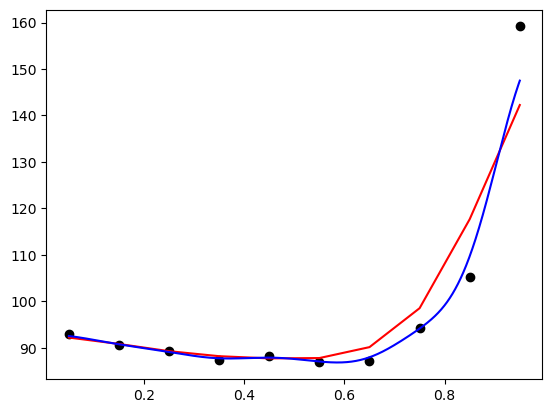

In [35]:
from scipy.interpolate import make_interp_spline, BSpline
from scipy.ndimage import gaussian_filter
phi_smooth = np.linspace(phis.min(), phis.max(), 1000)
spl = make_interp_spline(phis, -np.array(log_posteriors), k=2)
log_posterior_smooth = spl(phi_smooth)

plt.plot(phis, -np.array(log_posteriors), 'ko')
plt.plot(phis, gaussian_filter(-np.array(log_posteriors), 1, mode = 'nearest'), 'r-')
plt.plot(phi_smooth, gaussian_filter(log_posterior_smooth, 50, mode = 'nearest'), 'b-', alpha = 1)



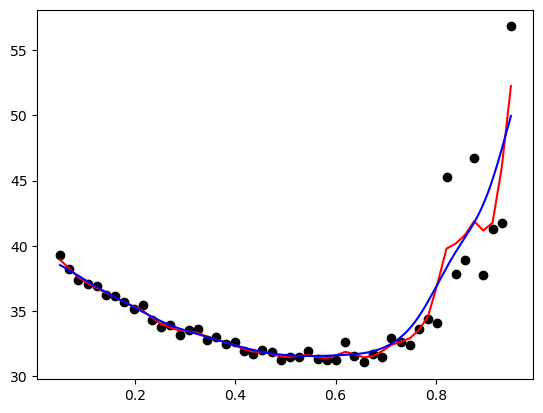

In [127]:
from scipy.interpolate import make_interp_spline, BSpline
from scipy.ndimage import gaussian_filter
phi_smooth = np.linspace(phis.min(), phis.max(), 1000)
spl = make_interp_spline(phis, -np.array(log_posteriors), k=2)
log_posterior_smooth = spl(phi_smooth)

plt.plot(phis, -np.array(log_posteriors), 'ko')
plt.plot(phis, gaussian_filter(-np.array(log_posteriors), 1, mode = 'nearest'), 'r-')
plt.plot(phi_smooth, gaussian_filter(log_posterior_smooth, 50, mode = 'nearest'), 'b-', alpha = 1)



MLE φ ≈ 0.6561
Approx. standard error ≈ 0.0732

--- Profile Likelihood Errors ---
MLE φ ≈ 0.58333
1σ: -0.17568 / +0.12072
2σ: -0.25225 / +0.17748


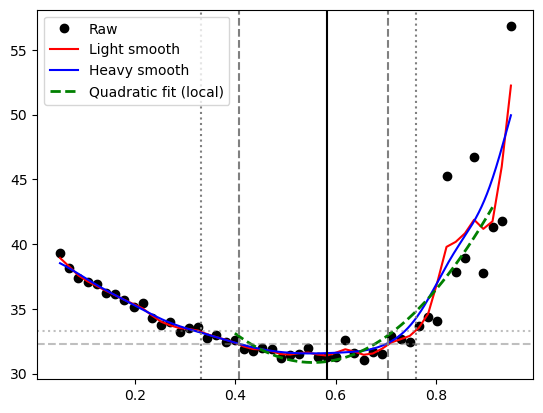

In [138]:
from scipy.interpolate import make_interp_spline
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt

neg_log_post = -np.array(log_posteriors)

phi_smooth = np.linspace(phis.min(), phis.max(), 1000)
spl = make_interp_spline(phis, neg_log_post, k=2)
log_posterior_smooth = spl(phi_smooth)

plt.plot(phis, neg_log_post, 'ko', label="Raw")
plt.plot(phis, gaussian_filter(neg_log_post, 1, mode='nearest'),
         'r-', label="Light smooth")
plt.plot(phi_smooth,
         gaussian_filter(log_posterior_smooth, 50, mode='nearest'),
         'b-', alpha=1, label="Heavy smooth")

# -------------------------------------------------------
# LOCAL QUADRATIC FIT AROUND PEAK
# -------------------------------------------------------

# Find minimum (since we plotted negative log posterior)
idx_min = np.argmin(neg_log_post)
phi_hat = phis[idx_min]

# Define window around the peak (adjust fraction if needed)
window_frac = 0.3
window = window_frac * (phis.max() - phis.min())

mask = np.abs(phis - phi_hat) < window

phis_local = phis[mask]
neg_log_local = neg_log_post[mask]

# Fit quadratic: a x^2 + b x + c
coeffs = np.polyfit(phis_local, neg_log_local, 2)
a, b, c = coeffs

# Evaluate quadratic fit
phi_quad = np.linspace(phis_local.min(), phis_local.max(), 400)
quad_fit = a * phi_quad**2 + b * phi_quad + c

plt.plot(phi_quad, quad_fit, 'g--', linewidth=2,
         label="Quadratic fit (local)")

# -------------------------------------------------------
# Estimate curvature-based standard error
# -------------------------------------------------------

# For quadratic approximation of log-likelihood:
# Var(phi_hat) ≈ 1 / (second derivative)
# second derivative of ax^2 + bx + c is 2a

curvature = 2 * a
if curvature > 0:
    se_phi = np.sqrt(1 / curvature)
    print(f"MLE φ ≈ {phi_hat:.4f}")
    print(f"Approx. standard error ≈ {se_phi:.4f}")
else:
    print("Warning: curvature not positive — fit may be unstable.")
    
# -------------------------------------------------------
# PROFILE LIKELIHOOD ERRORS (ASYMMETRIC)
# -------------------------------------------------------

# Use smoothed curve for stability
neg_log_smooth = gaussian_filter(log_posterior_smooth, 12)

min_val = np.min(neg_log_smooth)
phi_hat_smooth = phi_smooth[np.argmin(neg_log_smooth)]

delta = neg_log_smooth - min_val

# Helper function to find crossing
def find_crossing(phi_vals, delta_vals, target, side="left"):

    if side == "left":
        mask = phi_vals < phi_hat_smooth
    else:
        mask = phi_vals > phi_hat_smooth

    phi_side = phi_vals[mask]
    delta_side = delta_vals[mask]

    # find where delta crosses target
    idx = np.where(delta_side >= target)[0]

    if len(idx) == 0:
        return None

    i = idx[0] if side == "right" else idx[-1]

    return phi_side[i]


# 1-sigma (Δ = 1)
phi_left_1 = find_crossing(phi_smooth, delta, 1, "left")
phi_right_1 = find_crossing(phi_smooth, delta, 1, "right")

# 2-sigma (Δ = 2)
phi_left_2 = find_crossing(phi_smooth, delta, 2, "left")
phi_right_2 = find_crossing(phi_smooth, delta, 2, "right")

# Compute asymmetric errors
err_minus_1 = phi_hat_smooth - phi_left_1 if phi_left_1 else None
err_plus_1 = phi_right_1 - phi_hat_smooth if phi_right_1 else None

err_minus_2 = phi_hat_smooth - phi_left_2 if phi_left_2 else None
err_plus_2 = phi_right_2 - phi_hat_smooth if phi_right_2 else None

print("\n--- Profile Likelihood Errors ---")
print(f"MLE φ ≈ {phi_hat_smooth:.5f}")
print(f"1σ: -{err_minus_1:.5f} / +{err_plus_1:.5f}")
print(f"2σ: -{err_minus_2:.5f} / +{err_plus_2:.5f}")

plt.axhline(min_val + 1, color='gray', linestyle='--', alpha=0.5)
plt.axhline(min_val + 2, color='gray', linestyle=':', alpha=0.5)

plt.axvline(phi_hat_smooth, color='black', linestyle='-')

if phi_left_1:
    plt.axvline(phi_left_1, color='gray', linestyle='--')
if phi_right_1:
    plt.axvline(phi_right_1, color='gray', linestyle='--')

if phi_left_2:
    plt.axvline(phi_left_2, color='gray', linestyle=':')
if phi_right_2:
    plt.axvline(phi_right_2, color='gray', linestyle=':')

plt.legend()
plt.show()


(0.0, 20.0)

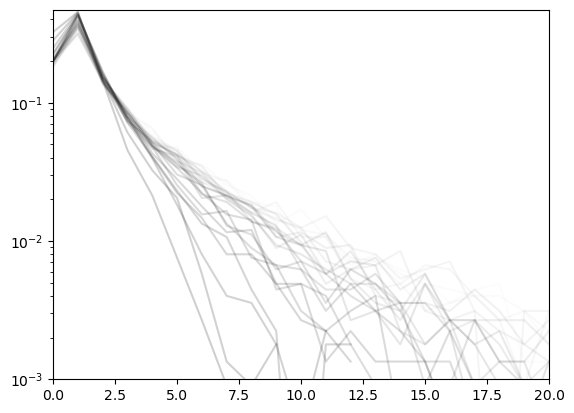

In [139]:
for p, phi in zip(p_models[::2], phis[::2]):
    plt.plot(np.array(p), color = (0, 0, 0, phi/5))
plt.yscale('log')    
plt.ylim(1e-3, 4.7e-1)
plt.xlim(0, 20)


In [101]:
p

array([1.91040874e-01, 3.25651004e-01, 1.39951220e-01, 8.30862149e-02,
       5.24324228e-02, 3.99932029e-02, 3.51063664e-02, 2.00015993e-02,
       2.08901150e-02, 8.89515292e-03, 2.22228886e-02, 9.78366864e-03,
       8.89515292e-03, 7.56237936e-03, 6.22960579e-03, 4.00831651e-03,
       4.45257436e-03, 4.89683222e-03, 1.34276937e-03, 2.23128508e-03,
       2.23128508e-03, 2.23128508e-03, 8.98511514e-04, 9.99580176e-06,
       4.54253658e-04, 8.98511514e-04, 4.54253658e-04, 1.34276937e-03,
       4.54253658e-04, 4.54253658e-04, 9.99580176e-06, 9.99580176e-06,
       4.54253658e-04, 9.99580176e-06, 9.99580176e-06, 4.54253658e-04,
       9.99580176e-06, 9.99580176e-06, 4.54253658e-04, 9.99580176e-06,
       9.99580176e-06, 4.54253658e-04])

In [102]:
p_models[len(p_models)//2]

array([0.19596297, 0.38525087, 0.14530846, 0.09065491, 0.05377487,
       0.0364457 , 0.02133821, 0.01467315, 0.01289579, 0.01245146,
       0.0071194 , 0.00578639, 0.00445338, 0.00178735, 0.00178735,
       0.00178735, 0.00178735, 0.00089867, 0.00134301, 0.00178735,
       0.00089867, 0.00089867, 0.00045434, 0.00045434])

In [90]:
phis

array([0.2       , 0.23684211, 0.27368421, 0.31052632, 0.34736842,
       0.38421053, 0.42105263, 0.45789474, 0.49473684, 0.53157895,
       0.56842105, 0.60526316, 0.64210526, 0.67894737, 0.71578947,
       0.75263158, 0.78947368, 0.82631579, 0.86315789, 0.9       ])

In [74]:
p_obs, p_model

(array([0.18181818, 0.18181818, 0.        , 0.09090909, 0.18181818,
        0.09090909, 0.        , 0.09090909, 0.        , 0.        ,
        0.18181818, 0.        , 0.        ]),
 array([2.22203336e-01, 4.10327028e-01, 1.70358224e-01, 8.44434668e-02,
        4.88925329e-02, 2.96357770e-02, 1.03790211e-02, 1.03790211e-02,
        7.41644327e-03, 1.49128761e-03, 1.49128761e-03, 9.99870017e-06,
        2.97257653e-03]))

In [66]:
# import emcee
# y_obs = [10, 10, 7, 5, 4, 4, 3, 1, 1, 0, 0]

# ndim = 1
# nwalkers = 20

# initial = 0.8 + 0.1*np.random.randn(nwalkers, ndim)

# P, n_sim = 0.3, 3

# cohort_params = {'n_students': 1000}

# sampler = emcee.EnsembleSampler(
#     nwalkers,
#     ndim,
#     log_probability,
#     args=[y_obs, cohort_params, P, n_sim]
# )

# sampler.run_mcmc(initial, 2000)

In [ ]:
applications = np.random.lognormal(mean = np.log(20), sigma = 0.4, size=int(1e3))
# applications[applications>100] = 100 # very rare with our settings but just to make sure
plt.hist(applications, bins = np.arange(max(applications)), histtype = 'step', log = 0);

In [ ]:
np.mean(applications)

In [ ]:
applicant_rank_students = np.random.normal(loc = 0, scale = 1, size = int(7e2)*100)
applicant_rank_postdocs = np.random.normal(loc = 1.2, scale = 0.8, size = int(1e2)*100)

plt.hist(applicant_rank_students, histtype = 'step', bins = 30, log = True);
plt.hist(applicant_rank_postdocs, histtype = 'step', bins = 30, log = True);


In [ ]:
import numpy as np


class ApplicantCohort:

    def __init__(
        self,
        n_students=1000,
        n_postdocs=300,
        splits=(6, 50, 200),
        frac_student_applying=0.75,
        frac_postdoc_applying=1/3,
        mean_applications=np.log(30),
        sigma_applications=0.4,
        tier_max_prestige=(15, 8, 3),
        prestige_decays=(1.0, 1.5, 1.2),
        minimum_prestiges=(5, 2, 0.5),
        loc_postdoc=1.15,
        scale_postdoc=0.8,
        loc_student=0,
        scale_student=1,
        self_awareness=0.4,
        stochasticity=0.9
    ):

        # --------------------
        # Population
        # --------------------
        self.n_students = n_students
        self.n_postdocs = n_postdocs

        self.n_student_applying = int(n_students * frac_student_applying)
        self.n_postdoc_applying = int(n_postdocs * frac_postdoc_applying)

        # --------------------
        # Skill distributions
        # --------------------
        student_skills = np.random.normal(loc_student, scale_student,
                                          self.n_student_applying)

        postdoc_skills = np.random.normal(loc_postdoc, scale_postdoc,
                                          self.n_postdoc_applying)

        skills = np.concatenate([student_skills, postdoc_skills])
        labels = np.array(
            ["student"] * self.n_student_applying +
            ["postdoc"] * self.n_postdoc_applying
        )

        order = np.argsort(-skills)
        self.skills = skills[order]
        self.labels = labels[order]

        self.N_applicants = len(self.skills)

        # --------------------
        # Applications per applicant
        # --------------------
        mean_postdoc = np.log(np.exp(mean_applications) / 2)

        self.n_applications = np.zeros(self.N_applicants, dtype=int)

        for i, lab in enumerate(self.labels):
            if lab == "student":
                k = np.random.lognormal(mean_applications, sigma_applications)
            else:
                k = np.random.lognormal(mean_postdoc, sigma_applications)

            self.n_applications[i] = int(max(1, k))

        # --------------------
        # Prestige structure
        # --------------------
        self.prestige = self._build_prestige(
            splits,
            tier_max_prestige,
            prestige_decays,
            minimum_prestiges
        )

        self.N_positions = len(self.prestige)

        # --------------------
        # Selectivity
        # --------------------
        self.self_awareness = np.clip(self_awareness, 0, 0.8)
        self.stochasticity = stochasticity

        # --------------------
        # State containers
        # --------------------
        self.application_lists = None
        self.pools = None
        self.rankings = None

        self.job_pointer = None
        self.applicant_match = np.full(self.N_applicants, -1)
        self.job_match = np.full(self.N_positions, -1)

    # =====================================================
    # Prestige construction
    # =====================================================

    def _build_prestige(self, splits, max_vals, decays, mins):

        prestige = []

        for n, max_p, decay, min_p in zip(splits, max_vals, decays, mins):

            ranks = np.arange(n)
            tier_vals = min_p + (max_p - min_p) * np.exp(-decay * ranks / n)
            prestige.extend(tier_vals)

        return np.array(prestige)

    # =====================================================
    # Application generation
    # =====================================================

    def generate_applications(self):

        self.application_lists = [[] for _ in range(self.N_applicants)]
        self.pools = [[] for _ in range(self.N_positions)]

        max_skill = np.max(np.abs(self.skills))

        for i in range(self.N_applicants):

            beta = 1 + self.self_awareness * self.skills[i] / max_skill

            logits = beta * self.prestige
            probs = np.exp(logits - np.max(logits))
            probs /= probs.sum()

            k = min(self.n_applications[i], self.N_positions)

            chosen = np.random.choice(
                self.N_positions,
                size=k,
                replace=False,
                p=probs
            )

            self.application_lists[i] = list(chosen)

            for j in chosen:
                self.pools[j].append(i)

    # =====================================================
    # Employer rankings (Mallows-style noise)
    # =====================================================

    def evaluate_pools(self):

        self.rankings = []

        for pool in self.pools:

            if len(pool) == 0:
                self.rankings.append([])
                continue

            pool_skills = self.skills[pool]

            noise = np.random.normal(
                scale=(1 - self.stochasticity),
                size=len(pool_skills)
            )

            score = pool_skills + noise
            ranked_indices = np.argsort(-score)

            ranked_applicants = [pool[i] for i in ranked_indices]
            self.rankings.append(ranked_applicants)

        self.job_pointer = np.zeros(self.N_positions, dtype=int)

    # =====================================================
    # Deferred acceptance
    # =====================================================

    def run_market(self, max_rounds=30):

        self.generate_applications()
        self.evaluate_pools()

        for _ in range(max_rounds):

            new_offers = []

            # Each open job proposes
            for j in range(self.N_positions):

                if self.job_match[j] != -1:
                    continue

                pointer = self.job_pointer[j]

                if pointer >= len(self.rankings[j]):
                    continue

                candidate = self.rankings[j][pointer]
                self.job_pointer[j] += 1

                new_offers.append((j, candidate))

            if len(new_offers) == 0:
                break

            # Applicants choose best offer
            offers_by_applicant = {}

            for j, i in new_offers:
                offers_by_applicant.setdefault(i, []).append(j)

            for i, jobs in offers_by_applicant.items():

                # applicant also considers existing match
                if self.applicant_match[i] != -1:
                    jobs.append(self.applicant_match[i])

                best_job = max(jobs, key=lambda x: self.prestige[x])

                # reject all others
                for j in jobs:
                    if j != best_job:
                        self.job_match[j] = -1

                self.applicant_match[i] = best_job
                self.job_match[best_job] = i

        return self.applicant_match, self.job_match


In [ ]:
Cohort = ApplicantCohort()
apps, jobs = Cohort.run_market()

In [114]:
import sys
import numpy as np


class ApplicantCohort:

    def __init__(
        self,
        n_students=1000,
        n_postdocs=300,
        splits=np.array([6, 50, 200]),
        frac_student_applying=3/4,
        frac_postdoc_applying=1/3,
        mean_applications=np.log(30),
        sigma_applications=0.4,
        tier_max_prestige=[10, 15, 3],
        prestige_decays=[1, 2, 1.2],
        minimum_prestiges=[5, 3, 1],
        loc_postdoc_reapplying=1.3,
        scale_postdoc_reapplying=0.8,
        loc_student=0,
        scale_student=1,
        self_awareness=0.5,
        stochasticity=0.7,
        verbose=1
    ):

        self.verbose = verbose

        self.n_students = n_students
        self.n_postdocs = n_postdocs

        self.frac_student_applying = frac_student_applying
        self.frac_postdoc_applying = frac_postdoc_applying

        self.n_student_applying = int(n_students * frac_student_applying)
        self.n_postdoc_reapplying = int(n_postdocs * frac_postdoc_applying)

        self.splits = np.array([int(s) for s in splits])
        self.n_positions = sum(self.splits)

        self.tier_max = np.array(tier_max_prestige)
        self.prestige_decay = prestige_decays
        self.minimum_prestiges = minimum_prestiges

        self.mean_applications = mean_applications
        self.sigma_applications = sigma_applications

        self.self_awareness = np.clip(self_awareness, 0, 0.5)
        self.stochasticity = stochasticity

        self.loc_postdoc_reapplying = loc_postdoc_reapplying
        self.scale_postdoc_reapplying = scale_postdoc_reapplying
        self.loc_student = loc_student
        self.scale_student = scale_student

        # Injected candidate state (set by inject_candidate)
        self._injected_id        = None
        self._injected_pct       = None
        self._injected_n_apps    = None

    ############################################################
    # 1️⃣ RANK APPLICANTS
    ############################################################

    def rank_applicants(self):

        skills_students = np.random.normal(
            self.loc_student,
            self.scale_student,
            self.n_student_applying
        )

        skills_postdocs = np.random.normal(
            self.loc_postdoc_reapplying,
            self.scale_postdoc_reapplying,
            self.n_postdoc_reapplying
        )

        labels = (
            ['student'] * self.n_student_applying +
            ['postdoc'] * self.n_postdoc_reapplying
        )

        all_skills = np.concatenate([skills_students, skills_postdocs])

        order = np.argsort(-all_skills)

        self.applicants = []

        for rank, idx in enumerate(order):

            applicant = {
                "rank": rank,
                "skill": all_skills[idx],
                "currently": labels[idx],
                "n_applications": 0,
                "offers": [],
                "offers_prestige": [],
                "offers_this_round": [],
                "offers_prestige_this_round": [],
                "total_offers_received": 0,
                "accepted": False,
                "accepted_job": None,
                "accepted_round": None,
                "injected": False,
                "_pending": 0,
            }

            self.applicants.append(applicant)

        self.applicants_on_the_market = list(range(len(self.applicants)))

    ############################################################
    # 💉 INJECT CANDIDATE
    ############################################################

    def inject_candidate(
        self,
        student_percentile: float,
        n_applications:     int,
    ):
        """
        Insert a test candidate into the cohort at a fixed rank and with a
        fixed number of applications, overriding the usual lognormal draw.

        Must be called AFTER rank_applicants() and BEFORE
        get_n_applications_per_applicant() / run_market().

        The candidate is placed at the desired percentile among the *students*
        currently in self.applicants.  Their skill is set to exactly match the
        skill of the natural applicant at that student-percentile position,
        ensuring they slot cleanly into the existing ordering.

        Parameters
        ----------
        student_percentile : float in [0, 100]
            Percentile rank among students only.  0 = best student,
            100 = worst student.
        n_applications : int
            Fixed number of applications the injected candidate will send.
        """
        if not hasattr(self, 'applicants'):
            raise RuntimeError(
                "Call rank_applicants() before inject_candidate()."
            )

        # ── find the skill value at the desired student percentile ────────────
        student_ids    = [i for i, a in enumerate(self.applicants)
                          if a["currently"] == "student"]
        student_skills = np.array([self.applicants[i]["skill"]
                                   for i in student_ids])

        # students are already sorted best-first in self.applicants, so
        # percentile 0 = highest skill, 100 = lowest skill
        target_skill = float(np.percentile(student_skills,
                                           100 - student_percentile))

        # ── build the injected applicant dict ─────────────────────────────────
        injected = {
            "rank":                      None,   # set after insertion
            "skill":                     target_skill,
            "currently":                 "student",
            "n_applications":            int(n_applications),
            "offers":                    [],
            "offers_prestige":           [],
            "offers_this_round":         [],
            "offers_prestige_this_round":[],
            "total_offers_received":     0,
            "accepted":                  False,
            "accepted_job":              None,
            "accepted_round":            None,
            "injected":                  True,
            "_pending":                  0,
        }

        # ── insert at the correct position in the sorted list ─────────────────
        insert_pos = 0
        for i, a in enumerate(self.applicants):
            if target_skill >= a["skill"]:
                insert_pos = i
                break
            insert_pos = i + 1

        self.applicants.insert(insert_pos, injected)

        # Re-assign ranks and rebuild applicants_on_the_market
        for rank, a in enumerate(self.applicants):
            a["rank"] = rank

        self.applicants_on_the_market = list(range(len(self.applicants)))

        # Record injected candidate's id and inputs for later reporting
        self._injected_id     = insert_pos
        self._injected_pct    = student_percentile
        self._injected_n_apps = n_applications

        if self.verbose >= 1:
            overall_pct = insert_pos / len(self.applicants) * 100
            print(f"\n[INJECTED CANDIDATE]")
            print(f"  Student percentile : {student_percentile:.1f}%")
            print(f"  Overall rank       : {insert_pos}/{len(self.applicants)}"
                  f"  ({overall_pct:.1f}% overall)")
            print(f"  Skill value        : {target_skill:.3f}")
            print(f"  Applications       : {n_applications}")

    ############################################################
    # 2️⃣ APPLICATION COUNTS
    ############################################################

    def get_n_applications_per_applicant(self):

        mean_postdoc = np.log(np.exp(self.mean_applications) / 2)

        for applicant in self.applicants:

            # Leave the injected candidate's n_applications untouched
            if applicant.get("injected"):
                continue

            if applicant["currently"] == "postdoc":
                n = np.random.lognormal(mean_postdoc, self.sigma_applications)
            else:
                n = np.random.lognormal(self.mean_applications, self.sigma_applications)

            applicant["n_applications"] = int(max(1, n))

        if self.verbose >= 1:

            students = [a for a in self.applicants if a["currently"] == "student"]
            postdocs = [a for a in self.applicants if a["currently"] == "postdoc"]

            print("\n--- APPLICATION STATISTICS ---")
            print(f"Students applying: {len(students)}")
            print(f"Postdocs applying: {len(postdocs)}")
            print(f"Mean applications (students): "
                  f"{np.mean([a['n_applications'] for a in students]):.2f}")
            print(f"Mean applications (postdocs): "
                  f"{np.mean([a['n_applications'] for a in postdocs]):.2f}")
            print(f"Total positions: {self.n_positions}")
            print("--------------------------------")

    ############################################################
    # 3️⃣ BUILD PRESTIGE
    ############################################################

    def build_prestige(self):

        prestige = []

        for i in range(len(self.splits)):

            n = self.splits[i]
            ranks = np.arange(n)

            values = (
                self.tier_max[i] *
                np.exp(-self.prestige_decay[i] / n * ranks)
                + self.minimum_prestiges[i]
            )

            prestige.extend(values)

        self.prestige = np.array(prestige) / 4

    ############################################################
    # 4️⃣ APPLICATION POOLS
    ############################################################

    def make_application_pools(self):

        N_positions = len(self.prestige)
        self.pools = [[] for _ in range(N_positions)]

        max_skill = max(abs(a["skill"]) for a in self.applicants)

        for i, applicant in enumerate(self.applicants):

            beta = 0.5 - self.self_awareness * applicant["skill"] / max_skill

            logits = beta * self.prestige
            probs = np.exp(logits - np.max(logits))
            probs /= probs.sum()

            k = min(applicant["n_applications"], N_positions)

            chosen = np.random.choice(
                N_positions,
                size=k,
                replace=False,
                p=probs
            )

            for pos in chosen:
                self.pools[pos].append(i)

        self.jobs_still_open = list(range(N_positions))
        self.job_offer_pointer = [0] * N_positions

    ############################################################
    # 5️⃣ EVALUATE APPLICATIONS
    ############################################################

    def evaluate_applications(self):

        sys.path.append('top-k-mallows')
        import mallows_kendall as mk

        self.pool_rankings = []

        for pool in self.pools:

            if len(pool) == 0:
                self.pool_rankings.append([[]])
                continue

            ranking = mk.sample(m=1, n=len(pool), phi=self.stochasticity)
            ordered = [pool[i] for i in ranking[0]]
            self.pool_rankings.append([ordered])

    ############################################################
    # 6️⃣ MAKE OFFERS
    ############################################################

    def make_applicant_offers(self):

        # Reset per-applicant pending counter at the start of each offer phase.
        # Using a field on the applicant (not a local dict) means every code
        # path — first call, second call, any future extension — sees the same
        # counter with no possibility of using a stale key.
        for a in self.applicants:
            a["_pending"] = 0

        for job in self.jobs_still_open.copy():

            pointer = self.job_offer_pointer[job]
            ranked_list = self.pool_rankings[job][0]

            # SECOND CALL
            if pointer >= len(ranked_list):

                remaining = self.applicants_on_the_market

                if len(remaining) == 0:
                    continue

                ranked_list = sorted(
                    remaining,
                    key=lambda x: self.applicants[x]["skill"],
                    reverse=True
                )

                self.pool_rankings[job] = [ranked_list]
                self.job_offer_pointer[job] = 0
                pointer = 0

                if self.verbose >= 2:
                    print(f"Job {job} triggers SECOND CALL")

            while pointer < len(ranked_list):

                applicant_id = ranked_list[pointer]
                pointer += 1
                self.job_offer_pointer[job] = pointer

                if applicant_id not in self.applicants_on_the_market:
                    continue

                applicant = self.applicants[applicant_id]

                # Hard cap: offers already counted in previous rounds
                # plus offers already made (but not yet accepted) this round
                if (applicant["total_offers_received"]
                        + applicant["_pending"]) >= applicant["n_applications"]:
                    continue

                applicant["offers_this_round"].append(job)
                applicant["offers_prestige_this_round"].append(self.prestige[job])
                applicant["offers"].append(job)
                applicant["offers_prestige"].append(self.prestige[job])
                applicant["_pending"] += 1

                if self.verbose >= 2:
                    print(f"Job {job} offers to Applicant {applicant_id} "
                          f"({applicant['currently']})")

                break

    ############################################################
    # 7️⃣ ACCEPT OFFERS
    ############################################################

    def accept_offer_round(self):

        accepted_this_round = []

        for applicant_id in self.applicants_on_the_market.copy():

            applicant = self.applicants[applicant_id]

            if len(applicant["offers_this_round"]) == 0:
                continue

            # Increment total_offers_received by however many offers arrived
            # this round (this is the only place it's updated)
            applicant["total_offers_received"] += len(applicant["offers_this_round"])

            perturb = np.abs(np.random.normal(1, 0.2))
            weighted = np.array(applicant["offers_prestige_this_round"]) * perturb

            chosen_index = np.argmax(weighted)
            chosen_job = applicant["offers_this_round"][chosen_index]

            applicant["accepted"] = True
            applicant["accepted_job"] = chosen_job
            applicant["accepted_round"] = self.round

            accepted_this_round.append(applicant_id)

            self.jobs_still_open.remove(chosen_job)

            if self.verbose >= 2:
                print(f"Applicant {applicant_id} ACCEPTS job {chosen_job} "
                      f"(sent {applicant['n_applications']} applications)")

        for a in accepted_this_round:
            self.applicants_on_the_market.remove(a)

        if self.verbose >= 1 and len(accepted_this_round) > 0:

            accepted = [self.applicants[a] for a in accepted_this_round]

            students = [a for a in accepted if a["currently"] == "student"]
            postdocs = [a for a in accepted if a["currently"] == "postdoc"]

            print(f"\nROUND {self.round} SUMMARY")
            print(f"Accepted this round: {len(accepted)}")
            print(f"Students: {len(students)}, Postdocs: {len(postdocs)}")
            print(f"Mean applications sent (accepted): "
                  f"{np.mean([a['n_applications'] for a in accepted]):.2f}")
            print(f"Mean offers received (accepted): "
                  f"{np.mean([a['total_offers_received'] for a in accepted]):.2f}")
            print(f"Jobs remaining open: {len(self.jobs_still_open)}")
            print("--------------------------------")

        for applicant in self.applicants:
            applicant["offers_this_round"] = []
            applicant["offers_prestige_this_round"] = []

    ############################################################
    # 8️⃣ RUN MARKET
    ############################################################

    def run_market(self, offer_rounds=10):

        if self.verbose >= 1:
            print("\n=========== STARTING MARKET ===========")

        self.rank_applicants()
        self.get_n_applications_per_applicant()
        self.build_prestige()
        self.make_application_pools()
        self.evaluate_applications()

        self.round = 1

        for _ in range(offer_rounds):

            if len(self.jobs_still_open) == 0:
                break

            if len(self.applicants_on_the_market) == 0:
                break

            if self.verbose >= 1:
                print(f"\n--- ROUND {self.round} ---")
                print(f"Open jobs: {len(self.jobs_still_open)}")
                print(f"Applicants on market: {len(self.applicants_on_the_market)}")

            self.make_applicant_offers()
            self.accept_offer_round()

            self.round += 1

        if self.verbose >= 1:

            filled = [a for a in self.applicants if a["accepted"]]
            n_filled = len(filled)

            students_filled = sum(a["currently"] == "student" for a in filled)
            postdocs_filled = sum(a["currently"] == "postdoc" for a in filled)

            max_positions_anyone_got = max(
                [a["total_offers_received"] for a in self.applicants]
            )

            print("\n=========== MARKET CLOSED ===========")
            print(f"Total filled: {n_filled}/{self.n_positions}")
            print(f"Students placed: {students_filled} "
                  f"({students_filled/self.n_student_applying*100:.1f}%)")
            print(f"Postdocs placed: {postdocs_filled}  "
                  f"({postdocs_filled/self.n_postdoc_reapplying*100:.1f}%)")
            print(f"Unfilled jobs: {len(self.jobs_still_open)}")
            print(f"Maximum offers received by any applicant: {max_positions_anyone_got}")
            print("======================================")

        # Print injected candidate summary if present
        if self._injected_id is not None:
            self.print_injected_stats()

    ############################################################
    # 📊 INJECTED CANDIDATE STATISTICS
    ############################################################

    def print_injected_stats(self):
        """Print a summary of the injected candidate's market outcomes."""

        if self._injected_id is None:
            print("No injected candidate in this cohort.")
            return

        a             = self.applicants[self._injected_id]
        got_offer     = a["total_offers_received"] > 0
        n_offers      = a["total_offers_received"]
        accepted      = a["accepted"]
        accepted_job  = a["accepted_job"]
        accepted_round= a["accepted_round"]
        overall_pct   = self._injected_id / len(self.applicants) * 100

        accepted_prestige = (
            float(self.prestige[accepted_job]) if accepted_job is not None else None
        )
        all_prestiges = a["offers_prestige"] if a["offers_prestige"] else []

        print("\n========== INJECTED CANDIDATE OUTCOME ==========")
        print(f"  Student percentile  : {self._injected_pct:.1f}%  "
              f"(overall: {overall_pct:.1f}%)")
        print(f"  Applications sent   : {self._injected_n_apps}")
        print(f"  Got ≥1 offer        : {'YES ✓' if got_offer else 'NO ✗'}")
        print(f"  Total offers        : {n_offers}")

        if all_prestiges:
            print(f"  Offer prestiges     : "
                  f"{[f'{p:.2f}' for p in all_prestiges]}")
        if accepted:
            print(f"  Accepted job #{accepted_job:<6}: "
                  f"prestige = {accepted_prestige:.2f}  "
                  f"(round {accepted_round})")
        else:
            print(f"  Accepted            : NO — did not place")
        print("=================================================")

    def get_injected_result(self) -> dict:
        """
        Return the injected candidate's outcomes as a plain dict,
        useful for aggregating across many runs.

        Keys
        ----
        got_offer       : bool
        n_offers        : int
        accepted        : bool
        accepted_round  : int or None
        accepted_prestige: float or None
        overall_percentile: float
        """
        if self._injected_id is None:
            return {}

        a = self.applicants[self._injected_id]
        accepted_job = a["accepted_job"]

        return {
            "got_offer":          a["total_offers_received"] > 0,
            "n_offers":           a["total_offers_received"],
            "accepted":           a["accepted"],
            "accepted_round":     a["accepted_round"],
            "accepted_prestige":  float(self.prestige[accepted_job])
                                  if accepted_job is not None else None,
            "overall_percentile": self._injected_id / len(self.applicants) * 100,
        }


# ─────────────────────────────────────────────────────────────────────────────
# Helper: run N markets with an injected candidate and aggregate results
# ─────────────────────────────────────────────────────────────────────────────

def run_injected_multi(
    student_percentile: float,
    n_applications:     int,
    n_runs:             int  = 100,
    offer_rounds:       int  = 10,
    cohort_kwargs:      dict = None,
    verbose_cohort:     int  = 0,
) -> dict:
    """
    Run N markets, each with an injected candidate at the given student
    percentile and application count, and return aggregated statistics.

    Parameters
    ----------
    student_percentile : float in [0, 100]  (0 = best student)
    n_applications     : int — fixed apps sent by the injected candidate
    n_runs             : number of independent markets
    offer_rounds       : offer rounds per market
    cohort_kwargs      : forwarded to ApplicantCohort()
    verbose_cohort     : verbosity for each cohort (default 0 = silent)

    Returns
    -------
    dict with keys:
        offer_rate        : fraction of runs where candidate got ≥1 offer
        acceptance_rate   : fraction of runs where candidate accepted a job
        mean_n_offers     : mean number of offers received
        mean_prestige     : mean prestige of accepted job (NaN if never placed)
        mean_round        : mean round of acceptance (NaN if never placed)
        n_runs            : total runs
    """
    if cohort_kwargs is None:
        cohort_kwargs = {}

    try:
        from tqdm import trange as _trange
        iterator = _trange(n_runs, desc=f"pct={student_percentile:.0f}% "
                                        f"apps={n_applications}")
    except ImportError:
        iterator = range(n_runs)

    results = []

    for run_i in iterator:
        kw = dict(cohort_kwargs)
        kw["verbose"] = verbose_cohort

        cohort = ApplicantCohort(**kw)
        cohort.rank_applicants()
        cohort.inject_candidate(student_percentile, n_applications)
        cohort.get_n_applications_per_applicant()
        cohort.build_prestige()
        cohort.make_application_pools()
        cohort.evaluate_applications()

        cohort.round = 1
        for _ in range(offer_rounds):
            if not cohort.jobs_still_open or not cohort.applicants_on_the_market:
                break
            cohort.make_applicant_offers()
            cohort.accept_offer_round()
            cohort.round += 1

        results.append(cohort.get_injected_result())

    offer_rate      = np.mean([r["got_offer"]   for r in results])
    acceptance_rate = np.mean([r["accepted"]    for r in results])
    mean_n_offers   = np.mean([r["n_offers"]    for r in results])

    placed_prestiges = [r["accepted_prestige"] for r in results
                        if r["accepted_prestige"] is not None]
    placed_rounds    = [r["accepted_round"]    for r in results
                        if r["accepted_round"]    is not None]

    mean_prestige = float(np.mean(placed_prestiges)) if placed_prestiges else float("nan")
    mean_round    = float(np.mean(placed_rounds))    if placed_rounds    else float("nan")

    summary = {
        "student_percentile": student_percentile,
        "n_applications":     n_applications,
        "offer_rate":         offer_rate,
        "acceptance_rate":    acceptance_rate,
        "mean_n_offers":      mean_n_offers,
        "mean_prestige":      mean_prestige,
        "mean_round":         mean_round,
        "n_runs":             n_runs,
    }

    print(f"\n{'='*50}")
    print(f"  student_percentile = {student_percentile:.1f}%  |  "
          f"n_applications = {n_applications}")
    print(f"  Got ≥1 offer       : {offer_rate*100:.1f}%  of runs")
    print(f"  Accepted a job     : {acceptance_rate*100:.1f}%  of runs")
    print(f"  Mean offers        : {mean_n_offers:.2f}")
    print(f"  Mean prestige      : {mean_prestige:.3f}")
    print(f"  Mean accept round  : {mean_round:.2f}")
    print(f"{'='*50}")

    return summary

In [115]:
# ── Single run with verbose output ────────────────────────────────────────
cohort = ApplicantCohort(verbose=1)
cohort.rank_applicants()
cohort.inject_candidate(student_percentile=2, n_applications=4)
cohort.run_market(offer_rounds=10)

# # ── Multi-run aggregation ─────────────────────────────────────────────────
# # Sweep over a grid of percentiles and application counts
# for pct in [10, 25, 50, 75]:
#     for n_apps in [10, 20, 40]:
#         run_injected_multi(
#             student_percentile=pct,
#             n_applications=n_apps,
#             n_runs=100,
#             cohort_kwargs=dict(n_students=1000, n_postdocs=300),
#         )


[INJECTED CANDIDATE]
  Student percentile : 2.0%
  Overall rank       : 28/851  (3.3% overall)
  Skill value        : 2.079
  Applications       : 4

=========== STARTING MARKET ===========

--- APPLICATION STATISTICS ---
Students applying: 750
Postdocs applying: 100
Mean applications (students): 31.69
Mean applications (postdocs): 15.55
Total positions: 256
--------------------------------

--- ROUND 1 ---
Open jobs: 256
Applicants on market: 850

ROUND 1 SUMMARY
Accepted this round: 87
Students: 54, Postdocs: 33
Mean applications sent (accepted): 27.85
Mean offers received (accepted): 2.94
Jobs remaining open: 169
--------------------------------

--- ROUND 2 ---
Open jobs: 169
Applicants on market: 763

ROUND 2 SUMMARY
Accepted this round: 68
Students: 44, Postdocs: 24
Mean applications sent (accepted): 25.32
Mean offers received (accepted): 2.49
Jobs remaining open: 101
--------------------------------

--- ROUND 3 ---
Open jobs: 101
Applicants on market: 695

ROUND 3 SUMMARY
Acce

In [146]:
"""
ApplicantCohort — postdoctoral job market simulation
=====================================================

Round structure
---------------
Each offer round consists of two phases:

  OFFER PHASE
    Every open job walks down its ranked pool and makes an offer to the first
    applicant it finds who is still on the market.  If the pool is exhausted,
    the job triggers a "second call": a fresh mini-pool is sampled from all
    remaining market participants (weighted by skill via softmax), each
    selected applicant's n_applications is incremented by 1, the mini-pool is
    ranked with a fresh Mallows draw, and the job continues from there.
    Second calls can repeat as many times as needed until the job fills or the
    market is empty.

  ACCEPT PHASE
    Every applicant who received at least one offer this round picks the best
    one (highest prestige * lognormal perturbation), accepts it, and leaves
    the market.  All remaining offers are implicitly declined.

Key design choices
------------------
- n_applications tracks how many pools an applicant entered (original + each
  second call they were drawn into).  It is NOT a cap on offers received.
- self.market is a Python set for O(1) membership test and removal.
- Jobs and applicants are stored as plain dicts — easy to inspect.
- Verbose levels:
    0  silent
    1  round-level summaries + market open/close
    2  every offer event + second-call triggers
    3  full debug: pool walks, skip reasons, second-call sampling details

Inject a test candidate
-----------------------
    cohort = ApplicantCohort(verbose=2)
    cohort.rank_applicants()
    cohort.inject_candidate(student_percentile=10, n_applications=15)
    cohort.run_market()
    result = cohort.get_injected_result()
"""

import sys
import numpy as np
from typing import Optional, List, Tuple


# =============================================================================
# Helpers
# =============================================================================

def _mallows_rank(pool: list, applicants: list, phi: float) -> list:
    """
    Return a Mallows-perturbed ranking of `pool` (list of applicant indices).
    The reference (modal) ranking is skill-descending order.
    phi=0 -> pure skill order, phi=1 -> uniform random.
    """
    sys.path.append("top-k-mallows")
    import mallows_kendall as mk

    if len(pool) == 0:
        return []
    if len(pool) == 1:
        return list(pool)

    # Reference = skill descending
    ref = sorted(pool, key=lambda i: applicants[i]["skill"], reverse=True)
    perm = mk.sample(m=1, n=len(ref), phi=phi)[0]
    return [ref[p] for p in perm]


def _softmax_sample(candidates: list, applicants: list,
                    n_draw: int, temperature: float) -> list:
    """
    Sample n_draw items from candidates without replacement,
    weighted by softmax(skill / temperature).
    """
    n_draw = min(n_draw, len(candidates))
    skills = np.array([applicants[i]["skill"] for i in candidates], dtype=float)
    logits = skills / temperature
    logits -= logits.max()
    probs = np.exp(logits)
    probs /= probs.sum()
    idx = np.random.choice(len(candidates), size=n_draw, replace=False, p=probs)
    return [candidates[i] for i in idx]


# =============================================================================
# ApplicantCohort
# =============================================================================

class ApplicantCohort:

    def __init__(
        self,
        n_students                = 1000,
        n_postdocs                = 300,
        splits                    = np.array([6, 50, 200]),
        frac_student_applying     = 3 / 4,
        frac_postdoc_applying     = 1 / 3,
        mean_applications         = np.log(30),
        sigma_applications        = 0.4,
        tier_max_prestige         = [10, 15, 3],
        prestige_decays           = [1, 2, 1.2],
        minimum_prestiges         = [5, 3, 1],
        loc_postdoc_reapplying    = 1.3,
        scale_postdoc_reapplying  = 0.8,
        loc_student               = 0,
        scale_student             = 1,
        self_awareness            = 0.5,
        stochasticity             = 0.7,
        second_call_loc           = 80,
        second_call_scale         = 15,
        second_call_min           = 40,
        second_call_temperature   = 1.0,
        verbose                   = 1,
    ):
        self.n_students               = n_students
        self.n_postdocs               = n_postdocs
        self.frac_student_applying    = frac_student_applying
        self.frac_postdoc_applying    = frac_postdoc_applying
        self.n_student_applying       = int(n_students * frac_student_applying)
        self.n_postdoc_reapplying     = int(n_postdocs * frac_postdoc_applying)
        self.splits                   = np.array([int(s) for s in splits])
        self.n_positions              = int(sum(self.splits))
        self.tier_max                 = np.array(tier_max_prestige)
        self.prestige_decays          = list(prestige_decays)
        self.minimum_prestiges        = list(minimum_prestiges)
        self.mean_applications        = mean_applications
        self.sigma_applications       = sigma_applications
        self.self_awareness           = float(np.clip(self_awareness, 0, 0.5))
        self.stochasticity            = stochasticity
        self.loc_postdoc_reapplying   = loc_postdoc_reapplying
        self.scale_postdoc_reapplying = scale_postdoc_reapplying
        self.loc_student              = loc_student
        self.scale_student            = scale_student
        self.second_call_loc          = second_call_loc
        self.second_call_scale        = second_call_scale
        self.second_call_min          = second_call_min
        self.second_call_temperature  = second_call_temperature
        self.verbose                  = verbose

        self._injected_idx = None   # set by inject_candidate()

        self.applicants = []        # list of dicts
        self.jobs       = []        # list of dicts
        self.market     = set()     # indices of applicants still on market

    # -------------------------------------------------------------------------
    # STEP 1 — rank applicants
    # -------------------------------------------------------------------------

    def rank_applicants(self):
        """Draw skills, merge students + postdocs, sort best-first."""

        skills_s = np.random.normal(
            self.loc_student, self.scale_student, self.n_student_applying)
        skills_p = np.random.normal(
            self.loc_postdoc_reapplying, self.scale_postdoc_reapplying,
            self.n_postdoc_reapplying)

        all_skills = np.concatenate([skills_s, skills_p])
        all_labels = (["student"] * self.n_student_applying
                      + ["postdoc"] * self.n_postdoc_reapplying)

        order = np.argsort(-all_skills)   # best first

        self.applicants = []
        for rank, orig in enumerate(order):
            self.applicants.append({
                "id":                rank,
                "rank":              rank,
                "skill":             float(all_skills[orig]),
                "currently":         all_labels[orig],
                "injected":          False,
                # application tracking
                "n_applications":    0,       # filled in assign_application_counts
                "pools_entered":     [],      # job ids (original + second call)
                # offer tracking (reset each round)
                "offers_this_round": [],      # list of (job_id, prestige)
                # full history
                "all_offers":        [],      # list of dicts
                # outcome
                "accepted":          False,
                "accepted_job":      None,
                "accepted_prestige": None,
                "accepted_round":    None,
            })

        self.market = set(range(len(self.applicants)))

        if self.verbose >= 1:
            n_s = sum(1 for a in self.applicants if a["currently"] == "student")
            n_p = sum(1 for a in self.applicants if a["currently"] == "postdoc")
            print(f"\n[rank_applicants]  {len(self.applicants)} applicants"
                  f"  ({n_s} students, {n_p} postdocs)")
            print(f"  skill range: [{self.applicants[-1]['skill']:.3f}, "
                  f"{self.applicants[0]['skill']:.3f}]")

    # -------------------------------------------------------------------------
    # INJECT CANDIDATE  (optional — between rank_applicants and run_market)
    # -------------------------------------------------------------------------

    def inject_candidate(self, student_percentile: float, n_applications: int):
        """
        Insert a test candidate at a fixed student-percentile with a fixed
        application count.  Call after rank_applicants(), before run_market().

        student_percentile : 0 = best student, 100 = worst student.
        """
        if not self.applicants:
            raise RuntimeError("Call rank_applicants() first.")

        student_skills = np.array([
            a["skill"] for a in self.applicants if a["currently"] == "student"
        ])
        target_skill = float(np.percentile(student_skills, 100 - student_percentile))

        candidate = {
            "id":                -1,
            "rank":              -1,
            "skill":             target_skill,
            "currently":         "student",
            "injected":          True,
            "n_applications":    int(n_applications),
            "pools_entered":     [],
            "offers_this_round": [],
            "all_offers":        [],
            "accepted":          False,
            "accepted_job":      None,
            "accepted_prestige": None,
            "accepted_round":    None,
        }

        # Insert keeping skill-descending order
        insert_pos = len(self.applicants)
        for i, a in enumerate(self.applicants):
            if target_skill >= a["skill"]:
                insert_pos = i
                break

        self.applicants.insert(insert_pos, candidate)

        # Re-index everything
        for i, a in enumerate(self.applicants):
            a["id"]   = i
            a["rank"] = i

        self.market = set(range(len(self.applicants)))
        self._injected_idx = insert_pos

        if self.verbose >= 1:
            n_total   = len(self.applicants)
            ovr_pct   = insert_pos / n_total * 100
            stu_list  = [a for a in self.applicants if a["currently"] == "student"]
            stu_rank  = sum(1 for a in self.applicants[:insert_pos]
                            if a["currently"] == "student")
            print(f"\n[inject_candidate]")
            print(f"  student_percentile : {student_percentile:.1f}%")
            print(f"  target_skill       : {target_skill:.4f}")
            print(f"  overall position   : {insert_pos} / {n_total}"
                  f"  ({ovr_pct:.1f}% overall)")
            print(f"  student rank       : {stu_rank} / {len(stu_list)}")
            print(f"  n_applications     : {n_applications}  (fixed)")

    # -------------------------------------------------------------------------
    # STEP 2 — assign application counts
    # -------------------------------------------------------------------------

    def assign_application_counts(self):
        """Lognormal draw for all non-injected applicants."""
        mean_postdoc = np.log(np.exp(self.mean_applications) / 2)

        for a in self.applicants:
            if a["injected"]:
                continue
            if a["currently"] == "postdoc":
                n = np.random.lognormal(mean_postdoc, self.sigma_applications)
            else:
                n = np.random.lognormal(self.mean_applications, self.sigma_applications)
            a["n_applications"] = max(1, int(n))

        if self.verbose >= 1:
            stu = [a for a in self.applicants if a["currently"] == "student"]
            pdc = [a for a in self.applicants if a["currently"] == "postdoc"]
            print(f"\n[assign_application_counts]")
            print(f"  students: n={len(stu)}, "
                  f"mean_apps={np.mean([a['n_applications'] for a in stu]):.2f}, "
                  f"max={max(a['n_applications'] for a in stu)}")
            print(f"  postdocs: n={len(pdc)}, "
                  f"mean_apps={np.mean([a['n_applications'] for a in pdc]):.2f}, "
                  f"max={max(a['n_applications'] for a in pdc)}")

    # -------------------------------------------------------------------------
    # STEP 3 — build prestige
    # -------------------------------------------------------------------------

    def build_prestige(self):
        """Exponential prestige decay within each tier."""
        prestige_vals = []
        for n, t_max, t_decay, t_min in zip(
            self.splits, self.tier_max,
            self.prestige_decays, self.minimum_prestiges
        ):
            ranks = np.arange(n)
            prestige_vals.extend(t_max * np.exp(-t_decay / n * ranks) + t_min)

        prestige_arr = np.array(prestige_vals) / 4

        self.jobs = []
        for j, p in enumerate(prestige_arr):
            self.jobs.append({
                "id":            j,
                "prestige":      float(p),
                "filled":        False,
                "pool":          [],   # current active ranked pool
                "pointer":       0,    # next position to offer from
                "second_call_n": 0,    # cumulative second calls for this job
            })

        if self.verbose >= 1:
            print(f"\n[build_prestige]  {len(self.jobs)} positions")
            print(f"  prestige range: [{prestige_arr.min():.3f}, "
                  f"{prestige_arr.max():.3f}]")
            for t_idx, (n, label) in enumerate(
                zip(self.splits, [f"tier {i}" for i in range(len(self.splits))])
            ):
                tier_pres = prestige_arr[sum(self.splits[:t_idx]):
                                         sum(self.splits[:t_idx]) + n]
                print(f"  {label}: {n} positions, "
                      f"prestige [{tier_pres.min():.2f}, {tier_pres.max():.2f}]")

    # -------------------------------------------------------------------------
    # STEP 4 — build application pools
    # -------------------------------------------------------------------------

    def build_application_pools(self):
        """
        Each applicant selects n_applications jobs (skill-aware softmax over
        prestige), enters those pools, then each pool is Mallows-ranked.
        """
        N = len(self.jobs)
        max_skill = max(abs(a["skill"]) for a in self.applicants)

        for a in self.applicants:
            beta   = 0.5 - self.self_awareness * a["skill"] / max_skill
            logits = beta * np.array([j["prestige"] for j in self.jobs])
            logits -= logits.max()
            probs  = np.exp(logits)
            probs /= probs.sum()

            k = min(a["n_applications"], N)
            chosen = np.random.choice(N, size=k, replace=False, p=probs)

            for job_id in chosen:
                self.jobs[job_id]["pool"].append(a["id"])
                a["pools_entered"].append(int(job_id))

        # Mallows-rank each pool
        for j in self.jobs:
            j["pool"]    = _mallows_rank(j["pool"], self.applicants,
                                         self.stochasticity)
            j["pointer"] = 0

        if self.verbose >= 1:
            pool_sizes = [len(j["pool"]) for j in self.jobs]
            print(f"\n[build_application_pools]")
            print(f"  pool sizes: min={min(pool_sizes)}, "
                  f"mean={np.mean(pool_sizes):.1f}, "
                  f"max={max(pool_sizes)}, "
                  f"empty={sum(1 for s in pool_sizes if s == 0)}")

        if self.verbose >= 3:
            for j in self.jobs:
                top = j["pool"][:3]
                skills = [f"{self.applicants[i]['skill']:.2f}" for i in top]
                print(f"  job {j['id']:3d} prestige={j['prestige']:.3f}: "
                      f"pool={len(j['pool'])}, top-3 skills={skills}")

    # -------------------------------------------------------------------------
    # SECOND CALL
    # -------------------------------------------------------------------------

    def _trigger_second_call(self, job: dict, round_num: int):
        """
        Build a fresh mini-pool from all remaining market participants,
        Mallows-rank it, and reset job pool/pointer.
        Each drawn applicant gets n_applications += 1.
        """
        remaining = list(self.market)
        if not remaining:
            if self.verbose >= 2:
                print(f"    [2nd-call] job {job['id']}: "
                      f"market empty — cannot trigger second call")
            return

        job["second_call_n"] += 1
        sc_n = job["second_call_n"]

        n_raw  = int(np.random.normal(self.second_call_loc, self.second_call_scale))
        n_draw = max(self.second_call_min, min(n_raw, len(remaining)))

        mini_pool = _softmax_sample(
            remaining, self.applicants, n_draw, self.second_call_temperature
        )

        for aid in mini_pool:
            self.applicants[aid]["n_applications"] += 1
            self.applicants[aid]["pools_entered"].append(job["id"])

        job["pool"]    = _mallows_rank(mini_pool, self.applicants, self.stochasticity)
        job["pointer"] = 0

        if self.verbose >= 2:
            injected_in_pool = any(
                self.applicants[i]["injected"] for i in mini_pool
            )
            print(f"    [2nd-call #{sc_n}] job {job['id']} "
                  f"(prestige={job['prestige']:.3f}): "
                  f"drew {n_draw} / {len(remaining)} remaining "
                  f"(raw={n_raw})"
                  f"{'  *** injected candidate in pool ***' if injected_in_pool else ''}")

        if self.verbose >= 3:
            top = job["pool"][:5]
            skills = [f"{self.applicants[i]['skill']:.2f}" for i in top]
            print(f"      mini-pool top-5 skills: {skills}")

    # -------------------------------------------------------------------------
    # OFFER PHASE
    # -------------------------------------------------------------------------

    def _offer_phase(self, round_num: int):
        """
        Each open job finds the first available applicant in its pool and
        makes one offer.  Triggers second calls inline when pool exhausted.
        """
        open_jobs = [j for j in self.jobs if not j["filled"]]

        if self.verbose >= 2:
            print(f"\n  [offer phase]  {len(open_jobs)} open jobs")

        for job in open_jobs:

            offer_made = False

            while not offer_made:

                # Walk the pool from current pointer
                pool_exhausted = True
                while job["pointer"] < len(job["pool"]):
                    aid = job["pool"][job["pointer"]]
                    job["pointer"] += 1

                    if aid not in self.market:
                        if self.verbose >= 3:
                            a = self.applicants[aid]
                            print(f"    job {job['id']}: skip {aid} "
                                  f"(skill={a['skill']:.3f}) — off market")
                        continue

                    # Offer
                    a = self.applicants[aid]
                    a["offers_this_round"].append((job["id"], job["prestige"]))
                    a["all_offers"].append({
                        "job_id":      job["id"],
                        "prestige":    job["prestige"],
                        "round":       round_num,
                        "second_call": job["second_call_n"] > 0,
                    })
                    offer_made    = True
                    pool_exhausted = False

                    if self.verbose >= 2:
                        sc_tag = (f" [2nd-call #{job['second_call_n']}]"
                                  if job["second_call_n"] > 0 else "")
                        inj_tag = "  *** INJECTED ***" if a["injected"] else ""
                        print(f"    job {job['id']}{sc_tag} "
                              f"prestige={job['prestige']:.3f}  ->  "
                              f"offer to {aid} "
                              f"skill={a['skill']:.3f} "
                              f"{a['currently']}{inj_tag}")
                    break

                if pool_exhausted:
                    if not self.market:
                        if self.verbose >= 2:
                            print(f"    job {job['id']}: pool exhausted + "
                                  f"market empty — stays open")
                        break
                    # Trigger a second call and loop back
                    self._trigger_second_call(job, round_num)

    # -------------------------------------------------------------------------
    # ACCEPT PHASE
    # -------------------------------------------------------------------------

    def _accept_phase(self, round_num: int) -> list:
        """
        Every applicant with >=1 offer picks the best one and accepts.
        Returns list of accepted applicant ids.
        """
        accepted_ids = []

        for aid in sorted(self.market):   # sorted for deterministic debug output
            a = self.applicants[aid]
            if not a["offers_this_round"]:
                continue

            n_off    = len(a["offers_this_round"])
            perturb  = np.abs(np.random.normal(1.0, 0.2, n_off))
            weighted = np.array([p for _, p in a["offers_this_round"]]) * perturb
            best_i   = int(np.argmax(weighted))
            best_job, best_pres = a["offers_this_round"][best_i]

            a["accepted"]          = True
            a["accepted_job"]      = best_job
            a["accepted_prestige"] = best_pres
            a["accepted_round"]    = round_num

            self.jobs[best_job]["filled"] = True
            accepted_ids.append(aid)

            if self.verbose >= 2:
                declined = [jid for jid, _ in a["offers_this_round"]
                            if jid != best_job]
                inj_tag  = "  *** INJECTED ***" if a["injected"] else ""
                print(f"    accept: {aid} skill={a['skill']:.3f} "
                      f"{a['currently']}{inj_tag}  "
                      f"->  job {best_job} prestige={best_pres:.3f}"
                      f"  ({n_off} offer(s)"
                      f"{', declined ' + str(declined) if declined else ''})")

        # Remove accepted applicants from market
        for aid in accepted_ids:
            self.market.discard(aid)

        # Clear round offers for everyone
        for a in self.applicants:
            a["offers_this_round"] = []

        if self.verbose >= 2:
            print(f"\n  [accept phase]  {len(accepted_ids)} accepted")

        return accepted_ids

    # -------------------------------------------------------------------------
    # ROUND SUMMARY
    # -------------------------------------------------------------------------

    def _print_round_summary(self, round_num: int, accepted_ids: list):
        if self.verbose < 1:
            return

        acc = [self.applicants[i] for i in accepted_ids]
        n_s = sum(1 for a in acc if a["currently"] == "student")
        n_p = sum(1 for a in acc if a["currently"] == "postdoc")
        sc  = sum(j["second_call_n"] for j in self.jobs)

        print(f"\n  -- Round {round_num} summary --")
        print(f"  accepted: {len(acc)}  (students={n_s}, postdocs={n_p})")
        print(f"  market remaining: {len(self.market)}")
        print(f"  open jobs: {sum(1 for j in self.jobs if not j['filled'])}")
        print(f"  total 2nd-calls so far: {sc}")
        if acc:
            mean_off = np.mean([len(a["all_offers"]) for a in acc])
            print(f"  mean cumulative offers (just-accepted): {mean_off:.2f}")

    # -------------------------------------------------------------------------
    # MARKET SUMMARY
    # -------------------------------------------------------------------------

    def _print_market_summary(self):
        if self.verbose < 1:
            return

        filled   = [a for a in self.applicants if a["accepted"]]
        n_s      = sum(1 for a in filled if a["currently"] == "student")
        n_p      = sum(1 for a in filled if a["currently"] == "postdoc")
        n_open   = sum(1 for j in self.jobs if not j["filled"])
        sc_total = sum(j["second_call_n"] for j in self.jobs)
        max_off  = max((len(a["all_offers"]) for a in self.applicants), default=0)

        print(f"\n{'=' * 60}")
        print(f"  MARKET CLOSED")
        print(f"{'=' * 60}")
        print(f"  Filled       : {len(filled)} / {self.n_positions}")
        print(f"  Students     : {n_s} / {self.n_student_applying}"
              f"  ({n_s / max(self.n_student_applying, 1) * 100:.1f}%)")
        print(f"  Postdocs     : {n_p} / {self.n_postdoc_reapplying}"
              f"  ({n_p / max(self.n_postdoc_reapplying, 1) * 100:.1f}%)")
        print(f"  Unfilled     : {n_open}")
        print(f"  2nd-calls    : {sc_total}")
        print(f"  Max offers   : {max_off}  (any single applicant)")
        print(f"{'=' * 60}")

    # -------------------------------------------------------------------------
    # RUN MARKET
    # -------------------------------------------------------------------------

    def run_market(self, offer_rounds: int = 10):
        """
        Full pipeline: assign counts -> build prestige -> build pools ->
        iterate offer rounds.  If inject_candidate() was called, prints
        injected candidate stats at the end.
        """
        if self.verbose >= 1:
            print(f"\n{'=' * 60}")
            print(f"  MARKET OPEN")
            print(f"{'=' * 60}")

        self.assign_application_counts()
        self.build_prestige()
        self.build_application_pools()

        for rnd in range(1, offer_rounds + 1):
            open_jobs = [j for j in self.jobs if not j["filled"]]
            if not open_jobs:
                if self.verbose >= 1:
                    print(f"\n  All jobs filled — stopping after round {rnd - 1}.")
                break
            if not self.market:
                if self.verbose >= 1:
                    print(f"\n  Market empty — stopping after round {rnd - 1}.")
                break

            if self.verbose >= 1:
                print(f"\n{'─' * 60}")
                print(f"  ROUND {rnd}  |  open={len(open_jobs)}  "
                      f"market={len(self.market)}")
                print(f"{'─' * 60}")

            self._offer_phase(rnd)
            accepted = self._accept_phase(rnd)
            if self.verbose>0:
                self._print_round_summary(rnd, accepted)
        if self.verbose>0:
            self._print_market_summary()

        if self._injected_idx is not None and self.verbose>0:
            self.print_injected_stats()

    # -------------------------------------------------------------------------
    # INJECTED CANDIDATE REPORTING
    # -------------------------------------------------------------------------

    def print_injected_stats(self):
        if self._injected_idx is None:
            print("No injected candidate.")
            return

        a         = self.applicants[self._injected_idx]
        n_total   = len(self.applicants)
        ovr_pct   = self._injected_idx / n_total * 100
        stu_list  = [x for x in self.applicants if x["currently"] == "student"]
        stu_rank  = sum(1 for x in self.applicants[:self._injected_idx]
                        if x["currently"] == "student")
        stu_pct   = stu_rank / max(len(stu_list), 1) * 100

        all_off  = a["all_offers"]
        n_sc_off = sum(1 for o in all_off if o["second_call"])
        n_orig   = a["n_applications"] - n_sc_off  # approximate original count

        print(f"\n{'=' * 55}")
        print(f"  INJECTED CANDIDATE OUTCOME")
        print(f"{'=' * 55}")
        print(f"  Student percentile : {stu_pct:.1f}%  "
              f"(rank {stu_rank} / {len(stu_list)})")
        print(f"  Overall percentile : {ovr_pct:.1f}%  "
              f"(rank {self._injected_idx} / {n_total})")
        print(f"  Skill              : {a['skill']:.4f}")
        print(f"  Final n_applications: {a['n_applications']}"
              f"  ({n_sc_off} added by 2nd-calls)")
        print(f"  Got >= 1 offer     : {'YES' if all_off else 'NO'}")
        print(f"  Total offers       : {len(all_off)}"
              f"  ({n_sc_off} from 2nd-call jobs)")

        if all_off:
            print(f"  Offers detail:")
            for o in all_off:
                sc = "  [2nd-call]" if o["second_call"] else ""
                print(f"    round {o['round']}: job {o['job_id']:3d}  "
                      f"prestige={o['prestige']:.3f}{sc}")

        if a["accepted"]:
            print(f"  Outcome: PLACED  "
                  f"job={a['accepted_job']}  "
                  f"prestige={a['accepted_prestige']:.3f}  "
                  f"round={a['accepted_round']}")
        else:
            print(f"  Outcome: NOT PLACED")
        print(f"{'=' * 55}")

    def get_injected_result(self) -> dict:
        """Injected candidate outcomes as a plain dict for aggregation."""
        if self._injected_idx is None:
            return {}
        a = self.applicants[self._injected_idx]
        return {
            "got_offer":            len(a["all_offers"]) > 0,
            "n_offers":             len(a["all_offers"]),
            "n_second_call_offers": sum(1 for o in a["all_offers"] if o["second_call"]),
            "accepted":             a["accepted"],
            "accepted_round":       a["accepted_round"],
            "accepted_prestige":    a["accepted_prestige"],
            "overall_percentile":   (self._injected_idx / len(self.applicants) * 100),
        }


# =============================================================================
# Multi-run helper
# =============================================================================

def run_injected_multi(
    student_percentile: float,
    n_applications:     int,
    n_runs:             int  = 100,
    offer_rounds:       int  = 10,
    cohort_kwargs:      dict = None,
    verbose_cohort:     int  = 0,
) -> dict:
    """Run N markets with an injected candidate; return aggregated stats."""
    if cohort_kwargs is None:
        cohort_kwargs = {}

    try:
        from tqdm.auto import trange as _tr
        iterator = _tr(n_runs, desc=f"pct={student_percentile:.0f}% "
                                    f"n_apps={n_applications}")
    except ImportError:
        iterator = range(n_runs)

    results = []
    for _ in iterator:
        cohort = ApplicantCohort(**{**cohort_kwargs, "verbose": verbose_cohort})
        cohort.rank_applicants()
        cohort.inject_candidate(student_percentile, n_applications)
        cohort.run_market(offer_rounds=offer_rounds)
        results.append(cohort.get_injected_result())

    offer_rate  = np.mean([r["got_offer"] for r in results])
    accept_rate = np.mean([r["accepted"]  for r in results])
    mean_off    = np.mean([r["n_offers"]  for r in results])
    placed      = [r for r in results if r["accepted_prestige"] is not None]
    mean_pres   = np.mean([r["accepted_prestige"] for r in placed]) if placed else float("nan")
    mean_rnd    = np.mean([r["accepted_round"]    for r in placed]) if placed else float("nan")
    
    summary = dict(
        student_percentile=student_percentile,
        n_applications=n_applications,
        offer_rate=offer_rate,
        acceptance_rate=accept_rate,
        mean_n_offers=mean_off,
        mean_prestige=mean_pres,
        mean_round=mean_rnd,
        n_runs=n_runs,
    )
    if verbose_cohort>0:
        print(f"\n{'=' * 50}")
        print(f"  pct={student_percentile:.0f}%  n_apps={n_applications}  "
              f"({n_runs} runs)")
        print(f"  Got >= 1 offer : {offer_rate * 100:.1f}%")
        print(f"  Accepted       : {accept_rate * 100:.1f}%")
        print(f"  Mean offers    : {mean_off:.2f}")
        print(f"  Mean prestige  : {mean_pres:.3f}")
        print(f"  Mean round     : {mean_rnd:.2f}")
        print(f"{'=' * 50}")
    return summary

In [147]:
cohort = ApplicantCohort(verbose=1, stochasticity = 0.7)
cohort.rank_applicants()
cohort.inject_candidate(student_percentile=30, n_applications=20)
cohort.run_market(offer_rounds=10)


[rank_applicants]  850 applicants  (750 students, 100 postdocs)
  skill range: [-2.951, 3.907]

[inject_candidate]
  student_percentile : 30.0%
  target_skill       : 0.4729
  overall position   : 309 / 851  (36.3% overall)
  student rank       : 225 / 751
  n_applications     : 20  (fixed)

  MARKET OPEN

[assign_application_counts]
  students: n=751, mean_apps=31.72, max=104
  postdocs: n=100, mean_apps=15.34, max=39

[build_prestige]  256 positions
  prestige range: [0.477, 4.500]
  tier 0: 6 positions, prestige [2.34, 3.75]
  tier 1: 50 positions, prestige [1.28, 4.50]
  tier 2: 200 positions, prestige [0.48, 1.00]

[build_application_pools]
  pool sizes: min=47, mean=99.0, max=380, empty=0

────────────────────────────────────────────────────────────
  ROUND 1  |  open=256  market=851
────────────────────────────────────────────────────────────

  -- Round 1 summary --
  accepted: 85  (students=57, postdocs=28)
  market remaining: 766
  open jobs: 171
  total 2nd-calls so far: 0


In [154]:
import numpy as np
from typing import List, Optional, Tuple

# =============================================================================
# Core sweep
# =============================================================================

def run_grid_sweep(
    percentiles:    List[float] = [10, 25, 50, 75],
    n_apps_grid:    List[int]   = [5, 10, 15, 20, 30, 40, 60, 80],
    n_runs:         int         = 200,
    offer_rounds:   int         = 10,
    cohort_kwargs:  dict        = None,
    verbose_sweep:  bool        = True,
) -> List[dict]:
    """
    For every (percentile, n_applications) pair, run n_runs markets with an
    injected candidate and record the empirical offer/acceptance rates.

    Parameters
    ----------
    percentiles   : list of student percentile values to test (0=best, 100=worst)
    n_apps_grid   : list of application counts to test per percentile
    n_runs        : markets per cell
    offer_rounds  : offer rounds per market
    cohort_kwargs : forwarded to ApplicantCohort() (do not include 'verbose')
    verbose_sweep : print progress between cells

    Returns
    -------
    List of dicts, one per (percentile, n_apps) cell:
        student_percentile, n_applications,
        offer_rate, acceptance_rate,
        mean_n_offers, mean_prestige, mean_round,
        n_runs
    """
    if cohort_kwargs is None:
        cohort_kwargs = {}

    total_cells = len(percentiles) * len(n_apps_grid)
    cell_i      = 0
    results     = []

    for pct in percentiles:
        for n_apps in n_apps_grid:
            cell_i += 1
            if verbose_sweep:
                print(f"\n[{cell_i}/{total_cells}]  "
                      f"percentile={pct:.0f}%  n_apps={n_apps}  "
                      f"({n_runs} runs each) ...")

            summary = run_injected_multi(
                student_percentile = pct,
                n_applications     = n_apps,
                n_runs             = n_runs,
                offer_rounds       = offer_rounds,
                cohort_kwargs      = cohort_kwargs,
                verbose_cohort     = 0,
            )
            results.append(summary)

    return results


# =============================================================================
# Table building
# =============================================================================

def _find_threshold_crossing(
    n_apps_grid: List[int],
    rates:       List[float],
    target:      float,
) -> Optional[int]:
    """
    Return the smallest n_apps where rate >= target, using monotone-smoothed
    (PAVA) rates to handle noise.  Returns None if never reached.
    """
    rates_arr = _isotonic_increasing(np.array(rates))
    for n, r in zip(n_apps_grid, rates_arr):
        if r >= target:
            return n
    return None


def _isotonic_increasing(y: np.ndarray) -> np.ndarray:
    """Pool Adjacent Violators — returns non-decreasing fit."""
    y = y.astype(float).copy()
    # Represent as blocks: [start_index, end_index, block_mean]
    blocks = [[i, i, y[i]] for i in range(len(y))]
    i = 0
    while i < len(blocks) - 1:
        if blocks[i][2] > blocks[i + 1][2]:
            s   = blocks[i][0]
            e   = blocks[i + 1][1]
            mn  = float(y[s:e + 1].mean())
            blocks[i] = [s, e, mn]
            blocks.pop(i + 1)
            if i > 0:
                i -= 1
        else:
            i += 1
    result = np.empty(len(y))
    for s, e, mn in blocks:
        result[s:e + 1] = mn
    return result


def build_threshold_table(
    results:        List[dict],
    percentiles:    List[float],
    n_apps_grid:    List[int],
    rate_key:       str   = "offer_rate",       # or "acceptance_rate"
    target_probs:   Tuple = (50, 75, 90, 95, 99),
    max_apps:       int   = 200,
) -> dict:
    """
    For each (percentile, target_prob) pair, find the minimum n_applications
    where the empirical rate (smoothed) crosses the target.

    Returns
    -------
    dict  {target_prob -> {percentile -> n_apps_or_None}}
    """
    # Index results by (percentile, n_apps) for fast lookup
    lookup = {
        (r["student_percentile"], r["n_applications"]): r
        for r in results
    }

    table = {}
    for prob in target_probs:
        table[prob] = {}
        target = prob / 100.0
        for pct in percentiles:
            rates = [
                lookup[(pct, n)][rate_key]
                for n in n_apps_grid
                if (pct, n) in lookup
            ]
            n_list = [
                n for n in n_apps_grid
                if (pct, n) in lookup
            ]
            crossing = _find_threshold_crossing(n_list, rates, target)
            table[prob][pct] = crossing

    return table


# =============================================================================
# Markdown printing
# =============================================================================

def _fmt_cell(v: Optional[int], max_apps: int) -> str:
    if v is None:
        return f">{max_apps}"
    return str(v)


def print_markdown_table(
    table:        dict,
    percentiles:  List[float],
    target_probs: Tuple,
    title:        str,
    delta_p:      float,
    max_apps:     int,
):
    """
    Print a markdown table.
    Rows = target probability, columns = student percentile.
    """
    # Column headers: percentile band labels
    col_headers = [f"{int(p)}–{int(p + delta_p)}%" for p in percentiles]

    header    = "| Target prob | " + " | ".join(col_headers) + " |"
    separator = "| --- | "        + " | ".join(["---"] * len(percentiles)) + " |"

    print(f"\n### {title}\n")
    print(header)
    print(separator)

    for prob in target_probs:
        cells = [
            _fmt_cell(table[prob].get(pct), max_apps)
            for pct in percentiles
        ]
        print(f"| P={prob}% | " + " | ".join(cells) + " |")


def print_tables(
    results:        List[dict],
    percentiles:    List[float]  = None,
    n_apps_grid:    List[int]    = None,
    target_probs:   Tuple        = (50, 75, 90, 95, 99),
    delta_p:        float        = 10.0,
    max_apps:       int          = 200,
):
    """
    Build and print both the offer-rate and acceptance-rate threshold tables.

    percentiles and n_apps_grid are inferred from results if not provided.
    """
    if percentiles is None:
        percentiles = sorted(set(r["student_percentile"] for r in results))
    if n_apps_grid is None:
        n_apps_grid = sorted(set(r["n_applications"] for r in results))

    for rate_key, label in [
        ("offer_rate",       "Applications for ≥1 offer  (empirical, injected candidate)"),
        ("acceptance_rate",  "Applications to accept a job  (empirical, injected candidate)"),
    ]:
        tbl = build_threshold_table(
            results      = results,
            percentiles  = percentiles,
            n_apps_grid  = n_apps_grid,
            rate_key     = rate_key,
            target_probs = target_probs,
            max_apps     = max_apps,
        )
        print_markdown_table(
            table        = tbl,
            percentiles  = percentiles,
            target_probs = target_probs,
            title        = label,
            delta_p      = delta_p,
            max_apps     = max_apps,
        )


# =============================================================================
# Optional: print raw rates for inspection
# =============================================================================

def print_raw_rates(
    results:     List[dict],
    percentiles: List[float] = None,
    n_apps_grid: List[int]   = None,
    rate_key:    str         = "offer_rate",
):
    """
    Print the raw empirical rates as a markdown table for inspection.
    Rows = n_applications, columns = student percentile.
    """
    if percentiles is None:
        percentiles = sorted(set(r["student_percentile"] for r in results))
    if n_apps_grid is None:
        n_apps_grid = sorted(set(r["n_applications"] for r in results))

    lookup = {
        (r["student_percentile"], r["n_applications"]): r
        for r in results
    }

    col_headers = [f"pct={int(p)}%" for p in percentiles]
    header    = "| n_apps | " + " | ".join(col_headers) + " |"
    separator = "| --- | "   + " | ".join(["---"] * len(percentiles)) + " |"

    label = "offer rate" if rate_key == "offer_rate" else "acceptance rate"
    print(f"\n### Raw {label} by (n_apps, percentile)\n")
    print(header)
    print(separator)

    for n in n_apps_grid:
        cells = []
        for pct in percentiles:
            r = lookup.get((pct, n))
            cells.append(f"{r[rate_key] * 100:.1f}%" if r else "—")
        print(f"| {n} | " + " | ".join(cells) + " |")



# ── Tunable parameters ────────────────────────────────────────────────────
PERCENTILES   = [5, 10, 15, 20, 25, 35]     # student percentile of injected candidate
N_APPS_GRID   = [2, 5, 10, 15, 20, 25, 30, 40, 60, 80, 100]   # application counts to test
N_RUNS        = 50                  # markets per cell (increase for less noise)
OFFER_ROUNDS  = 10
TARGET_PROBS  = (50, 75, 90, 95, 99)
DELTA_P       = 10.0                 # for column header labels only
MAX_APPS      = 200

COHORT_KWARGS = dict(
    n_students = 1000,
    n_postdocs = 300,
    stochasticity = 0.76
)

# ── Run ───────────────────────────────────────────────────────────────────
results = run_grid_sweep(
    percentiles   = PERCENTILES,
    n_apps_grid   = N_APPS_GRID,
    n_runs        = N_RUNS,
    offer_rounds  = OFFER_ROUNDS,
    cohort_kwargs = COHORT_KWARGS,
    verbose_sweep = 0
)

# ── Raw rates (useful for sanity-checking the sweep coverage) ─────────────
print_raw_rates(results, rate_key="offer_rate")
print_raw_rates(results, rate_key="acceptance_rate")

# ── Threshold tables ──────────────────────────────────────────────────────
print_tables(
    results      = results,
    percentiles  = PERCENTILES,
    n_apps_grid  = N_APPS_GRID,
    target_probs = TARGET_PROBS,
    delta_p      = DELTA_P,
    max_apps     = MAX_APPS,
)

pct=35% n_apps=100: 100%|████████████████████████████████████████████████████| 50/50 [03:48<00:00,  4.56s/it]


### Raw offer rate by (n_apps, percentile)

| n_apps | pct=5% | pct=10% | pct=15% | pct=20% | pct=25% | pct=35% |
| --- | --- | --- | --- | --- | --- | --- |
| 2 | 58.0% | 30.0% | 34.0% | 12.0% | 2.0% | 0.0% |
| 5 | 88.0% | 78.0% | 48.0% | 22.0% | 4.0% | 4.0% |
| 10 | 100.0% | 84.0% | 66.0% | 26.0% | 12.0% | 2.0% |
| 15 | 100.0% | 94.0% | 86.0% | 44.0% | 22.0% | 8.0% |
| 20 | 100.0% | 98.0% | 96.0% | 56.0% | 22.0% | 4.0% |
| 25 | 100.0% | 100.0% | 90.0% | 60.0% | 38.0% | 4.0% |
| 30 | 100.0% | 100.0% | 94.0% | 76.0% | 32.0% | 6.0% |
| 40 | 100.0% | 100.0% | 98.0% | 84.0% | 54.0% | 14.0% |
| 60 | 100.0% | 100.0% | 100.0% | 94.0% | 64.0% | 20.0% |
| 80 | 100.0% | 100.0% | 100.0% | 100.0% | 80.0% | 18.0% |
| 100 | 100.0% | 100.0% | 100.0% | 100.0% | 84.0% | 16.0% |

### Raw acceptance rate by (n_apps, percentile)

| n_apps | pct=5% | pct=10% | pct=15% | pct=20% | pct=25% | pct=35% |
| --- | --- | --- | --- | --- | --- | --- |
| 2 | 58.0% | 30.0% | 34.0% | 12.0% | 2.0% | 0.0% |
| 5 | 88.0

| Target prob | 5% | 10% | 15% | 20% | 25% | 35% |
| --- | --- | --- | --- | --- | --- | --- |
| P=50% | 2 | 5 | 10 | 20 | 40 | >200 |
| P=75% | 5 | 5 | 15 | 30 | 80 | >200 |
| P=90% | 10 | 15 | 20 | 60 | >200 | >200 |
| P=95% | 10 | 20 | 40 | 80 | >200 | >200 |
| P=99% | 10 | 25 | 60 | 80 | >200 | >200 |

In [161]:
"""
ApplicantCohort — postdoctoral job market simulation
=====================================================

Round structure
---------------
Each offer round consists of two phases:

  OFFER PHASE
    Every open job walks down its ranked pool and makes an offer to the first
    applicant it finds who is still on the market.  If the pool is exhausted,
    the job triggers a "second call": a fresh mini-pool is sampled from all
    remaining market participants (weighted by skill via softmax), each
    selected applicant's n_applications is incremented by 1, the mini-pool is
    ranked with a fresh Mallows draw, and the job continues from there.
    Second calls can repeat as many times as needed until the job fills or the
    market is empty.

  ACCEPT PHASE
    Every applicant who received at least one offer this round picks the best
    one (highest prestige * lognormal perturbation), accepts it, and leaves
    the market.  All remaining offers are implicitly declined.

Key design choices
------------------
- n_applications tracks how many pools an applicant entered (original + each
  second call they were drawn into).  It is NOT a cap on offers received.
- self.market is a Python set for O(1) membership test and removal.
- Jobs and applicants are stored as plain dicts — easy to inspect.
- Verbose levels:
    0  silent
    1  round-level summaries + market open/close
    2  every offer event + second-call triggers
    3  full debug: pool walks, skip reasons, second-call sampling details

Inject a test candidate
-----------------------
    cohort = ApplicantCohort(verbose=2)
    cohort.rank_applicants()
    cohort.inject_candidate(student_percentile=10, n_applications=15)
    cohort.run_market()
    result = cohort.get_injected_result()
"""

import sys
import numpy as np
from typing import Optional, List, Tuple


# =============================================================================
# Helpers
# =============================================================================

def _mallows_rank(pool: list, applicants: list, phi: float) -> list:
    """
    Return a Mallows-perturbed ranking of `pool` (list of applicant indices).
    The reference (modal) ranking is skill-descending order.
    phi=0 -> pure skill order, phi=1 -> uniform random.
    """
    sys.path.append("top-k-mallows")
    import mallows_kendall as mk

    if len(pool) == 0:
        return []
    if len(pool) == 1:
        return list(pool)

    # Reference = skill descending
    ref = sorted(pool, key=lambda i: applicants[i]["skill"], reverse=True)
    perm = mk.sample(m=1, n=len(ref), phi=phi)[0]
    return [ref[p] for p in perm]


def _softmax_sample(candidates: list, applicants: list,
                    n_draw: int, temperature: float) -> list:
    """
    Sample n_draw items from candidates without replacement,
    weighted by softmax(skill / temperature).
    """
    n_draw = min(n_draw, len(candidates))
    skills = np.array([applicants[i]["skill"] for i in candidates], dtype=float)
    logits = skills / temperature
    logits -= logits.max()
    probs = np.exp(logits)
    probs /= probs.sum()
    idx = np.random.choice(len(candidates), size=n_draw, replace=False, p=probs)
    return [candidates[i] for i in idx]


# =============================================================================
# ApplicantCohort
# =============================================================================

class ApplicantCohort:

    def __init__(
        self,
        n_students                = 1000,
        n_postdocs                = 300,
        splits                    = np.array([6, 50, 200]),
        frac_student_applying     = 3 / 4,
        frac_postdoc_applying     = 1 / 3,
        mean_applications         = np.log(30),
        sigma_applications        = 0.4,
        tier_max_prestige         = [10, 15, 3],
        prestige_decays           = [1, 2, 1.2],
        minimum_prestiges         = [5, 3, 1],
        loc_postdoc_reapplying    = 1.3,
        scale_postdoc_reapplying  = 0.8,
        loc_student               = 0,
        scale_student             = 1,
        self_awareness            = 0.5,
        stochasticity             = 0.7,
        second_call_loc           = 80,
        second_call_scale         = 15,
        second_call_min           = 40,
        second_call_temperature   = 1.0,
        verbose                   = 1,
    ):
        self.n_students               = n_students
        self.n_postdocs               = n_postdocs
        self.frac_student_applying    = frac_student_applying
        self.frac_postdoc_applying    = frac_postdoc_applying
        self.n_student_applying       = int(n_students * frac_student_applying)
        self.n_postdoc_reapplying     = int(n_postdocs * frac_postdoc_applying)
        self.splits                   = np.array([int(s) for s in splits])
        self.n_positions              = int(sum(self.splits))
        self.tier_max                 = np.array(tier_max_prestige)
        self.prestige_decays          = list(prestige_decays)
        self.minimum_prestiges        = list(minimum_prestiges)
        self.mean_applications        = mean_applications
        self.sigma_applications       = sigma_applications
        self.self_awareness           = float(np.clip(self_awareness, 0, 0.5))
        self.stochasticity            = stochasticity
        self.loc_postdoc_reapplying   = loc_postdoc_reapplying
        self.scale_postdoc_reapplying = scale_postdoc_reapplying
        self.loc_student              = loc_student
        self.scale_student            = scale_student
        self.second_call_loc          = second_call_loc
        self.second_call_scale        = second_call_scale
        self.second_call_min          = second_call_min
        self.second_call_temperature  = second_call_temperature
        self.verbose                  = verbose

        self._injected_idx   = None   # set by inject_candidate()
        self._injected_batch = []     # set by inject_candidates_batch(): list of
                                      # {"idx": int, "student_percentile": float,
                                      #  "n_applications": int}

        self.applicants = []        # list of dicts
        self.jobs       = []        # list of dicts
        self.market     = set()     # indices of applicants still on market

    # -------------------------------------------------------------------------
    # STEP 1 — rank applicants
    # -------------------------------------------------------------------------

    def rank_applicants(self):
        """Draw skills, merge students + postdocs, sort best-first."""

        skills_s = np.random.normal(
            self.loc_student, self.scale_student, self.n_student_applying)
        skills_p = np.random.normal(
            self.loc_postdoc_reapplying, self.scale_postdoc_reapplying,
            self.n_postdoc_reapplying)

        all_skills = np.concatenate([skills_s, skills_p])
        all_labels = (["student"] * self.n_student_applying
                      + ["postdoc"] * self.n_postdoc_reapplying)

        order = np.argsort(-all_skills)   # best first

        self.applicants = []
        for rank, orig in enumerate(order):
            self.applicants.append({
                "id":                rank,
                "rank":              rank,
                "skill":             float(all_skills[orig]),
                "currently":         all_labels[orig],
                "injected":          False,
                # application tracking
                "n_applications":    0,       # filled in assign_application_counts
                "pools_entered":     [],      # job ids (original + second call)
                # offer tracking (reset each round)
                "offers_this_round": [],      # list of (job_id, prestige)
                # full history
                "all_offers":        [],      # list of dicts
                # outcome
                "accepted":          False,
                "accepted_job":      None,
                "accepted_prestige": None,
                "accepted_round":    None,
            })

        self.market = set(range(len(self.applicants)))

        if self.verbose >= 1:
            n_s = sum(1 for a in self.applicants if a["currently"] == "student")
            n_p = sum(1 for a in self.applicants if a["currently"] == "postdoc")
            print(f"\n[rank_applicants]  {len(self.applicants)} applicants"
                  f"  ({n_s} students, {n_p} postdocs)")
            print(f"  skill range: [{self.applicants[-1]['skill']:.3f}, "
                  f"{self.applicants[0]['skill']:.3f}]")

    # -------------------------------------------------------------------------
    # INJECT CANDIDATE  (optional — between rank_applicants and run_market)
    # -------------------------------------------------------------------------

    def inject_candidate(self, student_percentile: float, n_applications: int):
        """
        Insert a test candidate at a fixed student-percentile with a fixed
        application count.  Call after rank_applicants(), before run_market().

        student_percentile : 0 = best student, 100 = worst student.
        """
        if not self.applicants:
            raise RuntimeError("Call rank_applicants() first.")

        student_skills = np.array([
            a["skill"] for a in self.applicants if a["currently"] == "student"
        ])
        target_skill = float(np.percentile(student_skills, 100 - student_percentile))

        candidate = {
            "id":                -1,
            "rank":              -1,
            "skill":             target_skill,
            "currently":         "student",
            "injected":          True,
            "n_applications":    int(n_applications),
            "pools_entered":     [],
            "offers_this_round": [],
            "all_offers":        [],
            "accepted":          False,
            "accepted_job":      None,
            "accepted_prestige": None,
            "accepted_round":    None,
        }

        # Insert keeping skill-descending order
        insert_pos = len(self.applicants)
        for i, a in enumerate(self.applicants):
            if target_skill >= a["skill"]:
                insert_pos = i
                break

        self.applicants.insert(insert_pos, candidate)

        # Re-index everything
        for i, a in enumerate(self.applicants):
            a["id"]   = i
            a["rank"] = i

        self.market = set(range(len(self.applicants)))
        self._injected_idx = insert_pos

        if self.verbose >= 1:
            n_total   = len(self.applicants)
            ovr_pct   = insert_pos / n_total * 100
            stu_list  = [a for a in self.applicants if a["currently"] == "student"]
            stu_rank  = sum(1 for a in self.applicants[:insert_pos]
                            if a["currently"] == "student")
            print(f"\n[inject_candidate]")
            print(f"  student_percentile : {student_percentile:.1f}%")
            print(f"  target_skill       : {target_skill:.4f}")
            print(f"  overall position   : {insert_pos} / {n_total}"
                  f"  ({ovr_pct:.1f}% overall)")
            print(f"  student rank       : {stu_rank} / {len(stu_list)}")
            print(f"  n_applications     : {n_applications}  (fixed)")

    # -------------------------------------------------------------------------
    # INJECT CANDIDATES — BATCH  (for grid sweeps)
    # -------------------------------------------------------------------------

    def inject_candidates_batch(
        self,
        param_list: list,
    ):
        """
        Inject multiple test candidates in one call.  Each candidate is
        independent: they enter their own pools, receive their own offers,
        and are tracked separately.

        Must be called after rank_applicants(), before run_market().
        Cannot be combined with inject_candidate().

        Parameters
        ----------
        param_list : list of (student_percentile, n_applications) tuples
            e.g. [(10, 15), (25, 20), (50, 30)]

        After the call, self._injected_batch is populated with one entry
        per candidate:
            {"idx": int, "student_percentile": float, "n_applications": int}
        """
        if not self.applicants:
            raise RuntimeError("Call rank_applicants() first.")
        if self._injected_idx is not None:
            raise RuntimeError("Cannot mix inject_candidate and inject_candidates_batch.")

        # Pre-compute student skill distribution once
        student_skills = np.array([
            a["skill"] for a in self.applicants if a["currently"] == "student"
        ])

        # Build candidate dicts with target skills
        candidates_to_insert = []
        for pct, n_apps in param_list:
            target_skill = float(np.percentile(student_skills, 100 - pct))
            candidates_to_insert.append({
                "id":                -1,
                "rank":              -1,
                "skill":             target_skill,
                "currently":         "student",
                "injected":          True,
                "injected_pct":      float(pct),
                "injected_n_apps":   int(n_apps),
                "n_applications":    int(n_apps),
                "pools_entered":     [],
                "offers_this_round": [],
                "all_offers":        [],
                "accepted":          False,
                "accepted_job":      None,
                "accepted_prestige": None,
                "accepted_round":    None,
            })

        # Insert all candidates maintaining skill-descending order.
        # We insert highest-skill first so earlier insertions don't shift
        # the intended positions of later ones.
        for cand in sorted(candidates_to_insert,
                           key=lambda c: c["skill"], reverse=True):
            insert_pos = len(self.applicants)
            for i, a in enumerate(self.applicants):
                if cand["skill"] >= a["skill"]:
                    insert_pos = i
                    break
            self.applicants.insert(insert_pos, cand)

        # Re-index all applicants
        for i, a in enumerate(self.applicants):
            a["id"]   = i
            a["rank"] = i

        self.market = set(range(len(self.applicants)))

        # Record final indices for tracking
        self._injected_batch = [
            {
                "idx":                a["id"],
                "student_percentile": a["injected_pct"],
                "n_applications":     a["injected_n_apps"],
            }
            for a in self.applicants if a.get("injected")
        ]

        if self.verbose >= 1:
            print(f"\n[inject_candidates_batch]  {len(self._injected_batch)} candidates injected")
        if self.verbose >= 2:
            for entry in self._injected_batch:
                a       = self.applicants[entry["idx"]]
                ovr_pct = entry["idx"] / len(self.applicants) * 100
                print(f"  pct={entry['student_percentile']:.0f}%  "
                      f"n_apps={entry['n_applications']}  "
                      f"skill={a['skill']:.3f}  "
                      f"overall_pos={entry['idx']} ({ovr_pct:.1f}%)")

    def get_all_injected_results(self) -> list:
        """
        Return a list of result dicts, one per injected candidate.
        Each dict includes the original (student_percentile, n_applications)
        parameters so results can be grouped by cell.
        """
        out = []
        for entry in self._injected_batch:
            a = self.applicants[entry["idx"]]
            out.append({
                "student_percentile":   entry["student_percentile"],
                "n_applications":       entry["n_applications"],
                "got_offer":            len(a["all_offers"]) > 0,
                "n_offers":             len(a["all_offers"]),
                "n_second_call_offers": sum(1 for o in a["all_offers"]
                                            if o["second_call"]),
                "accepted":             a["accepted"],
                "accepted_round":       a["accepted_round"],
                "accepted_prestige":    a["accepted_prestige"],
                "overall_percentile":   entry["idx"] / len(self.applicants) * 100,
            })
        return out



    def assign_application_counts(self):
        """Lognormal draw for all non-injected applicants."""
        mean_postdoc = np.log(np.exp(self.mean_applications) / 2)

        for a in self.applicants:
            if a["injected"]:
                continue
            if a["currently"] == "postdoc":
                n = np.random.lognormal(mean_postdoc, self.sigma_applications)
            else:
                n = np.random.lognormal(self.mean_applications, self.sigma_applications)
            a["n_applications"] = max(1, int(n))

        if self.verbose >= 1:
            stu = [a for a in self.applicants if a["currently"] == "student"]
            pdc = [a for a in self.applicants if a["currently"] == "postdoc"]
            print(f"\n[assign_application_counts]")
            print(f"  students: n={len(stu)}, "
                  f"mean_apps={np.mean([a['n_applications'] for a in stu]):.2f}, "
                  f"max={max(a['n_applications'] for a in stu)}")
            print(f"  postdocs: n={len(pdc)}, "
                  f"mean_apps={np.mean([a['n_applications'] for a in pdc]):.2f}, "
                  f"max={max(a['n_applications'] for a in pdc)}")

    # -------------------------------------------------------------------------
    # STEP 3 — build prestige
    # -------------------------------------------------------------------------

    def build_prestige(self):
        """Exponential prestige decay within each tier."""
        prestige_vals = []
        for n, t_max, t_decay, t_min in zip(
            self.splits, self.tier_max,
            self.prestige_decays, self.minimum_prestiges
        ):
            ranks = np.arange(n)
            prestige_vals.extend(t_max * np.exp(-t_decay / n * ranks) + t_min)

        prestige_arr = np.array(prestige_vals) / 4

        self.jobs = []
        for j, p in enumerate(prestige_arr):
            self.jobs.append({
                "id":            j,
                "prestige":      float(p),
                "filled":        False,
                "pool":          [],   # current active ranked pool
                "pointer":       0,    # next position to offer from
                "second_call_n": 0,    # cumulative second calls for this job
            })

        if self.verbose >= 1:
            print(f"\n[build_prestige]  {len(self.jobs)} positions")
            print(f"  prestige range: [{prestige_arr.min():.3f}, "
                  f"{prestige_arr.max():.3f}]")
            for t_idx, (n, label) in enumerate(
                zip(self.splits, [f"tier {i}" for i in range(len(self.splits))])
            ):
                tier_pres = prestige_arr[sum(self.splits[:t_idx]):
                                         sum(self.splits[:t_idx]) + n]
                print(f"  {label}: {n} positions, "
                      f"prestige [{tier_pres.min():.2f}, {tier_pres.max():.2f}]")

    # -------------------------------------------------------------------------
    # STEP 4 — build application pools
    # -------------------------------------------------------------------------

    def build_application_pools(self):
        """
        Each applicant selects n_applications jobs (skill-aware softmax over
        prestige), enters those pools, then each pool is Mallows-ranked.
        """
        N = len(self.jobs)
        max_skill = max(abs(a["skill"]) for a in self.applicants)

        for a in self.applicants:
            beta   = 0.5 - self.self_awareness * a["skill"] / max_skill
            logits = beta * np.array([j["prestige"] for j in self.jobs])
            logits -= logits.max()
            probs  = np.exp(logits)
            probs /= probs.sum()

            k = min(a["n_applications"], N)
            chosen = np.random.choice(N, size=k, replace=False, p=probs)

            for job_id in chosen:
                self.jobs[job_id]["pool"].append(a["id"])
                a["pools_entered"].append(int(job_id))

        # Mallows-rank each pool
        for j in self.jobs:
            j["pool"]    = _mallows_rank(j["pool"], self.applicants,
                                         self.stochasticity)
            j["pointer"] = 0

        if self.verbose >= 1:
            pool_sizes = [len(j["pool"]) for j in self.jobs]
            print(f"\n[build_application_pools]")
            print(f"  pool sizes: min={min(pool_sizes)}, "
                  f"mean={np.mean(pool_sizes):.1f}, "
                  f"max={max(pool_sizes)}, "
                  f"empty={sum(1 for s in pool_sizes if s == 0)}")

        if self.verbose >= 3:
            for j in self.jobs:
                top = j["pool"][:3]
                skills = [f"{self.applicants[i]['skill']:.2f}" for i in top]
                print(f"  job {j['id']:3d} prestige={j['prestige']:.3f}: "
                      f"pool={len(j['pool'])}, top-3 skills={skills}")

    # -------------------------------------------------------------------------
    # SECOND CALL
    # -------------------------------------------------------------------------

    def _trigger_second_call(self, job: dict, round_num: int):
        """
        Build a fresh mini-pool from all remaining market participants,
        Mallows-rank it, and reset job pool/pointer.
        Each drawn applicant gets n_applications += 1.
        """
        remaining = list(self.market)
        if not remaining:
            if self.verbose >= 2:
                print(f"    [2nd-call] job {job['id']}: "
                      f"market empty — cannot trigger second call")
            return

        job["second_call_n"] += 1
        sc_n = job["second_call_n"]

        n_raw  = int(np.random.normal(self.second_call_loc, self.second_call_scale))
        n_draw = max(self.second_call_min, min(n_raw, len(remaining)))

        mini_pool = _softmax_sample(
            remaining, self.applicants, n_draw, self.second_call_temperature
        )

        for aid in mini_pool:
            self.applicants[aid]["n_applications"] += 1
            self.applicants[aid]["pools_entered"].append(job["id"])

        job["pool"]    = _mallows_rank(mini_pool, self.applicants, self.stochasticity)
        job["pointer"] = 0

        if self.verbose >= 2:
            injected_in_pool = any(
                self.applicants[i]["injected"] for i in mini_pool
            )
            print(f"    [2nd-call #{sc_n}] job {job['id']} "
                  f"(prestige={job['prestige']:.3f}): "
                  f"drew {n_draw} / {len(remaining)} remaining "
                  f"(raw={n_raw})"
                  f"{'  *** injected candidate in pool ***' if injected_in_pool else ''}")

        if self.verbose >= 3:
            top = job["pool"][:5]
            skills = [f"{self.applicants[i]['skill']:.2f}" for i in top]
            print(f"      mini-pool top-5 skills: {skills}")

    # -------------------------------------------------------------------------
    # OFFER PHASE
    # -------------------------------------------------------------------------

    def _offer_phase(self, round_num: int):
        """
        Each open job finds the first available applicant in its pool and
        makes one offer.  Triggers second calls inline when pool exhausted.
        """
        open_jobs = [j for j in self.jobs if not j["filled"]]

        if self.verbose >= 2:
            print(f"\n  [offer phase]  {len(open_jobs)} open jobs")

        for job in open_jobs:

            offer_made = False

            while not offer_made:

                # Walk the pool from current pointer
                pool_exhausted = True
                while job["pointer"] < len(job["pool"]):
                    aid = job["pool"][job["pointer"]]
                    job["pointer"] += 1

                    if aid not in self.market:
                        if self.verbose >= 3:
                            a = self.applicants[aid]
                            print(f"    job {job['id']}: skip {aid} "
                                  f"(skill={a['skill']:.3f}) — off market")
                        continue

                    # Offer
                    a = self.applicants[aid]
                    a["offers_this_round"].append((job["id"], job["prestige"]))
                    a["all_offers"].append({
                        "job_id":      job["id"],
                        "prestige":    job["prestige"],
                        "round":       round_num,
                        "second_call": job["second_call_n"] > 0,
                    })
                    offer_made    = True
                    pool_exhausted = False

                    if self.verbose >= 2:
                        sc_tag = (f" [2nd-call #{job['second_call_n']}]"
                                  if job["second_call_n"] > 0 else "")
                        inj_tag = "  *** INJECTED ***" if a["injected"] else ""
                        print(f"    job {job['id']}{sc_tag} "
                              f"prestige={job['prestige']:.3f}  ->  "
                              f"offer to {aid} "
                              f"skill={a['skill']:.3f} "
                              f"{a['currently']}{inj_tag}")
                    break

                if pool_exhausted:
                    if not self.market:
                        if self.verbose >= 2:
                            print(f"    job {job['id']}: pool exhausted + "
                                  f"market empty — stays open")
                        break
                    # Trigger a second call and loop back
                    self._trigger_second_call(job, round_num)

    # -------------------------------------------------------------------------
    # ACCEPT PHASE
    # -------------------------------------------------------------------------

    def _accept_phase(self, round_num: int) -> list:
        """
        Every applicant with >=1 offer picks the best one and accepts.
        Returns list of accepted applicant ids.
        """
        accepted_ids = []

        for aid in sorted(self.market):   # sorted for deterministic debug output
            a = self.applicants[aid]
            if not a["offers_this_round"]:
                continue

            n_off    = len(a["offers_this_round"])
            perturb  = np.abs(np.random.normal(1.0, 0.2, n_off))
            weighted = np.array([p for _, p in a["offers_this_round"]]) * perturb
            best_i   = int(np.argmax(weighted))
            best_job, best_pres = a["offers_this_round"][best_i]

            a["accepted"]          = True
            a["accepted_job"]      = best_job
            a["accepted_prestige"] = best_pres
            a["accepted_round"]    = round_num

            self.jobs[best_job]["filled"] = True
            accepted_ids.append(aid)

            if self.verbose >= 2:
                declined = [jid for jid, _ in a["offers_this_round"]
                            if jid != best_job]
                inj_tag  = "  *** INJECTED ***" if a["injected"] else ""
                print(f"    accept: {aid} skill={a['skill']:.3f} "
                      f"{a['currently']}{inj_tag}  "
                      f"->  job {best_job} prestige={best_pres:.3f}"
                      f"  ({n_off} offer(s)"
                      f"{', declined ' + str(declined) if declined else ''})")

        # Remove accepted applicants from market
        for aid in accepted_ids:
            self.market.discard(aid)

        # Clear round offers for everyone
        for a in self.applicants:
            a["offers_this_round"] = []

        if self.verbose >= 2:
            print(f"\n  [accept phase]  {len(accepted_ids)} accepted")

        return accepted_ids

    # -------------------------------------------------------------------------
    # ROUND SUMMARY
    # -------------------------------------------------------------------------

    def _print_round_summary(self, round_num: int, accepted_ids: list):
        if self.verbose < 1:
            return

        acc = [self.applicants[i] for i in accepted_ids]
        n_s = sum(1 for a in acc if a["currently"] == "student")
        n_p = sum(1 for a in acc if a["currently"] == "postdoc")
        sc  = sum(j["second_call_n"] for j in self.jobs)

        print(f"\n  -- Round {round_num} summary --")
        print(f"  accepted: {len(acc)}  (students={n_s}, postdocs={n_p})")
        print(f"  market remaining: {len(self.market)}")
        print(f"  open jobs: {sum(1 for j in self.jobs if not j['filled'])}")
        print(f"  total 2nd-calls so far: {sc}")
        if acc:
            mean_off = np.mean([len(a["all_offers"]) for a in acc])
            print(f"  mean cumulative offers (just-accepted): {mean_off:.2f}")

    # -------------------------------------------------------------------------
    # MARKET SUMMARY
    # -------------------------------------------------------------------------

    def _print_market_summary(self):
        if self.verbose < 1:
            return

        filled   = [a for a in self.applicants if a["accepted"]]
        n_s      = sum(1 for a in filled if a["currently"] == "student")
        n_p      = sum(1 for a in filled if a["currently"] == "postdoc")
        n_open   = sum(1 for j in self.jobs if not j["filled"])
        sc_total = sum(j["second_call_n"] for j in self.jobs)
        max_off  = max((len(a["all_offers"]) for a in self.applicants), default=0)

        print(f"\n{'=' * 60}")
        print(f"  MARKET CLOSED")
        print(f"{'=' * 60}")
        print(f"  Filled       : {len(filled)} / {self.n_positions}")
        print(f"  Students     : {n_s} / {self.n_student_applying}"
              f"  ({n_s / max(self.n_student_applying, 1) * 100:.1f}%)")
        print(f"  Postdocs     : {n_p} / {self.n_postdoc_reapplying}"
              f"  ({n_p / max(self.n_postdoc_reapplying, 1) * 100:.1f}%)")
        print(f"  Unfilled     : {n_open}")
        print(f"  2nd-calls    : {sc_total}")
        print(f"  Max offers   : {max_off}  (any single applicant)")
        print(f"{'=' * 60}")

    # -------------------------------------------------------------------------
    # RUN MARKET
    # -------------------------------------------------------------------------

    def run_market(self, offer_rounds: int = 10):
        """
        Full pipeline: assign counts -> build prestige -> build pools ->
        iterate offer rounds.  If inject_candidate() was called, prints
        injected candidate stats at the end.
        """
        if self.verbose >= 1:
            print(f"\n{'=' * 60}")
            print(f"  MARKET OPEN")
            print(f"{'=' * 60}")

        self.assign_application_counts()
        self.build_prestige()
        self.build_application_pools()

        for rnd in range(1, offer_rounds + 1):
            open_jobs = [j for j in self.jobs if not j["filled"]]
            if not open_jobs:
                if self.verbose >= 1:
                    print(f"\n  All jobs filled — stopping after round {rnd - 1}.")
                break
            if not self.market:
                if self.verbose >= 1:
                    print(f"\n  Market empty — stopping after round {rnd - 1}.")
                break

            if self.verbose >= 1:
                print(f"\n{'─' * 60}")
                print(f"  ROUND {rnd}  |  open={len(open_jobs)}  "
                      f"market={len(self.market)}")
                print(f"{'─' * 60}")

            self._offer_phase(rnd)
            accepted = self._accept_phase(rnd)
            self._print_round_summary(rnd, accepted)

        self._print_market_summary()

        if self._injected_idx is not None:
            self.print_injected_stats()

    # -------------------------------------------------------------------------
    # INJECTED CANDIDATE REPORTING
    # -------------------------------------------------------------------------

    def print_injected_stats(self):
        if self._injected_idx is None:
            print("No injected candidate.")
            return

        a         = self.applicants[self._injected_idx]
        n_total   = len(self.applicants)
        ovr_pct   = self._injected_idx / n_total * 100
        stu_list  = [x for x in self.applicants if x["currently"] == "student"]
        stu_rank  = sum(1 for x in self.applicants[:self._injected_idx]
                        if x["currently"] == "student")
        stu_pct   = stu_rank / max(len(stu_list), 1) * 100

        all_off  = a["all_offers"]
        n_sc_off = sum(1 for o in all_off if o["second_call"])
        n_orig   = a["n_applications"] - n_sc_off  # approximate original count

        print(f"\n{'=' * 55}")
        print(f"  INJECTED CANDIDATE OUTCOME")
        print(f"{'=' * 55}")
        print(f"  Student percentile : {stu_pct:.1f}%  "
              f"(rank {stu_rank} / {len(stu_list)})")
        print(f"  Overall percentile : {ovr_pct:.1f}%  "
              f"(rank {self._injected_idx} / {n_total})")
        print(f"  Skill              : {a['skill']:.4f}")
        print(f"  Final n_applications: {a['n_applications']}"
              f"  ({n_sc_off} added by 2nd-calls)")
        print(f"  Got >= 1 offer     : {'YES' if all_off else 'NO'}")
        print(f"  Total offers       : {len(all_off)}"
              f"  ({n_sc_off} from 2nd-call jobs)")

        if all_off:
            print(f"  Offers detail:")
            for o in all_off:
                sc = "  [2nd-call]" if o["second_call"] else ""
                print(f"    round {o['round']}: job {o['job_id']:3d}  "
                      f"prestige={o['prestige']:.3f}{sc}")

        if a["accepted"]:
            print(f"  Outcome: PLACED  "
                  f"job={a['accepted_job']}  "
                  f"prestige={a['accepted_prestige']:.3f}  "
                  f"round={a['accepted_round']}")
        else:
            print(f"  Outcome: NOT PLACED")
        print(f"{'=' * 55}")

    def get_injected_result(self) -> dict:
        """Injected candidate outcomes as a plain dict for aggregation."""
        if self._injected_idx is None:
            return {}
        a = self.applicants[self._injected_idx]
        return {
            "got_offer":            len(a["all_offers"]) > 0,
            "n_offers":             len(a["all_offers"]),
            "n_second_call_offers": sum(1 for o in a["all_offers"] if o["second_call"]),
            "accepted":             a["accepted"],
            "accepted_round":       a["accepted_round"],
            "accepted_prestige":    a["accepted_prestige"],
            "overall_percentile":   (self._injected_idx / len(self.applicants) * 100),
        }


# =============================================================================
# Multi-run helper
# =============================================================================

def run_injected_multi(
    student_percentile: float,
    n_applications:     int,
    n_runs:             int  = 100,
    offer_rounds:       int  = 10,
    cohort_kwargs:      dict = None,
    verbose_cohort:     int  = 0,
) -> dict:
    """Run N markets with an injected candidate; return aggregated stats."""
    if cohort_kwargs is None:
        cohort_kwargs = {}

    try:
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            from tqdm.auto import trange as _tr
        iterator = _tr(n_runs, desc=f"pct={student_percentile:.0f}% "
                                    f"n_apps={n_applications}")
    except ImportError:
        iterator = range(n_runs)

    results = []
    for _ in iterator:
        cohort = ApplicantCohort(**{**cohort_kwargs, "verbose": verbose_cohort})
        cohort.rank_applicants()
        cohort.inject_candidate(student_percentile, n_applications)
        cohort.run_market(offer_rounds=offer_rounds)
        results.append(cohort.get_injected_result())

    offer_rate  = np.mean([r["got_offer"] for r in results])
    accept_rate = np.mean([r["accepted"]  for r in results])
    mean_off    = np.mean([r["n_offers"]  for r in results])
    placed      = [r for r in results if r["accepted_prestige"] is not None]
    mean_pres   = np.mean([r["accepted_prestige"] for r in placed]) if placed else float("nan")
    mean_rnd    = np.mean([r["accepted_round"]    for r in placed]) if placed else float("nan")

    summary = dict(
        student_percentile=student_percentile,
        n_applications=n_applications,
        offer_rate=offer_rate,
        acceptance_rate=accept_rate,
        mean_n_offers=mean_off,
        mean_prestige=mean_pres,
        mean_round=mean_rnd,
        n_runs=n_runs,
    )

    print(f"\n{'=' * 50}")
    print(f"  pct={student_percentile:.0f}%  n_apps={n_applications}  "
          f"({n_runs} runs)")
    print(f"  Got >= 1 offer : {offer_rate * 100:.1f}%")
    print(f"  Accepted       : {accept_rate * 100:.1f}%")
    print(f"  Mean offers    : {mean_off:.2f}")
    print(f"  Mean prestige  : {mean_pres:.3f}")
    print(f"  Mean round     : {mean_rnd:.2f}")
    print(f"{'=' * 50}")
    return summary


# =============================================================================
# Entry point
# =============================================================================

if __name__ == "__main__":
    # from your_module import ...

    cohort = ApplicantCohort(verbose=2)
    cohort.rank_applicants()
    cohort.inject_candidate(student_percentile=10, n_applications=15)
    cohort.run_market(offer_rounds=10)



[rank_applicants]  850 applicants  (750 students, 100 postdocs)
  skill range: [-2.539, 3.392]

[inject_candidate]
  student_percentile : 10.0%
  target_skill       : 1.2724
  overall position   : 118 / 851  (13.9% overall)
  student rank       : 75 / 751
  n_applications     : 15  (fixed)

  MARKET OPEN

[assign_application_counts]
  students: n=751, mean_apps=31.65, max=114
  postdocs: n=100, mean_apps=16.35, max=44

[build_prestige]  256 positions
  prestige range: [0.477, 4.500]
  tier 0: 6 positions, prestige [2.34, 3.75]
  tier 1: 50 positions, prestige [1.28, 4.50]
  tier 2: 200 positions, prestige [0.48, 1.00]

[build_application_pools]
  pool sizes: min=53, mean=99.2, max=392, empty=0

────────────────────────────────────────────────────────────
  ROUND 1  |  open=256  market=851
────────────────────────────────────────────────────────────

  [offer phase]  256 open jobs
    job 0 prestige=3.750  ->  offer to 1 skill=3.323 student
    job 1 prestige=3.366  ->  offer to 5 skil

In [162]:
import numpy as np
from collections import defaultdict
from typing import List, Optional, Tuple


# =============================================================================
# Shared: aggregate raw per-run results into per-cell summaries
# =============================================================================

def _aggregate(raw_rows: List[dict]) -> List[dict]:
    """
    raw_rows: list of per-run dicts, each with keys
        student_percentile, n_applications, got_offer, accepted,
        accepted_prestige, accepted_round
    Returns one summary dict per (pct, n_apps) cell.
    """
    cells = defaultdict(list)
    for r in raw_rows:
        cells[(r["student_percentile"], r["n_applications"])].append(r)

    summaries = []
    for (pct, n_apps), rows in sorted(cells.items()):
        placed = [r for r in rows if r["accepted_prestige"] is not None]
        summaries.append({
            "student_percentile": pct,
            "n_applications":     n_apps,
            "offer_rate":         np.mean([r["got_offer"] for r in rows]),
            "acceptance_rate":    np.mean([r["accepted"]  for r in rows]),
            "mean_n_offers":      np.mean([r["n_offers"]  for r in rows]),
            "mean_prestige":      (np.mean([r["accepted_prestige"] for r in placed])
                                   if placed else float("nan")),
            "mean_round":         (np.mean([r["accepted_round"] for r in placed])
                                   if placed else float("nan")),
            "n_runs":             len(rows),
        })
    return summaries


# =============================================================================
# Mode 1 — serial  (one candidate per market)
# =============================================================================

def run_grid_sweep_serial(
    percentiles:   List[float] = [10, 25, 50, 75],
    n_apps_grid:   List[int]   = [5, 10, 15, 20, 30, 40, 60, 80],
    n_runs:        int         = 200,
    offer_rounds:  int         = 10,
    cohort_kwargs: dict        = None,
) -> List[dict]:
    """
    One injected candidate per market.
    Total markets = len(percentiles) * len(n_apps_grid) * n_runs.
    Cleanest isolation; slowest.
    """
    if cohort_kwargs is None:
        cohort_kwargs = {}

    n_cells = len(percentiles) * len(n_apps_grid)
    raw     = []

    for cell_i, pct in enumerate(percentiles):
        for n_apps in n_apps_grid:
            print(f"  [serial {cell_i * len(n_apps_grid) + n_apps_grid.index(n_apps) + 1}"
                  f"/{n_cells}]  pct={pct:.0f}%  n_apps={n_apps} ...")

            summary = run_injected_multi(
                student_percentile = pct,
                n_applications     = n_apps,
                n_runs             = n_runs,
                offer_rounds       = offer_rounds,
                cohort_kwargs      = cohort_kwargs,
                verbose_cohort     = 0,
            )
            raw.append(summary)

    return raw


# =============================================================================
# Mode 2 — per-n_apps batch  (all percentiles injected together, per n_apps)
# =============================================================================

def run_grid_sweep_per_n_apps(
    percentiles:   List[float] = [10, 25, 50, 75],
    n_apps_grid:   List[int]   = [5, 10, 15, 20, 30, 40, 60, 80],
    n_runs:        int         = 200,
    offer_rounds:  int         = 10,
    cohort_kwargs: dict        = None,
) -> List[dict]:
    """
    One market per n_apps value; all percentiles injected simultaneously.
    Total markets = len(n_apps_grid) * n_runs.

    Candidates with the same n_apps compete with each other but different
    n_apps values are fully isolated.  Good balance of speed and cleanliness.
    """
    if cohort_kwargs is None:
        cohort_kwargs = {}

    try:
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            from tqdm.auto import trange as _tr
    except ImportError:
        _tr = None

    raw = []

    for n_apps in n_apps_grid:
        print(f"\n[per_n_apps batch]  n_apps={n_apps}  "
              f"({n_runs} runs, {len(percentiles)} percentiles each) ...")

        param_list = [(pct, n_apps) for pct in percentiles]
        iterator   = _tr(n_runs, desc=f"n_apps={n_apps}") if _tr else range(n_runs)

        for _ in iterator:
            cohort = ApplicantCohort(**{**cohort_kwargs, "verbose": 0})
            cohort.rank_applicants()
            cohort.inject_candidates_batch(param_list)
            cohort.run_market(offer_rounds=offer_rounds)
            raw.extend(cohort.get_all_injected_results())

    return _aggregate(raw)


# =============================================================================
# Mode 3 — full batch  (all cells injected in every market)
# =============================================================================

def run_grid_sweep_full_batch(
    percentiles:   List[float] = [10, 25, 50, 75],
    n_apps_grid:   List[int]   = [5, 10, 15, 20, 30, 40, 60, 80],
    n_runs:        int         = 200,
    offer_rounds:  int         = 10,
    cohort_kwargs: dict        = None,
) -> List[dict]:
    """
    One market per run; all (pct, n_apps) cells injected simultaneously.
    Total markets = n_runs.

    All injected candidates compete with each other.  Fastest, but
    candidates with the same skill and different n_apps interact.
    Most appropriate when the grid is small relative to cohort size.
    """
    if cohort_kwargs is None:
        cohort_kwargs = {}

    try:
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            from tqdm.auto import trange as _tr
    except ImportError:
        _tr = None

    param_list = [(pct, n_apps)
                  for pct in percentiles
                  for n_apps in n_apps_grid]

    print(f"\n[full batch]  {len(param_list)} cells  x  {n_runs} runs ...")
    iterator = _tr(n_runs, desc="full batch") if _tr else range(n_runs)

    raw = []
    for _ in iterator:
        cohort = ApplicantCohort(**{**cohort_kwargs, "verbose": 0})
        cohort.rank_applicants()
        cohort.inject_candidates_batch(param_list)
        cohort.run_market(offer_rounds=offer_rounds)
        raw.extend(cohort.get_all_injected_results())

    return _aggregate(raw)


# =============================================================================
# Table building
# =============================================================================

def _isotonic_increasing(y: np.ndarray) -> np.ndarray:
    """Pool Adjacent Violators — returns non-decreasing fit."""
    y      = y.astype(float).copy()
    blocks = [[i, i, y[i]] for i in range(len(y))]
    i = 0
    while i < len(blocks) - 1:
        if blocks[i][2] > blocks[i + 1][2]:
            s, e = blocks[i][0], blocks[i + 1][1]
            blocks[i] = [s, e, float(y[s:e + 1].mean())]
            blocks.pop(i + 1)
            if i > 0:
                i -= 1
        else:
            i += 1
    result = np.empty(len(y))
    for s, e, mn in blocks:
        result[s:e + 1] = mn
    return result


def _find_crossing(n_apps_grid: List[int],
                   rates: List[float],
                   target: float) -> Optional[int]:
    """Smallest n_apps where PAVA-smoothed rate >= target; None if never."""
    smoothed = _isotonic_increasing(np.array(rates))
    for n, r in zip(n_apps_grid, smoothed):
        if r >= target:
            return n
    return None


def build_threshold_table(
    results:      List[dict],
    percentiles:  List[float],
    n_apps_grid:  List[int],
    rate_key:     str   = "offer_rate",
    target_probs: Tuple = (50, 75, 90, 95, 99),
    max_apps:     int   = 200,
) -> dict:
    """
    Returns {target_prob -> {percentile -> n_apps_or_None}}
    """
    lookup = {(r["student_percentile"], r["n_applications"]): r for r in results}
    table  = {}
    for prob in target_probs:
        table[prob] = {}
        for pct in percentiles:
            n_list = [n for n in n_apps_grid if (pct, n) in lookup]
            rates  = [lookup[(pct, n)][rate_key] for n in n_list]
            table[prob][pct] = _find_crossing(n_list, rates, prob / 100.0)
    return table


# =============================================================================
# Markdown printing
# =============================================================================

def _fmt(v: Optional[int], max_apps: int) -> str:
    return f">{max_apps}" if v is None else str(v)


def print_markdown_table(
    table:        dict,
    percentiles:  List[float],
    target_probs: Tuple,
    title:        str,
    delta_p:      float,
    max_apps:     int,
):
    """Rows = target prob, columns = student percentile."""
    col_hdrs  = [f"{int(p)}–{int(p + delta_p)}%" for p in percentiles]
    header    = "| Target prob | " + " | ".join(col_hdrs)  + " |"
    separator = "| --- | "        + " | ".join(["---"] * len(percentiles)) + " |"
    print(f"\n### {title}\n")
    print(header)
    print(separator)
    for prob in target_probs:
        cells = [_fmt(table[prob].get(pct), max_apps) for pct in percentiles]
        print(f"| P={prob}% | " + " | ".join(cells) + " |")


def print_tables(
    results:      List[dict],
    percentiles:  List[float] = None,
    n_apps_grid:  List[int]   = None,
    target_probs: Tuple       = (50, 75, 90, 95, 99),
    delta_p:      float       = 10.0,
    max_apps:     int         = 200,
):
    """Print both offer-rate and acceptance-rate threshold tables."""
    if percentiles is None:
        percentiles = sorted(set(r["student_percentile"] for r in results))
    if n_apps_grid is None:
        n_apps_grid = sorted(set(r["n_applications"] for r in results))

    for rate_key, label in [
        ("offer_rate",      "Applications for ≥1 offer  (empirical, injected candidate)"),
        ("acceptance_rate", "Applications to accept a job  (empirical, injected candidate)"),
    ]:
        tbl = build_threshold_table(results, percentiles, n_apps_grid,
                                    rate_key, target_probs, max_apps)
        print_markdown_table(tbl, percentiles, target_probs, label, delta_p, max_apps)


def print_raw_rates(
    results:     List[dict],
    percentiles: List[float] = None,
    n_apps_grid: List[int]   = None,
    rate_key:    str         = "offer_rate",
):
    """Raw empirical rates: rows = n_apps, columns = percentile."""
    if percentiles is None:
        percentiles = sorted(set(r["student_percentile"] for r in results))
    if n_apps_grid is None:
        n_apps_grid = sorted(set(r["n_applications"] for r in results))

    lookup    = {(r["student_percentile"], r["n_applications"]): r for r in results}
    col_hdrs  = [f"pct={int(p)}%" for p in percentiles]
    label     = "offer rate" if rate_key == "offer_rate" else "acceptance rate"

    print(f"\n### Raw {label} by (n_apps, percentile)\n")
    print("| n_apps | " + " | ".join(col_hdrs) + " |")
    print("| --- | "   + " | ".join(["---"] * len(percentiles)) + " |")
    for n in n_apps_grid:
        cells = [f"{lookup[(pct, n)][rate_key] * 100:.1f}%"
                 if (pct, n) in lookup else "—"
                 for pct in percentiles]
        print(f"| {n} | " + " | ".join(cells) + " |")

In [164]:
PERCENTILES   = [5, 10, 15, 20, 25, 35]
N_APPS_GRID   = [2, 5, 10, 15, 20, 25, 30, 40, 60, 80, 100]
N_RUNS        = 100
OFFER_ROUNDS  = 10
TARGET_PROBS  = (50, 75, 90, 95, 99)
DELTA_P       = 5.0
MAX_APPS      = 200
COHORT_KWARGS = dict(n_students=1000, n_postdocs=300, stochasticity=0.76)

# Pick one:
results = run_grid_sweep_per_n_apps(   # ← recommended default
# results = run_grid_sweep_full_batch( # ← fastest
# results = run_grid_sweep_serial(     # ← cleanest isolation
    percentiles   = PERCENTILES,
    n_apps_grid   = N_APPS_GRID,
    n_runs        = N_RUNS,
    offer_rounds  = OFFER_ROUNDS,
    cohort_kwargs = COHORT_KWARGS,
)

print_raw_rates(results, rate_key="offer_rate")
print_raw_rates(results, rate_key="acceptance_rate")
print_tables(results, target_probs=TARGET_PROBS,
             delta_p=DELTA_P, max_apps=MAX_APPS)


[per_n_apps batch]  n_apps=2  (100 runs, 6 percentiles each) ...


n_apps=2: 100%|████████████████████████████████████████████████████████████| 100/100 [06:29<00:00,  3.90s/it]



[per_n_apps batch]  n_apps=5  (100 runs, 6 percentiles each) ...


n_apps=5:  13%|███████▉                                                     | 13/100 [00:52<05:54,  4.07s/it]


KeyboardInterrupt: 